In [1]:
import os
import re
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.ndimage import uniform_filter1d
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import acf, adfuller, pacf

from sklearn.preprocessing import StandardScaler

In [2]:

def bar_plot(ax, col, color):
    counts = omni_filled[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.8)
    ax.set_title(f'{col}\n({omni_filled[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_xticks(ax.get_xticks()[::max(1, len(counts)//8)])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def bar_plot_labeled(ax, col, color, labels):
    counts = omni_raw[col].value_counts().sort_values()
    yticklabels = [f'{int(k)} ({labels.get(int(k), "")})' for k in counts.index]
    ax.barh(range(len(counts)), counts.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(yticklabels, fontsize=8)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def kde_plot(ax, col, color):
    omni_filled[col].dropna().plot.kde(ax=ax, color=color, lw=1.5)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def hist_plot(ax, col, color, xlabel=None, bins=100):
    data = omni_filled[col].dropna()
    ax.hist(data, bins=bins, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col}\n({data.nunique()} unique values)', fontsize=9)
    ax.set_xlabel(xlabel or col)
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



# Geomagnetic Storm Prediction from Cosmic Ray Measurements

## Contents
- [Abstract](#Abstract)
- [Introduction](#Introduction)
- [Methods](#Methods)
- [Initial Data Analysis (IDA)](#Initial-Data-Analysis-(IDA))
- [Data Preparation](#Data-Preparation)
- [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
- [Feature Engineering](#Feature-Engineering)
- [References](#References)

*Modeling and Results links will be added once those sections are written. Anchor behaviour depends on the viewer (GitHub vs. Jupyter vs. nbviewer) — verify the links work once opened, since slug rules differ slightly between them.*

## Abstract
This project investigates whether ground-based cosmic ray neutron monitor data, combined with near-Earth solar wind parameters, can be used to forecast the intensity of geomagnetic storms several hours in advance. The target variable is the Disturbance Storm Time (Dst) index, a standard measure of geomagnetic activity. The domain is Space Weather — specifically CME-driven geomagnetic disturbances — over the period 1981–2023.  

Two data sources are used: hourly neutron count rates from the Lomnický štít station (LMKS), provided by Kisvárdai et al. (2025), and hourly solar wind parameters from the NASA OMNI dataset (Papitashvili & King, 2020). After joint cleaning and feature engineering, the merged dataset spans 364,728 hourly observations across solar cycles 21–25.

## Introduction

This project belongs to the field of *Space Weather* — the study of how solar activity affects near-Earth space and, consequently, technological infrastructure on the ground and in orbit. Severe geomagnetic storms can induce geomagnetically induced currents (GICs) in power grid infrastructure, disrupt satellite navigation and radio communications, accelerate orbital decay of low-Earth-orbit satellites, and pose radiation hazards to astronauts and high-altitude aviation. A forecast with several hours of lead time allows grid operators, satellite controllers, and mission planners to take protective action. The practical operational minimum is one hour; longer horizons of $6$–$24$ hours are actively sought by the space weather community `[NAI23]`.

### Domain Definition

> **Note on figures in this section.** Figures 1–3 are synthetic illustrations generated programmatically for pedagogical purposes (`images_generator.ipynb`, cells 2–4). They do not represent measured data and are intended solely to demonstrate the physical mechanisms described in the text. Figures based on the actual OMNI and LMKS datasets appear in the IDA and Feature Engineering sections.

A geomagnetic storm is not a single event but a chain of causally connected phenomena, each of which leaves a measurable trace.

**Stage 1 — Eruption at the Sun.** During periods of high solar activity, magnetically stressed regions on the solar surface can release large quantities of magnetized plasma into interplanetary space — a *coronal mass ejection* (CME). A CME is accompanied by a fast-forward shock wave propagating ahead of it. The overall level of solar activity follows an approximately $11$-year cycle, which means that the frequency and intensity of CMEs — and consequently of geomagnetic storms — is not constant over time but rises and falls with the cycle. 

<img src="images/fig1_chain.png" style="width:80%; max-width:700px"/>  

*Figure 1 — The Sun–L1–Earth chain. Synthetic illustration generated with `images_generator.ipynb` (cell 2).*


**Stage 2 — Propagation through interplanetary space.** The CME and its preceding shock travel outward from the Sun at speeds ranging from $300$ to $2{,}000\ \text{km/s}$. As the shock propagates, it sweeps aside galactic cosmic rays — high-energy charged particles that arrive continuously at Earth from outside the solar system. This sweeping creates a temporary deficit of cosmic rays, called a **Forbush Decrease**, which can be detected at ground level by a neutron monitor hours before the CME itself arrives at Earth `[KIS25]`. The Forbush Decrease is therefore a precursor signal embedded in the cosmic ray record.  

<img src="images/fig2_forbush_dst.png" style="width:70%; max-width:600px"/>  

*Figure 2 — Synthetic Forbush Decrease and $D_{st}$ response. Generated with `images_generator.ipynb` (cell 3). For illustration only.*  

**Stage 3 — Arrival at L1 and the solar wind parameters.** Before reaching Earth, the CME passes through the **L1 Lagrange point** — a gravitationally stable location in space approximately $1.5 \times 10^6\ \text{km}$ upstream of Earth, where the gravitational pull of the Sun and Earth balance the centrifugal force on an orbiting body. Spacecraft stationed at L1 have an unobstructed view of the incoming solar wind and measure its properties continuously in near-real time: the speed $V_{sw}\ [\text{km/s}]$, the proton density $n_p\ [\text{cm}^{-3}]$, the plasma temperature $T\ [\text{K}]$, and — most critically for storm prediction — the north-south component of the interplanetary magnetic field $B_z\ [\text{nT}]$ `[PAP20]`, `[KIN05]`. When $B_z$ is directed southward ($B_z < 0$) and remains so for an extended period, the solar wind couples efficiently to Earth's magnetosphere through a process called magnetic reconnection.

**Stage 4 — Energy injection into the magnetosphere.** The rate at which energy enters the magnetosphere depends on the interplanetary electric field:

$$E_y = -V_{sw} \cdot B_z \cdot 10^{-3} \quad [\text{mV/m}]$$

A large positive $E_y$ — produced by high solar wind speed combined with strong southward $B_z$ — drives energetic particles into a toroidal current circulating around Earth at altitudes of $2$–$9\ R_E$, known as the *ring current*. The intensification of this current depresses Earth's horizontal magnetic field at low latitudes. The classical description of this process is given by the Burton et al. (1975) equation `[BUR75]`:

$$\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$$

where $Q(E_y)$ is the injection rate and $D_{st}/\tau$ is the natural decay of the ring current with characteristic time $\tau \approx 7$–$8$ hours. The injection function is:

$$Q(E_y) = \begin{cases} -4.4\,(E_y - 0.5) & \text{if } E_y > 0.5\ \text{mV/m} \\ 0 & \text{otherwise} \end{cases}$$

<img src="images/fig3_burton.png" style="width:60%; max-width:700px"/>  

*Figure 3 — Burton (1975) physical model `[BUR75]`. Generated with `images_generator.ipynb` (cell 4). Synthetic $E_y(t)$ profile.*  


**Stage 5 — Ground-level response.** The depression of the horizontal magnetic field is recorded at a network of low-latitude observatories and averaged into the **Disturbance Storm Time ($D_{st}$) index** `[WDC]`, expressed in nanotesla ($\text{nT}$). This is the target variable of the present project. Storm severity is conventionally classified as:

$$D_{st} > -50\ \text{nT} \quad \text{(quiet)}$$
$$-100\ \text{nT} < D_{st} \leq -50\ \text{nT} \quad \text{(moderate storm)}$$
$$-200\ \text{nT} < D_{st} \leq -100\ \text{nT} \quad \text{(strong storm)}$$
$$D_{st} \leq -200\ \text{nT} \quad \text{(extreme storm)}$$

The decay time $\tau \approx 7$–$8$ hours from the Burton equation defines the natural timescale of storm evolution and motivates the choice of prediction horizons examined in this project. The physical travel time of a CME shock from the Sun to L1 ($1$–$4$ days) and the L1-to-Earth propagation time ($15$–$60$ minutes) jointly constrain the range of horizons for which ground-based and in-situ measurements can plausibly carry predictive information: between $1$ and approximately $72$ hours. The L1-to-Earth propagation time is approximately one hour `[NAI23]`, while CME travel times from Sun to Earth range from one to four days depending on CME speed.

**The LMKS Neutron Monitor.** The Lomnický štít (LMKS) neutron monitor is located in Slovakia at 49.40°N, 20.22°E, at an altitude of 2,634 m a.s.l., with a geomagnetic cutoff rigidity of 3.8 GV `[KIS25]`. It measures galactic cosmic ray flux in the energy range 3.8–30 GeV and has been operating continuously since December 1981. Because galactic cosmic ray particles travel at relativistic velocities, they traverse the disturbed interplanetary region faster than the CME plasma itself. As a result, the neutron monitor detects the approaching disturbance before the CME reaches Earth and before $D_{st}$ begins to fall `[KIS25]`. Kisvárdai et al. (2025) quantified this lead time at 7–21 hours for the LMKS station, with a prediction power score of 0.22 for neutron flux in the context of geomagnetic field strength `[KIS25]`. This lag forms the physical basis for hypothesis H2 in this study. Ground Level Enhancements (GLEs) represent the opposite signal — a sudden increase in neutron counts caused by solar energetic particles accelerated during solar flares — and must be distinguished in the feature engineering stage, as they carry opposite physical information `[KIS25]`.

**Scope.** This study focuses on CME-driven geomagnetic storms over the period 1981–2023. Storms driven by corotating interaction regions (CIRs) from coronal holes produce smaller and recurrent Forbush Decreases (amplitude typically below 5%) and follow a different physical mechanism `[BEL00]`. They remain in the record and represent a source of noise for the cosmic ray features — acknowledged as a limitation in Section 3.2.

### Prior Work

The Burton et al. (1975) equation `[BUR75]` established the classical physical relationship between $E_y$ and $D_{st}$, providing a physically interpretable baseline that remains in use today. More recent machine learning approaches have extended this to multi-hour prediction: linear regression approaches achieve $R^2 > 0.90$ at $1$–$6$ hour horizons using OMNI solar wind parameters alone, as surveyed in Camporeale (2019) `[CAM19]`. The MagNet competition `[NAI23]` benchmarked a broad range of models — from linear regression to deep neural networks — achieving RMSE in the range of $11$–$15\ \text{nT}$ at a $1$-hour horizon. Hu et al. (2023) `[HU23]` applied multi-fidelity boosted neural networks with explicit prediction intervals, further demonstrating the value of uncertainty quantification in operational forecasting.

**Gap.** Most published models rely exclusively on in-situ solar wind measurements at L1, which provide at most $15$–$60$ minutes of natural lead time before the disturbance reaches Earth. The Forbush Decrease — described in Stage 2 above — offers a physically distinct signal that precedes the storm's main phase by several hours. Kisvárdai et al. (2025) `[KIS25]` analyzed $42$ years of neutron monitor data from the Lomnický štít station and found a Pearson correlation of $r = 0.314$ between the neutron flux and $D_{st}$ at a time shift of $7$–$21$ hours, and a predictive power score of $\text{PPS} = 0.22$. This suggests that the cosmic ray signal carries information about future storm intensity beyond what the instantaneous solar wind parameters alone capture.

**Contribution.** This project investigates whether combining cosmic ray neutron flux measurements `[KIS25]` with OMNI solar wind parameters `[PAP20]` can extend the useful prediction horizon and improve forecast skill relative to OMNI-only models.

## Methods

This section states the pre-registered assumptions and known limitations of the study. All modelling decisions — feature engineering, train/validation/test split, and model selection — are declared here, before any data is loaded, to avoid post-hoc rationalisation.

### Assumptions

**Problem formulation.** The task is supervised regression: given a window of past observations ending at time $t$, predict $D_{st}(t + h)$ for a lead time $h \in \{1, 3, 7, 12, 21\}$ hours. These horizons span short-term operational forecasting ($1$–$3$ h), the Burton ring current decay timescale ($7$ h), and the upper range of the observed neutron–$D_{st}$ lag reported by Kisvárdai et al. (2025) `[KIS25]` ($21$ h). A secondary formulation treats the problem as binary classification — storm / no-storm — with threshold $D_{st} \leq -50\ \text{nT}$, following the NOAA moderate storm convention `[WDC]`.

**Hypotheses.**

- $H_{skill}$: A model trained on the differential neutron flux $\delta n(t)$ and OMNI solar wind parameters achieves $R^2 \geq 0.60$ at a lead time of $h = 7$ hours on the held-out test set (solar cycles 24–25, 2008–2023).
- $H_{gain}$: A model trained on OMNI solar wind parameters combined with $\delta n(t)$ achieves a higher $R^2$ at $h \geq 7$ hours than an equivalent model trained on OMNI parameters alone.

The differential neutron flux is defined as:

$$\delta n(t) = \frac{N(t) - N(t - w)}{N(t - w)}$$

where $N(t)$ is the hourly neutron count rate from the LMKS station `[KIS24]` and $w$ is the differencing window. A value of $w = 7$ hours is chosen on two grounds: Kisvárdai et al. (2025) `[KIS25]` find that the Pearson correlation between the LMKS neutron flux and $D_{st}$ is maximised at a time shift of $7$–$21$ hours; and the characteristic ring current decay time $\tau \approx 7$–$8$ hours from the Burton equation `[BUR75]` provides a physically motivated lower bound for this range.

**Success threshold.** The target threshold of $R^2 \geq 0.60$ at $h = 7$ hours is motivated by three reference points from the literature: Parnowski (2010) `[PAR10]` reports $R^2 > 0.90$ at $h = 1$–$6$ hours using OMNI alone, establishing an upper bound for short horizons; the MagNet competition `[NAI23]` reports RMSE of $11$–$15\ \text{nT}$ at $h = 1$ hour; and Kisvárdai et al. (2025) `[KIS25]` report a predictive power score of $\text{PPS} = 0.22$ for neutron flux alone, establishing that the cosmic ray signal has non-trivial but modest predictive value. Direct comparison across these studies is imperfect as the reported metrics differ. A threshold of $R^2 = 0.60$ at $h = 7$ hours represents a meaningful improvement over the cosmic-ray-only baseline while remaining below the OMNI-only performance at short horizons.

**Evaluation metrics.** Primary metric: $R^2$ (coefficient of determination). Secondary metrics: RMSE $[\text{nT}]$ and MAE $[\text{nT}]$. Given the strong class imbalance — quiet conditions ($D_{st} > -50\ \text{nT}$) dominate the record — a model that predicts values near zero at all times would achieve a deceptively high $R^2$. For this reason, evaluation is performed both on the full test set and separately on the storm subset ($D_{st} \leq -50\ \text{nT}$), reporting RMSE and MAE for each subset independently. For the classification formulation, the Precision-Recall curve and $F_1$ score are reported in preference to accuracy, since missing a storm (false negative) carries a higher operational cost than a false alarm.


### Limitations

**Single neutron monitor station.** The LMKS dataset represents measurements at a single point on Earth's surface (Lomnický štít, Slovakia, $2{,}634\ \text{m}$, geomagnetic cutoff rigidity $\approx 3.85\ \text{GV}$) `[KIS24]`. The amplitude of a Forbush Decrease depends on the relative geometry between the CME propagation direction and the observer. CMEs directed away from the Sun–Earth line may produce a weak or absent Forbush Decrease at LMKS even when they cause a significant geomagnetic storm.

**No CIR storm filtering.** The dataset is not filtered by storm driver type. Co-rotating Interaction Region (CIR) driven storms — which are caused by the interaction of fast and slow solar wind streams and do not produce a Forbush Decrease precursor — are present in the record and act as noise for the neutron flux features. Their removal would require an independent CME catalogue, which is outside the scope of this project.

**Sensor changes over 42 years.** The LMKS neutron monitor record spans 1981–2023 and covers multiple instrument upgrades. Long-term trends in the count rate baseline may reflect instrumental changes rather than physical variability. This is examined in IDA.

**Data leakage risk.** When constructing lag features $\delta n(t)$ and shifted $D_{st}$ targets, all transformations must be applied strictly within the training period before being applied to validation and test sets. Any normalisation or scaling parameters are fitted on the training set only.

**Forecast horizon constraint.** The analysis is restricted to horizons $h \leq 21$ hours. At longer horizons, the coherence of interplanetary structures degrades and the physical basis for prediction weakens `[ISH17]`.

## Initial Data Analysis (IDA)

Before any modelling can begin, we need to understand what we actually have. Two datasets covering 42 years of measurements — one from a satellite at L1, one from a neutron monitor in Slovakia — must be combined into a single clean record. This section documents what we find in the raw data: how complete it is, where the gaps are, whether the instruments changed over time, and whether there are physically extreme events that need special attention.

Both datasets are loaded in their raw form without any modifications. Shape, column names, and data types are inspected before any values are touched.


### Data Sources

Two datasets are used in this project.

**OMNI** `[PAP20]`, `[KIN05]` — hourly averages of near-Earth solar wind magnetic field and plasma parameters compiled by NASA/GSFC Space Physics Data Facility. The dataset integrates measurements from multiple spacecraft: ISEE-3 (1978–1982), IMP-8 (1973–2001), Wind (1994–present), and ACE (1998–present) as the primary sources for the period covered by this project. Data from L1 spacecraft (ISEE-3, Wind, ACE) are time-shifted to the expected magnetospheric arrival time before hourly averaging `[KIN05]`. Plasma parameters from different spacecraft are cross-normalized to Wind/SWE/NLF as the common baseline `[KIN05]`. IMP-8, which operated in a ~12-day geocentric orbit making 2–20 bow shock crossings per orbit, is the dominant source for 1982–1994 and is the primary cause of the elevated missing rate in that period `[KIN05]`. Column definitions and fill values are taken from the accompanying format file `omni2_6HWKguLfs2.fmt`.

The OMNI dataset is stored in a legacy ASCII fixed-width format inherited from Fortran-era scientific computing. In this format, the concept of `NaN` does not exist — every field must contain a number of a fixed width. Missing measurements are therefore encoded as physically impossible sentinel values (e.g. `999.9`, `9999.`, `99999`) that exactly fill the allocated field width. This convention is documented in King & Papitashvili (2005) `[KIN05]` and must be accounted for before any statistical analysis.


In [3]:
# Parse column names from fmt file
col_names = pd.read_fwf('data/input/omni2_6HWKguLfs2.fmt', skiprows=4, header=None)[1].tolist()

# Load data
omni_raw = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
print("\n=== OMNI — first 5 rows ===")
display(omni_raw.head())
print("\n=== OMNI — shape ===")
print(omni_raw.shape)
print("\n=== OMNI — dtypes ===")
print(omni_raw.dtypes)


=== OMNI — first 5 rows ===


,YEAR,DOY,Hour,Bartels rotation number,ID for IMF spacecraft,ID for SW Plasma spacecraft,# of points in IMF averages,# of points in Plasma averag.,"Scalar B, nT","Vector B Magnitude,nT",...,"AU-index, nT",pc-index,Lyman_alpha,Proton flux (>1 Mev),Proton flux (>2 Mev),Proton flux (>4 Mev),Proton flux (>10 Mev),Proton flux (>30 Mev),Proton flux (>60 Mev),Flux FLAG
0,1981,335,0,2027,13,13,30,999,6.3,6.0,...,30,-0.2,0.009727,0.28,0.24,0.23,0.23,0.23,0.22,6
1,1981,335,1,2027,13,13,29,999,6.4,5.8,...,33,-0.2,0.009727,999999.99,99999.99,99999.99,99999.99,99999.99,99999.99,0
2,1981,335,2,2027,13,13,30,999,6.3,6.2,...,38,-0.2,0.009727,0.25,0.21,0.20,0.20,0.20,0.20,6
3,1981,335,3,2027,13,13,31,999,6.1,5.9,...,46,-0.2,0.009727,0.22,0.18,0.17,0.17,0.16,0.16,6
4,1981,335,4,2027,13,13,29,999,5.9,5.5,...,52,-0.1,0.009727,999999.99,99999.99,99999.99,99999.99,99999.99,99999.99,0



=== OMNI — shape ===
(365232, 57)

=== OMNI — dtypes ===
YEAR                               int64
DOY                                int64
Hour                               int64
Bartels rotation number            int64
ID for IMF spacecraft              int64
ID for SW Plasma spacecraft        int64
# of points in IMF averages        int64
# of points in Plasma averag.      int64
Scalar B, nT                     float64
Vector B Magnitude,nT            float64
Lat. Angle of B (GSE)            float64
Long. Angle of B (GSE)           float64
BX, nT (GSE, GSM)                float64
BY, nT (GSE)                     float64
BZ, nT (GSE)                     float64
BY, nT (GSM)                     float64
BZ, nT (GSM)                     float64
RMS_magnitude, nT                float64
RMS_field_vector, nT             float64
RMS_BX_GSE, nT                   float64
RMS_BY_GSE, nT                   float64
RMS_BZ_GSE, nT                   float64
SW Plasma Temperature, K         float64

**OMNI column groups** `[KIN05]`, `[PAP20]`:

The 57 columns are organised into eight groups following the structure of the format file `[KIN05]`.

**Time** (`YEAR`, `DOY`, `Hour`) — hourly timestamp encoded as year, day-of-year, and hour.

**Administrative** (`Bartels rotation number`, `ID for IMF spacecraft`, `ID for SW Plasma spacecraft`, `# of points in IMF averages`, `# of points in Plasma averag.`) — metadata identifying which spacecraft provided each hourly value and how many fine-scale points contributed to the average `[KIN05]`.

**IMF** (`Scalar B`, `Vector B`, `Lat./Long. angle`, `Bx GSE/GSM`, `By GSE/GSM`, `Bz GSE/GSM`) — the interplanetary magnetic field carried by the solar wind. The north-south component $B_z$ in GSM coordinates is the primary driver of geomagnetic storms via the Burton injection function `[BUR75]`.

**RMS** (`RMS_magnitude`, `RMS_field_vector`, `RMS_Bx`, `RMS_By`, `RMS_Bz`) — standard deviations of the 1-minute IMF values within each hourly average, as defined in `[KIN05]`.

**Solar Wind Plasma** (`T_p`, `n_p`, `V_{sw}`, `phi-V`, `theta-V`, `Alpha/Prot. ratio`) — bulk properties of the solar wind plasma. Solar wind speed $V_{sw}$ combined with $B_z$ determines the interplanetary electric field $E_y = -V_{sw} \cdot B_z \cdot 10^{-3}$ `[BUR75]`.

**Sigma** (`sigma-T`, `sigma-n`, `sigma-V`, `sigma-phi-V`, `sigma-theta-V`, `sigma-ratio`) — standard deviations of the 1-minute plasma values within each hourly average `[KIN05]`.

**Derived** (`Flow pressure`, `E field`, `Plasma Beta`, `Alfvén mach`, `Magnetosonic mach`, `Quasy-Invariant`) — quantities computed from IMF and plasma measurements following the formulas in `[KIN05]`.

**Solar Activity** (`R (Sunspot No.)`, `f10.7_index`, `Lyman_alpha`) — daily solar activity indices assigned to each hour of the relevant day `[KIN05]`.

**Geomagnetic Indices** (`Kp index`, `Dst-index, nT`, `ap_index, nT`, `AE-index, nT`, `AL-index, nT`, `AU-index, nT`, `pc-index`) — ground-based indices of magnetospheric activity. `Dst-index, nT` is the target variable of this project `[WDC]`.

**Proton Flux** (`Proton flux >1/2/4/10/30/60 MeV`, `Flux FLAG`) — energetic particle fluxes from IMP and GOES spacecraft `[KIN05]`. The `Flux FLAG` encodes the degree of magnetospheric contamination in the proton flux measurements, with fill value `-1` indicating records not checked for magnetospheric contribution `[KIN05]`.

> **Observations — OMNI:**
> - Shape: 365,232 rows × 57 columns.
> - Column names loaded directly from `omni2_6HWKguLfs2.fmt` `[KIN05]`.
> - Time and index columns are `int64`; all physical measurements are `float64`, consistent with the format file.
> - Missing data is not encoded as `NaN` — sentinel fill values are used throughout, as documented in `[KIN05]`.
> - `# of points in Plasma averag.` shows `999` in the first rows — the documented fill value for this field `[KIN05]`, indicating no plasma data were available.
> - `Flux FLAG` shows values `6` and `0` in the first rows: `6` indicates no magnetospheric contribution; `0` indicates magnetospheric contribution in all channels `[KIN05]`.

The 57 OMNI columns are organised into nine physical groups following the structure of the format file `[KIN05]`. These groups are used throughout the analysis to separate physical measurements from metadata and quality indicators.


In [4]:
# ── IDA: Physical column groups per [KIN05] ───────────────────────────────────

omni_groups = {
    'Time': [
        'YEAR', 'DOY', 'Hour',
    ],
    'Administrative': [
        'Bartels rotation number', 'ID for IMF spacecraft',
        'ID for SW Plasma spacecraft', '# of points in IMF averages',
        '# of points in Plasma averag.',
    ],
    'IMF': [
        'Scalar B, nT', 'Vector B Magnitude,nT', 'Lat. Angle of B (GSE)',
        'Long. Angle of B (GSE)', 'BX, nT (GSE, GSM)', 'BY, nT (GSE)',
        'BZ, nT (GSE)', 'BY, nT (GSM)', 'BZ, nT (GSM)',
        'RMS_magnitude, nT', 'RMS_field_vector, nT',
        'RMS_BX_GSE, nT', 'RMS_BY_GSE, nT', 'RMS_BZ_GSE, nT',
    ],
    'Solar Wind Plasma': [
        'SW Plasma Temperature, K', 'SW Proton Density, N/cm^3',
        'SW Plasma Speed, km/s', 'SW Plasma flow long. angle',
        'SW Plasma flow lat. angle', 'Alpha/Prot. ratio',
    ],
    'Sigma': [
        'sigma-T,K', 'sigma-n, N/cm^3)', 'sigma-V, km/s',
        'sigma-phi V, degrees', 'sigma-theta V, degrees', 'sigma-ratio',
    ],
    'Derived': [
        'Flow pressure', 'E elecrtric field', 'Plasma Beta',
        'Alfen mach number', 'Magnetosonic Much num.', 'Quasy-Invariant',
    ],
    'Solar Activity': [
        'R (Sunspot No.)', 'f10.7_index', 'Lyman_alpha',
    ],
    'Geomagnetic Indices': [
        'Kp index', 'Dst-index, nT', 'ap_index, nT',
        'AE-index, nT', 'AL-index, nT', 'AU-index, nT', 'pc-index',
    ],
    'Proton Flux': [
        'Proton flux (>1 Mev)', 'Proton flux (>2 Mev)', 'Proton flux (>4 Mev)',
        'Proton flux (>10 Mev)', 'Proton flux (>30 Mev)', 'Proton flux (>60 Mev)',
        'Flux FLAG',
    ],
}

# Verify all columns are covered
all_grouped = [col for cols in omni_groups.values() for col in cols]
missing_from_groups = [col for col in omni_raw.columns if col not in all_grouped]
print(f"Columns not in any group: {missing_from_groups}")
print(f"Total grouped: {len(all_grouped)} / {len(omni_raw.columns)}")


Columns not in any group: []
Total grouped: 57 / 57


**LMKS** `[KIS24]` — hourly neutron count rates from the Lomnický štít neutron monitor (Slovakia, 49.40°N, 20.22°E, 2,634 m a.s.l.), spanning solar cycles 21–25 (December 1981 – July 2023) `[KIS25]`. The instrument is an 8-tube NM64 monitor sensitive to galactic cosmic rays in the energy range approximately 3.8–30 GeV, determined by the geomagnetic cutoff rigidity of 3.85 GV at the station location `[KIS25]`. Automatic barometric correction has been applied to all measurements since 1982 `[KIS25]`. The dataset was constructed from raw measurement data into a continuous and consistent 42-year time series by Kisvárdai et al. (2025) `[KIS25]` — a curated version of this record was not previously available in this form. Missing values are encoded directly as `NaN`, with less than 0.016% of total sample intervals missing `[KIS25]`.

In [5]:
df_lmks = pd.read_csv('data/input/LMKS_NM_1981-2023_h.csv')

print("\n=== LMKS — first 5 rows ===")
display(df_lmks.head())
print(df_lmks.shape)
print("\n=== LMKS — dtypes ===")
print(df_lmks.dtypes)


=== LMKS — first 5 rows ===


,datetime,lmks_nm_counts
0,1981-12-01 00:00:00,87.268
1,1981-12-01 01:00:00,86.924
2,1981-12-01 02:00:00,86.867
3,1981-12-01 03:00:00,86.408
4,1981-12-01 04:00:00,86.523


(364728, 2)

=== LMKS — dtypes ===
datetime           object
lmks_nm_counts    float64
dtype: object


> **Observations — LMKS:**
> - Shape: 364,728 rows × 2 columns — `datetime` (object) and `lmks_nm_counts` (float64).
> - `datetime` is loaded as `object` and requires parsing before use.
> - `lmks_nm_counts` values in the first rows are in the range 86–87 — hourly averaged neutron count rates in relative units, normalized to the 100% level reached in September 1986 `[KIS25]`.
> - The dataset starts at `1981-12-01 00:00:00` — eleven months after OMNI which starts at `1981-01-01`.
> - Missing values are encoded as `NaN` directly — no sentinel fill values `[KIS25]`.

### Value Ranges & Distributions

Descriptive statistics are computed for all physical measurement groups from `omni_groups`, excluding Time and Administrative `[KIN05]`, plus the LMKS dataset. Fill values are included at this stage — they appear as spikes at the maximum of each column and are used to identify the sentinel values for each group.

- **IMF** — the interplanetary magnetic field components measured in GSE and GSM coordinate systems. $B_z$ (GSM) is the physically most relevant component as it directly controls energy injection into the magnetosphere via the Burton equation `[BUR75]`.
- **Solar Wind Plasma** — bulk plasma properties: temperature, proton density, speed, and the alpha-to-proton ratio. These determine the kinetic energy flux of the solar wind.
- **Sigma** — standard deviation estimates of the 1-minute plasma values within each hourly average `[KIN05]`.
- **Derived** — quantities computed from IMF and plasma measurements: flow pressure, electric field $E_y$, plasma beta, and Alfvén Mach number. $E_y$ is the direct driver of $D_{st}$ in the Burton model `[BUR75]`.
- **Solar Activity** — daily solar activity indices assigned to each hour: sunspot number, $F_{10.7}$ radio flux, and Lyman-alpha irradiance `[KIN05]`.
- **Geomagnetic Indices** — ground-based measurements of magnetospheric activity. $D_{st}$ is the target variable `[WDC]`.
- **Proton Flux** — energetic particle fluxes above six energy thresholds from IMP and GOES spacecraft `[KIN05]`.
- **LMKS** — the neutron monitor count rate from Lomnický štít `[KIS24]` — the cosmic ray precursor signal.

In [6]:

# ── IDA: Descriptive statistics by physical group ────────────────────────────
# omni_raw is used here intentionally — fill values are visible in max column.
# This establishes which columns have fill values present in the record.

for group_name, cols in omni_groups.items():
    if group_name in ('Time', 'Administrative'):
        continue
    print(f"\n{'═'*70}")
    print(f"  {group_name}")
    print(f"{'═'*70}")
    print(omni_raw[cols].describe().round(2).to_string())

print(f"\n{'═'*70}")
print(f"  LMKS")
print(f"{'═'*70}")
print(df_lmks[['lmks_nm_counts']].describe().round(2).to_string())



══════════════════════════════════════════════════════════════════════
  IMF
══════════════════════════════════════════════════════════════════════
       Scalar B, nT  Vector B Magnitude,nT  Lat. Angle of B (GSE)  Long. Angle of B (GSE)  BX, nT (GSE, GSM)  BY, nT (GSE)  BZ, nT (GSE)  BY, nT (GSM)  BZ, nT (GSM)  RMS_magnitude, nT  RMS_field_vector, nT  RMS_BX_GSE, nT  RMS_BY_GSE, nT  RMS_BZ_GSE, nT
count     365232.00              365232.00              365232.00               365232.00          365232.00     365232.00     365232.00     365232.00     365232.00          365232.00             365232.00       365232.00       365232.00       365232.00
mean         181.96                 181.42                 176.76                  343.36             177.03        177.01        177.02        177.08        177.07             177.62                179.00          178.09          178.18          178.31
std          379.38                 379.63                 382.66                  318.02

**Observations — max values by group:**

**IMF:** All 14 columns — field components, magnitudes, and RMS values — have `max = 999.9`, confirming a uniform fill value across the entire group `[KIN05]`.

**Solar Wind Plasma:** All six columns have fill values at `max`: `SW Plasma Temperature` max = $9{,}999{,}999\ \text{K}$, `SW Plasma Speed` max = $9{,}999\ \text{km/s}$, `SW Proton Density` max = $999.9\ \text{cm}^{-3}$, flow angles max = $999.9°$, `Alpha/Prot. ratio` max = $9.999$.

**Sigma:** All six columns have fill values at `max` — identical pattern to Solar Wind Plasma, consistent with sigma values being derived from the same plasma measurements `[KIN05]`.

**Derived:** All six columns have fill values at `max`: `Flow pressure` max = $99.99\ \text{nPa}$, `E field` max = $999.99\ \text{mV/m}$, `Plasma Beta` max = $999.99$, `Alfvén mach` max = $999.9$, `Magnetosonic Mach` max = $99.9$, `Quasy-Invariant` max = $10.0$.

**Solar Activity:** `R (Sunspot No.)` max = $410$ — physically plausible. `f10.7_index` max = $999.9$ — fill value present. `Lyman_alpha` min = max = $0.01$, std = $0.00$ — constant throughout the record; the documented fill value $0.999999$ `[KIN05]` does not occur in the data.

**Geomagnetic Indices:** `Dst` max = $+81\ \text{nT}$, `Kp` max = $90$, `ap_index` max = $400$ — physically plausible, no fill values `[KIN05]`. `AE` max = $9{,}999\ \text{nT}$, `AL` max = $99{,}999\ \text{nT}$, `AU` max = $99{,}999\ \text{nT}$, `pc-index` max = $999.9$ — fill values present.

**Proton Flux:** `Proton flux >1, >2, >4 MeV` have median = fill value, indicating that more than 50% of the record is missing for these three channels. `Proton flux >10, >30, >60 MeV` have fill values at `max`. `Flux FLAG` ranges from $-1$ to $6$ — no fill value in this column `[KIN05]`.

**LMKS:** count = 364,704 — fewer than OMNI's 365,232, consistent with the later start date. max = $220.66$ — the GLE event of 29 September 1989 `[KIS25]`. No fill values present.

> **Conclusion:** For all columns where `max` equals the documented fill value `[KIN05]`, the statistic reflects the sentinel value, not a physical measurement. Columns with physically meaningful `max` values are: `Dst-index, nT` ($+81\ \text{nT}$), `Kp index` ($90$), `R (Sunspot No.)` ($410$), `ap_index, nT` ($400$), and `lmks_nm_counts` ($220.66$, relative units `[KIS25]`).


In [7]:

# ── IDA: Setup — shared definitions ──────────────────────────────────────────
# Fill values derived from observed max values, established in analysis above.
# Cross-validated against King & Papitashvili (2005) [KIN05].
# Columns with physically valid max values are excluded from fill_map.

exclude_from_fill = {
    'Dst-index, nT', 'Kp index', 'R (Sunspot No.)', 'ap_index, nT',
    'Lyman_alpha',
    'YEAR', 'DOY', 'Hour', 'Bartels rotation number',
    'ID for IMF spacecraft', 'ID for SW Plasma spacecraft',
    '# of points in IMF averages', '# of points in Plasma averag.',
}

fill_map = {}
for col in omni_raw.select_dtypes(include=[np.number]).columns:
    if col not in exclude_from_fill:
        fill_map[col] = omni_raw[col].max()

# Flux FLAG fill value is -1 (minimum, not maximum) [KIN05]
fill_map['Flux FLAG'] = -1

# omni_filled — fill values replaced with NaN — used for all statistics and plots
omni_filled = omni_raw.copy()
for col, fv in fill_map.items():
    omni_filled[col] = omni_filled[col].replace(fv, np.nan)
omni_filled['YEAR'] = omni_raw['YEAR'].astype(int)
omni_filled['datetime'] = pd.to_datetime(
    omni_raw['YEAR'].astype(str) + ' ' +
    omni_raw['DOY'].astype(str) + ' ' +
    omni_raw['Hour'].astype(str), format='%Y %j %H'
)

# omni_lmks — omni_filled + LMKS aligned by datetime
df_lmks_dt = df_lmks.copy()
df_lmks_dt['datetime'] = pd.to_datetime(df_lmks_dt['datetime'])
df_lmks_idx = df_lmks_dt.set_index('datetime')['lmks_nm_counts']
omni_lmks = omni_filled.copy()
omni_lmks['lmks_nm_counts'] = omni_filled['datetime'].map(df_lmks_idx)

print(f"fill_map: {len(fill_map)} columns")
print(f"omni_filled NaN count: {omni_filled.isnull().sum().sum()}")
print(f"omni_lmks lmks aligned: {omni_lmks['lmks_nm_counts'].notna().sum()} rows")


fill_map: 44 columns
omni_filled NaN count: 3613308
omni_lmks lmks aligned: 364704 rows


> **Observations — Setup:**
> - `fill_map` covers 44 columns — all numeric columns except the 13 excluded: `Dst-index, nT`, `Kp index`, `R (Sunspot No.)`, `ap_index, nT`, `Lyman_alpha`, and the Time and Administrative columns.
> - `omni_filled` contains 3,613,308 `NaN` values after fill value replacement — distributed across the 44 columns in `fill_map`.
> - `omni_lmks` aligns 364,704 LMKS rows to OMNI by datetime — consistent with the LMKS record start at `1981-12-01`.

The distributions of the core predictor candidates and the target variable are examined to identify skewness, dynamic range, and physical plausibility before any transformation.

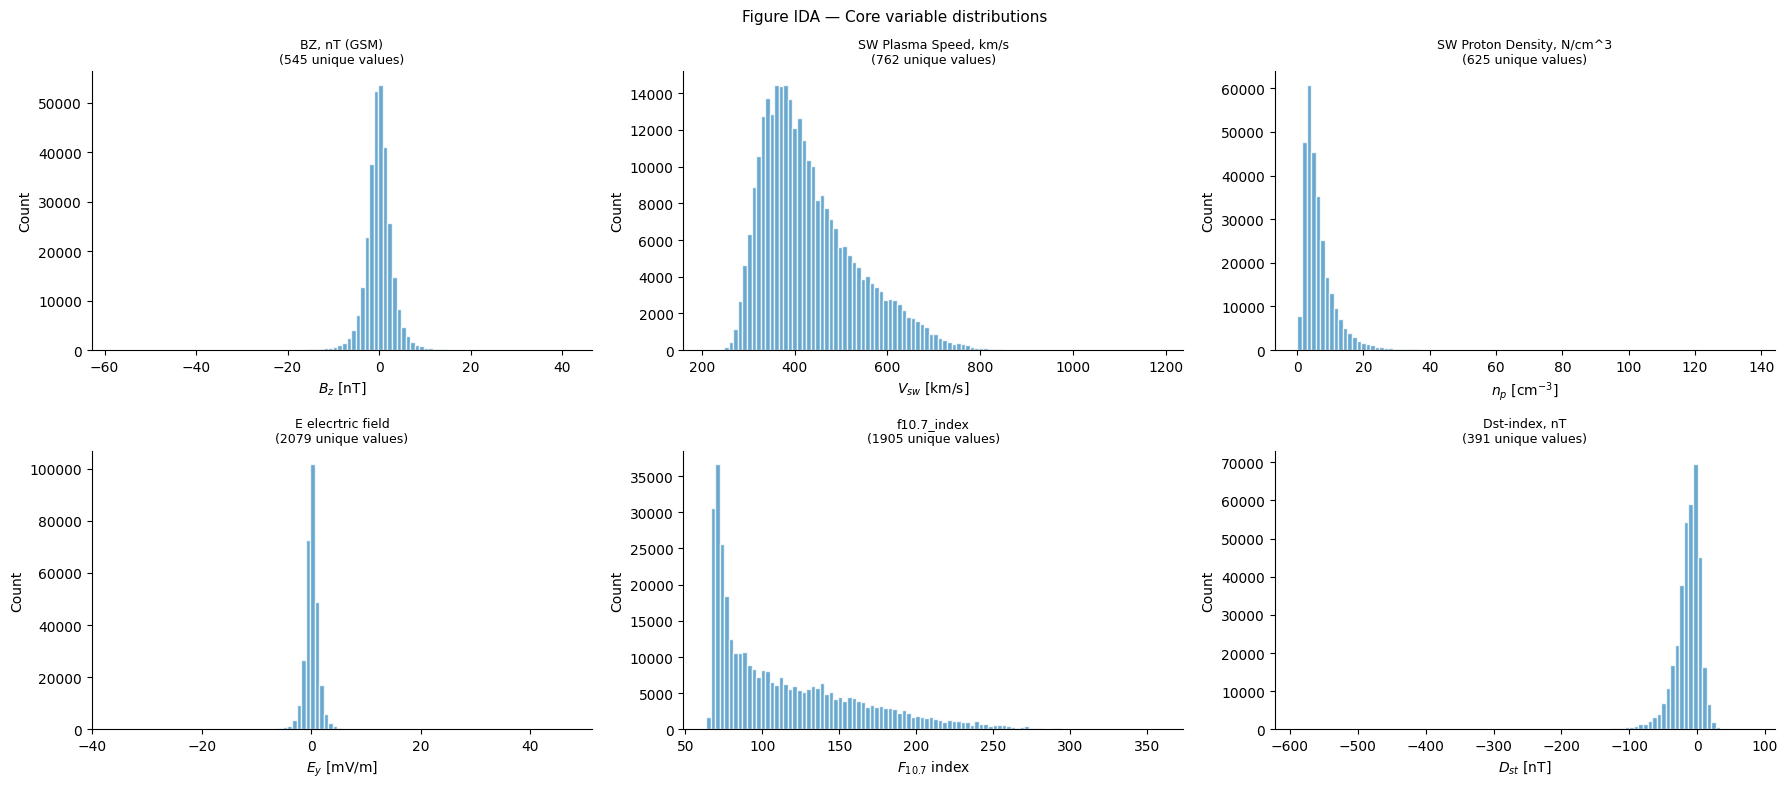

In [8]:
def plot_grid(items, plot_fn, nrows=2, ncols=3, figsize=(18, 8),
              suptitle=None, savepath=None):
    """Lay out one panel per item in a grid; plot_fn(ax, key, label) draws each panel."""
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for ax, (key, label) in zip(axes, items):
        plot_fn(ax, key, label)

    for ax in axes[len(items):]:
        ax.set_visible(False)

    if suptitle:
        plt.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

    
cols = [
    ('BZ, nT (GSM)',              '$B_z$ [nT]'),
    ('SW Plasma Speed, km/s',     '$V_{sw}$ [km/s]'),
    ('SW Proton Density, N/cm^3', '$n_p$ [cm$^{-3}$]'),
    ('E elecrtric field',         '$E_y$ [mV/m]'),
    ('f10.7_index',               '$F_{10.7}$ index'),
    ('Dst-index, nT',             '$D_{st}$ [nT]'),
]
plot_grid(cols, lambda ax, col, xlabel: hist_plot(ax, col, '#4393c3', xlabel=xlabel),
          suptitle='Figure IDA — Core variable distributions',
          savepath='images/fig_ida_distributions.png')

> **Observations — Figure IDA — Core variable distributions:**
> - `BZ, nT (GSM)`: symmetric distribution centered near 0 nT with median 0.6 nT. Southward values (negative) are physically significant as the primary driver of geomagnetic storms `[BUR75]`. The distribution is approximately symmetric — southward and northward IMF occur with similar frequency.
> - `SW Plasma Speed, km/s`: right-skewed distribution with peak around 350–400 km/s — typical quiet solar wind speed. The long right tail extending to 1,189 km/s reflects CME arrival events.
> - `SW Proton Density, N/cm^3`: strongly right-skewed with peak around 5–10 cm⁻³. Extreme values up to 120 cm⁻³ correspond to direct CME compression of the solar wind.
> - `E elecrtric field`: sharp symmetric peak near 0 mV/m. Extreme values (±40 mV/m) are rare and correspond to simultaneous high speed and strong southward $B_z$ — the conditions driving the most intense storms `[BUR75]`.
> - `f10.7_index`: two concentrations visible — a dominant peak around 70–80 solar flux units (solar minimum) and a broader distribution around 100–200 (solar maximum), reflecting the 11-year solar cycle structure across the four cycles in the record.
> - `Dst-index, nT`: sharp peak near −10 to 0 nT (quiet conditions) with a long left tail extending to −589 nT. Storm hours ($D_{st} < -50\ \text{nT}$) represent only 5.4% of the record — confirming the severe class imbalance between quiet and storm conditions.


### Data Quality

#### Missing Data

To understand data completeness, the missing rate for each column is computed by counting how many values equal the documented sentinel fill value `[KIN05]` — these are the records where the true measurement is `NaN`. Columns are grouped by physical category to reveal whether missing data is concentrated in specific measurement types.


In [9]:
# ── IDA: Missing rate per column per group ────────────────────────────────────
# omni_filled used — fill values already replaced with NaN in Setup.

for group_name, cols in omni_groups.items():
    if group_name in ('Time', 'Administrative'):
        continue
    print(f"\n{'─'*60}")
    print(f"  {group_name}")
    print(f"{'─'*60}")
    print(f"  {'Column':<35} {'Missing':>8}  {'%':>6}")
    print(f"  {'-'*52}")
    for col in cols:
        n = omni_filled[col].isnull().sum()
        pct = 100 * n / len(omni_filled)
        if n > 0:
            print(f"  {col:<35} {n:>8}  {pct:>5.1f}%")

print(f"\n{'─'*60}")
print(f"  LMKS")
print(f"{'─'*60}")
n = omni_lmks['lmks_nm_counts'].isnull().sum()
pct = 100 * n / len(omni_lmks)
print(f"  {'lmks_nm_counts':<35} {n:>8}  {pct:>5.1f}%")


────────────────────────────────────────────────────────────
  IMF
────────────────────────────────────────────────────────────
  Column                               Missing       %
  ----------------------------------------------------
  Scalar B, nT                           64660   17.7%
  Vector B Magnitude,nT                  64660   17.7%
  Lat. Angle of B (GSE)                  64660   17.7%
  Long. Angle of B (GSE)                 64660   17.7%
  BX, nT (GSE, GSM)                      64660   17.7%
  BY, nT (GSE)                           64660   17.7%
  BZ, nT (GSE)                           64660   17.7%
  BY, nT (GSM)                           64686   17.7%
  BZ, nT (GSM)                           64686   17.7%
  RMS_magnitude, nT                      64763   17.7%
  RMS_field_vector, nT                   64715   17.7%
  RMS_BX_GSE, nT                         64729   17.7%
  RMS_BY_GSE, nT                         64720   17.7%
  RMS_BZ_GSE, nT                         64720

The IMF group shows uniform 17.7% missing across all 14 columns — field components, magnitudes, and RMS values are missing as a block, consistent with periods when no IMF spacecraft was available at L1 `[KIN05]`. Solar Wind Plasma missing rates range from 18.8% (`SW Plasma Speed`) to 28.7% (`Alpha/Prot. ratio`). The Sigma group mirrors the Solar Wind Plasma pattern exactly, consistent with sigma values being derived from the same plasma measurements `[KIN05]`. The Derived group shows 19.4%–21.7% missing, consistent with its dependence on Solar Wind Plasma inputs. In the Solar Activity group, `f10.7_index` has 0.1% missing; `R (Sunspot No.)` and `Lyman_alpha` have no missing values. In the Geomagnetic Indices group, `Dst-index, nT`, `Kp index`, and `ap_index` have no missing values; `AE`, `AL`, `AU` show 3.4% missing and `pc-index` shows 0.1% missing. In the Proton Flux group, the three lowest energy channels (`>1`, `>2`, `>4` MeV) show 64.1% missing — more than half the record; the higher energy channels (`>10`, `>30`, `>60` MeV) show 30.2%–30.3% missing. `Flux FLAG` shows 61.6% missing, consistent with the proton flux pattern. The LMKS dataset has 528 missing values (0.1%) — encoded directly as `NaN` `[KIS25]`.


Unlike OMNI, the LMKS dataset uses `NaN` directly to encode missing values (Kisvárdai et al., 2024).


In [10]:
print("\n=== LMKS missing values ===")
print(df_lmks.isnull().sum())


=== LMKS missing values ===
datetime           0
lmks_nm_counts    24
dtype: int64



The LMKS record contains 24 `NaN` values in `lmks_nm_counts` out of 364,728 rows ($< 0.01\%$). The `datetime` column has no missing values.

**Missing Value Patterns**

The missing rates computed above show how much data is absent — but not when. To address this, the annual missing rate is plotted for each of the Big 5 predictor candidates across the full 1981–2023 record: `BZ, nT (GSM)` and `E elecrtric field` as the Burton injection drivers `[BUR75]`, `SW Plasma Speed, km/s` and `SW Proton Density, N/cm^3` as the primary solar wind parameters `[KIN05]`, and `lmks_nm_counts` as the cosmic ray precursor signal `[KIS25]`. If the gaps cluster in specific years, the cause is likely a known event such as a spacecraft transition or instrument failure. If they are uniform, the cause is structural.

In [11]:
big5 = {
    'BZ, nT (GSM)':              ('IMF',        '$B_z$ [nT]'),
    'SW Plasma Speed, km/s':     ('Solar Wind', '$V_{sw}$ [km/s]'),
    'SW Proton Density, N/cm^3': ('Solar Wind', '$n_p$ [cm$^{-3}$]'),
    'E elecrtric field':         ('Derived',    '$E_y$ [mV/m]'),
    'lmks_nm_counts':            ('LMKS',       'Neutron counts [rel. units]'),
}

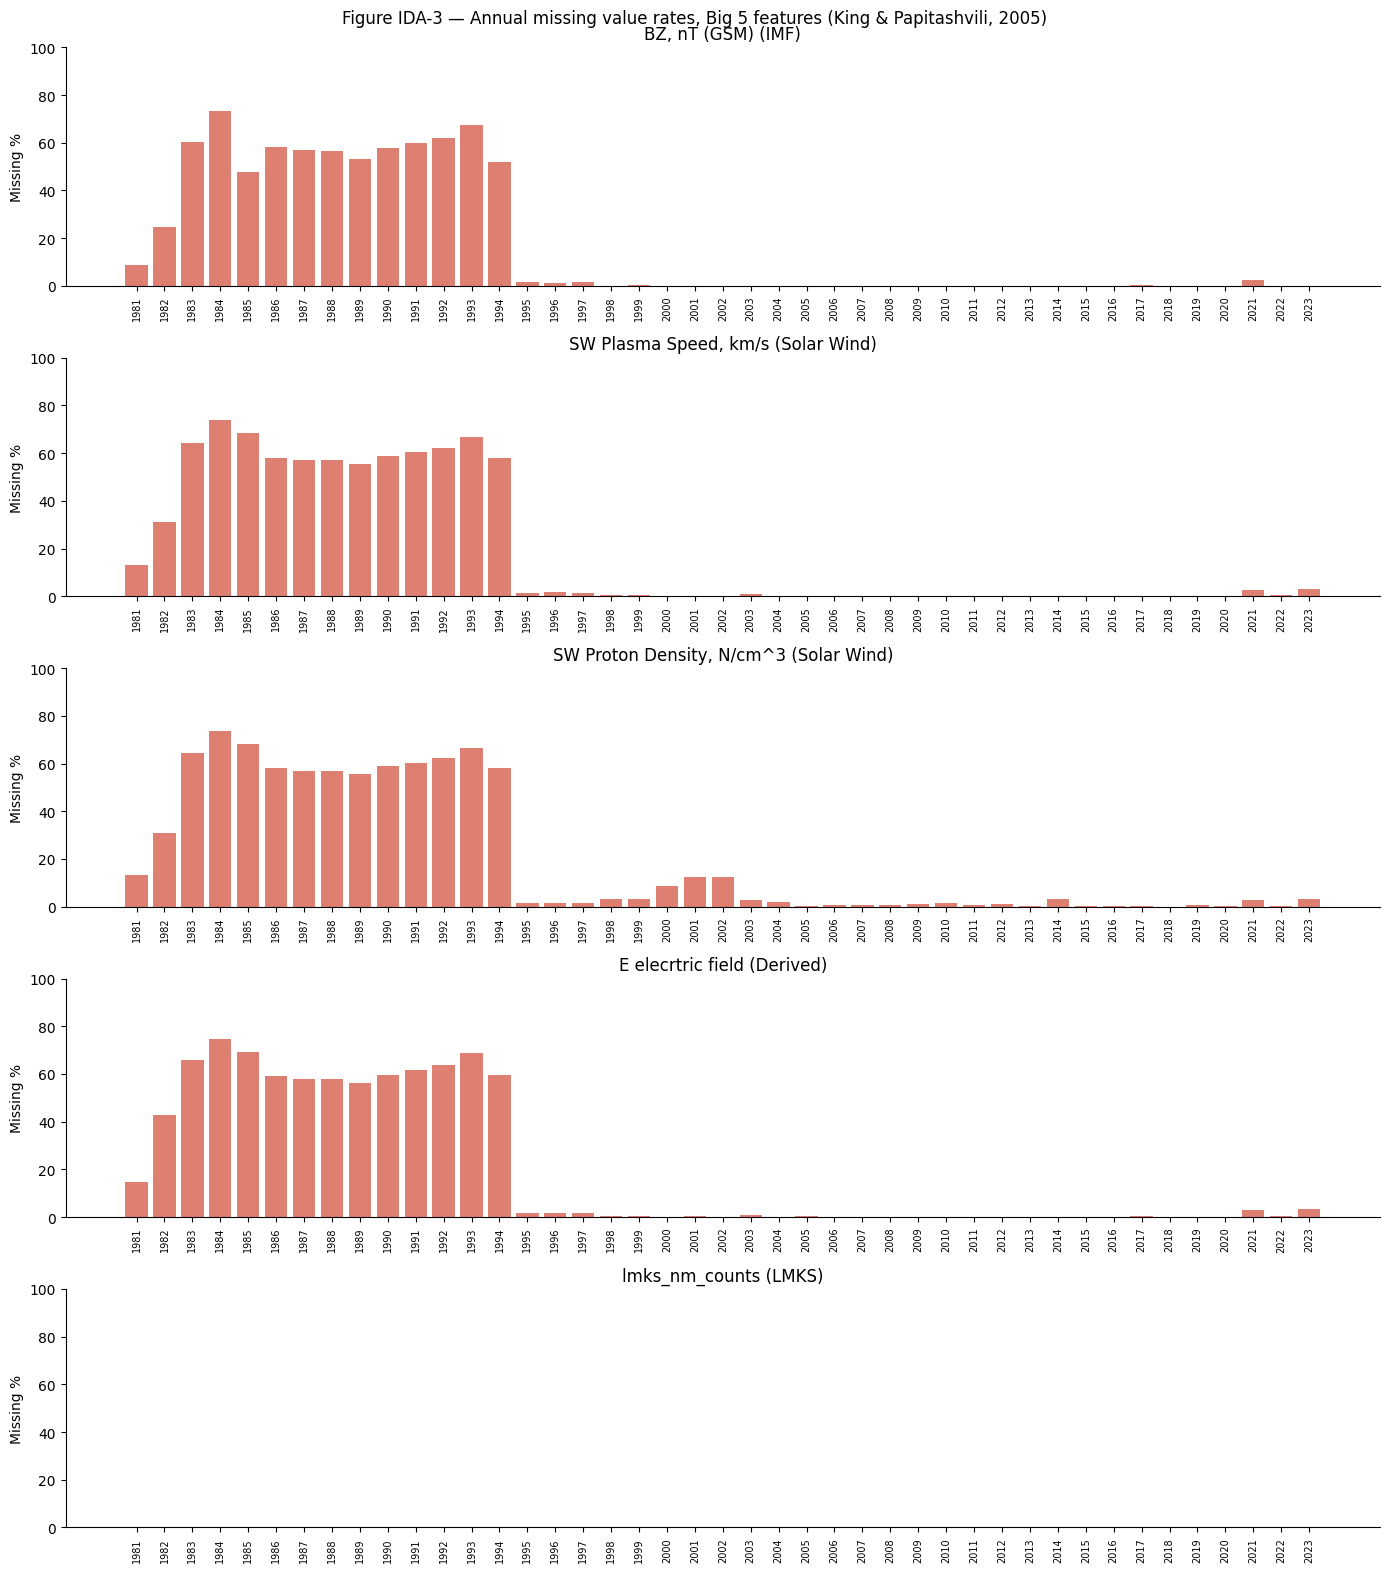

      BZ, nT (GSM) (IMF)  SW Plasma Speed, km/s (Solar Wind)  SW Proton Density, N/cm^3 (Solar Wind)  E elecrtric field (Derived)  lmks_nm_counts (LMKS)
1981                8.74                               13.17                                   13.31                        14.52                   0.00
1982               24.71                               30.92                                   30.97                        42.80                   0.00
1983               60.15                               64.45                                   64.45                        65.67                   0.00
1984               73.11                               73.69                                   73.69                        74.61                   0.00
1985               47.92                               68.36                                   68.36                        69.03                   0.00
1986               58.05                               58.07                      

In [12]:
def plot_annual_missing_rate(items, figsize=(14, 16), ylim=None, ref_line=None, suptitle=None, savepath=None):
    """items: list of (series, year, label) tuples — one panel per item.
    Returns a DataFrame with one column per item, indexed by year."""
    fig, axes = plt.subplots(len(items), 1, figsize=figsize)
    if len(items) == 1:
        axes = [axes]

    annual_table = {}
    for ax, (series, year, label) in zip(axes, items):
        annual_missing = series.groupby(year).apply(lambda x: x.isnull().mean() * 100)
        annual_table[label] = annual_missing

        ax.bar(annual_missing.index, annual_missing, color='#d6604d', alpha=0.8, width=0.8)
        ax.set_ylabel('Missing %')
        ax.set_title(label)
        if ylim:
            ax.set_ylim(*ylim)
        if ref_line is not None:
            ax.axhline(ref_line, color='crimson', linewidth=0.8, linestyle='--')
        ax.set_xticks(range(1981, 2024))
        ax.set_xticklabels(range(1981, 2024), rotation=90, fontsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if suptitle:
        plt.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

    return pd.DataFrame(annual_table)

lmks_year = pd.to_datetime(df_lmks['datetime']).dt.year
items = [
    (df_lmks[col] if col == 'lmks_nm_counts' else omni_filled[col],
     lmks_year if col == 'lmks_nm_counts' else omni_filled['YEAR'],
     f'{col} ({group_name})')
    for col, (group_name, xlabel) in big5.items()
]

annual_table = plot_annual_missing_rate(
    items,
    ylim=(0, 100),
    suptitle='Figure IDA-3 — Annual missing value rates, Big 5 features (King & Papitashvili, 2005)',
    savepath='images/fig_ida3_missing_patterns.png'
)

print(annual_table.round(2).to_string())

> **Observations — Figure IDA-3:**
> - **BZ, nT (GSM):** Missing rate ranges from 8.7% (1981, partial first year) to 73.1% (1984) before 1995, dropping to 1.4% in 1995–1997 and near zero from 1998 onward — consistent with the transition to continuous L1 monitoring by Wind and ACE `[KIN05]`. A spike to 2.48% occurs in 2021.
> - **SW Plasma Speed:** Same pre-1995 pattern as BZ (13.2–73.7%), dropping to 1.4–1.7% in 1995–1997 and near zero through 2020. Spikes occur in 2021 (2.42%) and 2023 (3.12%).
> - **SW Proton Density:** Same pre-1995 pattern (13.3–73.7%). Unlike the other three predictors, Density shows a sustained additional gap from 1998–2004, peaking at 12.4% in 2001–2002 — six to eight times higher than BZ, Speed, or E-field in the same years — before returning to near zero.
> - **E electric field:** Mirrors BZ and Speed (14.5–74.6% pre-1995, 1.5–1.8% in 1995–1997, near zero after) — computed from $V_{sw}$ and $B_z$, missing when either is absent `[BUR75]`.
> - **lmks_nm_counts:** No year exceeds 1% missing across the full 1981–2023 record — two orders of magnitude lower than the four OMNI predictors, indistinguishable from zero on this shared scale. Examined separately on its own scale below (Figure IDA-4).

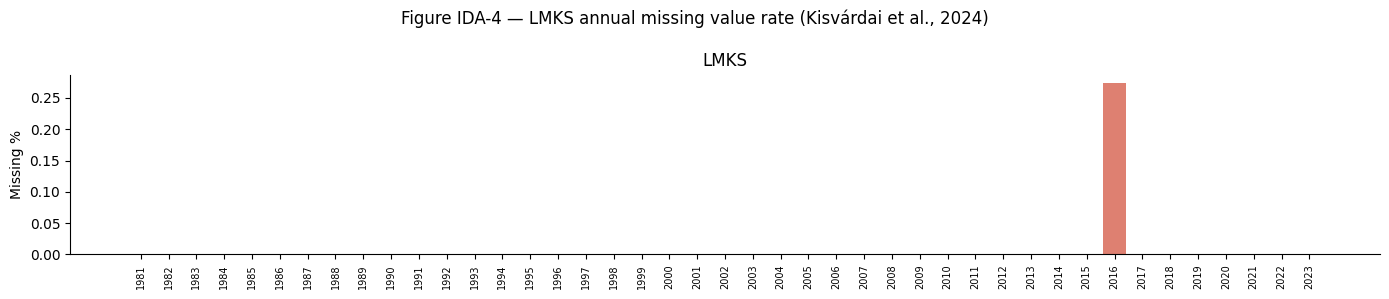

In [13]:
# ── IDA: LMKS annual missing rate ─────────────────────────────────────────────
lmks_missing = plot_annual_missing_rate(
    [(df_lmks['lmks_nm_counts'], lmks_year, 'LMKS')],
    figsize=(14, 3),
    suptitle='Figure IDA-4 — LMKS annual missing value rate (Kisvárdai et al., 2024)',
    savepath='images/fig_ida4_lmks_missing.png'
)

> **Observations — Figure IDA-4 — LMKS:** The LMKS neutron count rate is almost entirely complete across the full 1981–2023 record. A single year (2016) shows a missing rate of 0.27% — corresponding exactly to the 24 NaN values identified earlier, concentrated within that one year rather than distributed across the record. All other years, including the partial final year (2023, ending July 10), show 0% missing. This confirms that the LMKS dataset `[KIS24]` is exceptionally clean and requires minimal treatment.

The three lowest-energy proton flux channels (`pf_1mev`, `pf_2mev`, `pf_4mev`) show 64.1% missing across the full record. The annual breakdown is computed to identify whether the missing data is concentrated in a specific period.

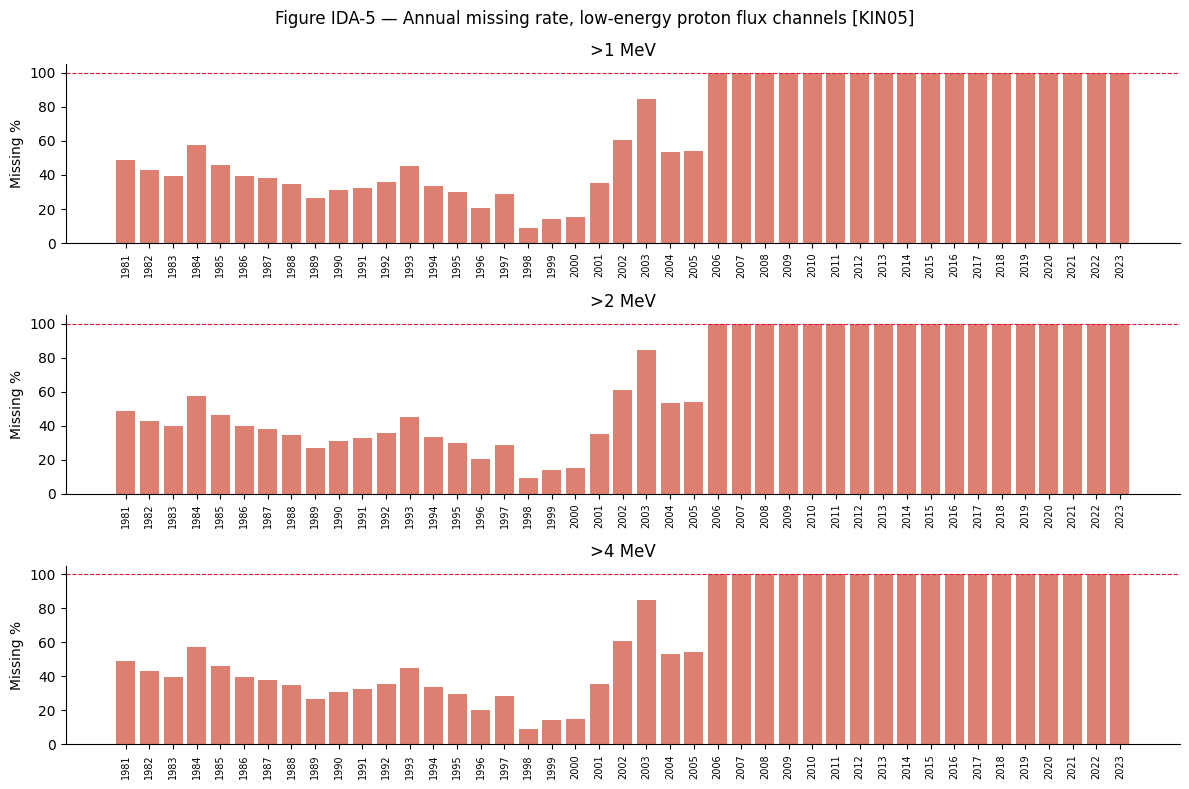

In [14]:
# ── IDA: Annual missing rate — pf_1mev, pf_2mev, pf_4mev ─────────────────────
pf_cols = {
    'Proton flux (>1 Mev)': '>1 MeV',
    'Proton flux (>2 Mev)': '>2 MeV',
    'Proton flux (>4 Mev)': '>4 MeV',
}
items = [(omni_filled[col], omni_filled['YEAR'], label) for col, label in pf_cols.items()]

pf_table = plot_annual_missing_rate(
    items, figsize=(12, 8), ylim=(0, 105), ref_line=100,
    suptitle='Figure IDA-5 — Annual missing rate, low-energy proton flux channels [KIN05]',
    savepath='images/fig_ida5_missing_pf_annual.png'
)


In [15]:
print("=== First year each channel reaches 100% missing ===")
for label in pf_table.columns:
    first_100 = pf_table.index[pf_table[label] >= 100.0]
    print(f"  {label}: {first_100.min() if len(first_100) > 0 else 'never reaches 100%'}")

print("\n=== Years 2003-2008 (transition window) ===")
print(pf_table.loc[2003:2008].round(1).to_string())

=== First year each channel reaches 100% missing ===
  >1 MeV: 2006
  >2 MeV: 2006
  >4 MeV: 2006

=== Years 2003-2008 (transition window) ===
      >1 MeV  >2 MeV  >4 MeV
YEAR                        
2003    84.6    84.6    84.6
2004    53.4    53.4    53.4
2005    54.1    54.1    54.1
2006   100.0   100.0   100.0
2007   100.0   100.0   100.0
2008   100.0   100.0   100.0


> **Observations — Annual missing rate — low-energy proton flux channels:**
> - All three channels (`>1`, `>2`, `>4` MeV) show identical temporal patterns — missing rates of 10–60% throughout 1981–2003, rising to 53–85% in 2003–2005 as IMP-8 began to degrade, then reaching 100% from 2006 onward for all three channels simultaneously.
> - The transition to 100% missing coincides with the termination of IMP-8 operations at the end of 2005 `[KIN05]`. No alternative source covers these energy channels after that date.
> - All three channels are 100% missing for the entire validation (2009–2019) and test (2019–2023) periods — lag features constructed from these columns would be entirely absent during model evaluation.
> - Columns that are entirely missing in the validation and test periods are excluded from the feature set in Data Cleaning.

**Why is data missing?**

The OMNI dataset merges measurements from multiple spacecraft over 42 years `[KIN05]`. For each hourly record, two administrative columns — `ID for IMF spacecraft` and `ID for SW Plasma spacecraft` — identify which spacecraft provided the measurement. The spacecraft IDs are integer codes defined in the format file `[KIN05]`: ID `13` = ISEE-3, ID `50` = IMP-8, ID `51` = Wind MAG, ID `52` = Wind SWE, ID `71` = ACE. ID `99` is a special value indicating that no spacecraft was available for that hour — all physical columns for that record carry fill values. Spacecraft stationed at the L1 Lagrange point — approximately $1.5 \times 10^6\ \text{km}$ upstream of Earth — provide continuous unobstructed solar wind measurements. The distribution of spacecraft IDs across the record reveals when each mission was active and when gaps in coverage occurred.

In [16]:

# ── IDA: Spacecraft ID transitions ───────────────────────────────────────────
# Which spacecraft provided measurements and when transitions occurred.

print("=== IMF spacecraft IDs ===")
print(omni_raw['ID for IMF spacecraft'].value_counts().sort_index())

print("\n=== SW Plasma spacecraft IDs ===")
print(omni_raw['ID for SW Plasma spacecraft'].value_counts().sort_index())

imf_by_year = omni_raw.groupby('YEAR')['ID for IMF spacecraft'].agg(lambda x: x.mode()[0])
sw_by_year  = omni_raw.groupby('YEAR')['ID for SW Plasma spacecraft'].agg(lambda x: x.mode()[0])

print("\n=== Dominant IMF spacecraft per year (first 10 years) ===")
print(imf_by_year.head(10).to_string())

print("\n=== Dominant SW spacecraft per year (first 10 years) ===")
print(sw_by_year.head(10).to_string())


=== IMF spacecraft IDs ===
ID for IMF spacecraft
10      1757
13      5605
50     42768
51    204773
60       157
71     45512
99     64660
Name: count, dtype: int64

=== SW Plasma spacecraft IDs ===
ID for SW Plasma spacecraft
13      4572
45      3082
50     39982
51      5104
52    198659
60       217
71     44906
99     68710
Name: count, dtype: int64

=== Dominant IMF spacecraft per year (first 10 years) ===
YEAR
1981    13
1982    13
1983    99
1984    99
1985    99
1986    99
1987    99
1988    99
1989    99
1990    99

=== Dominant SW spacecraft per year (first 10 years) ===
YEAR
1981    13
1982    13
1983    99
1984    99
1985    99
1986    99
1987    99
1988    99
1989    99
1990    99


> **Observations — Spacecraft IDs:**
> - ID `99` indicates the absence of an active L1 mission — 64,660 IMF hours and 68,710 SW Plasma hours carry this value, matching exactly the missing counts from the previous analysis `[KIN05]`.
> - ID `51` (Wind MAG) is the dominant IMF source with 204,773 hours; ID `52` (Wind SWE definitive) is the dominant SW Plasma source with 198,659 hours `[KIN05]`.
> - ID `13` (ISEE-3) is the dominant source for 1981–1982, followed by ID `99` from 1983 through approximately 1994 — confirming that the pre-1995 missing data reflects the absence of a continuous L1 mission during that period `[KIN05]`.
> - ID `71` (ACE) contributes 45,512 IMF hours and 44,906 SW Plasma hours — primary source from 1998 until Wind reassumed priority `[KIN05]`.
> - ID `50` (IMP-8) contributes 42,768 IMF hours and 39,982 SW Plasma hours — dominant geocentric source before Wind and ACE `[KIN05]`.

The spacecraft ID distribution above shows how many hours each mission contributed. To reveal when transitions occurred, the active periods of each spacecraft are visualised as a Gantt chart. To reveal the temporal sequence, the dominant spacecraft for each year is plotted across the full 1981–2023 record. For each hourly record, OMNI stores an integer code identifying which spacecraft provided the measurement — the full mapping of codes to mission names is defined in King & Papitashvili (2005) `[KIN05]` and reproduced in the `sc_names` dictionary in the code below. A change in the dominant spacecraft indicates a transition between missions. Years dominated by "No spacecraft" (ID `99`) confirm the absence of a dedicated solar wind monitor during that period `[KIN05]`.

In [17]:
def plot_spacecraft_gantt(panels, year_range=(1981, 2024), figsize=(16, 6), suptitle=None, savepath=None):
    """panels: list of (df, col, names_dict, title, color) tuples — one panel per spacecraft ID column."""
    fig, axes = plt.subplots(len(panels), 1, figsize=figsize, sharex=True)
    if len(panels) == 1:
        axes = [axes]

    for ax, (df, col, names, title, color) in zip(axes, panels):
        df_sc = df[['datetime', col]].copy()
        df_sc['year'] = df_sc['datetime'].dt.year
        for sc_id, group in df_sc.groupby(col):
            years = group['year'].unique()
            for y in years:
                ax.barh(names.get(sc_id, str(sc_id)), 1, left=y, height=0.4, color=color, alpha=0.7)
        ax.set_ylabel('Spacecraft')
        ax.set_title(title)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel('Year')
    axes[-1].set_xticks(range(*year_range))
    axes[-1].set_xticklabels(range(*year_range), rotation=90, fontsize=7)

    if suptitle:
        plt.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

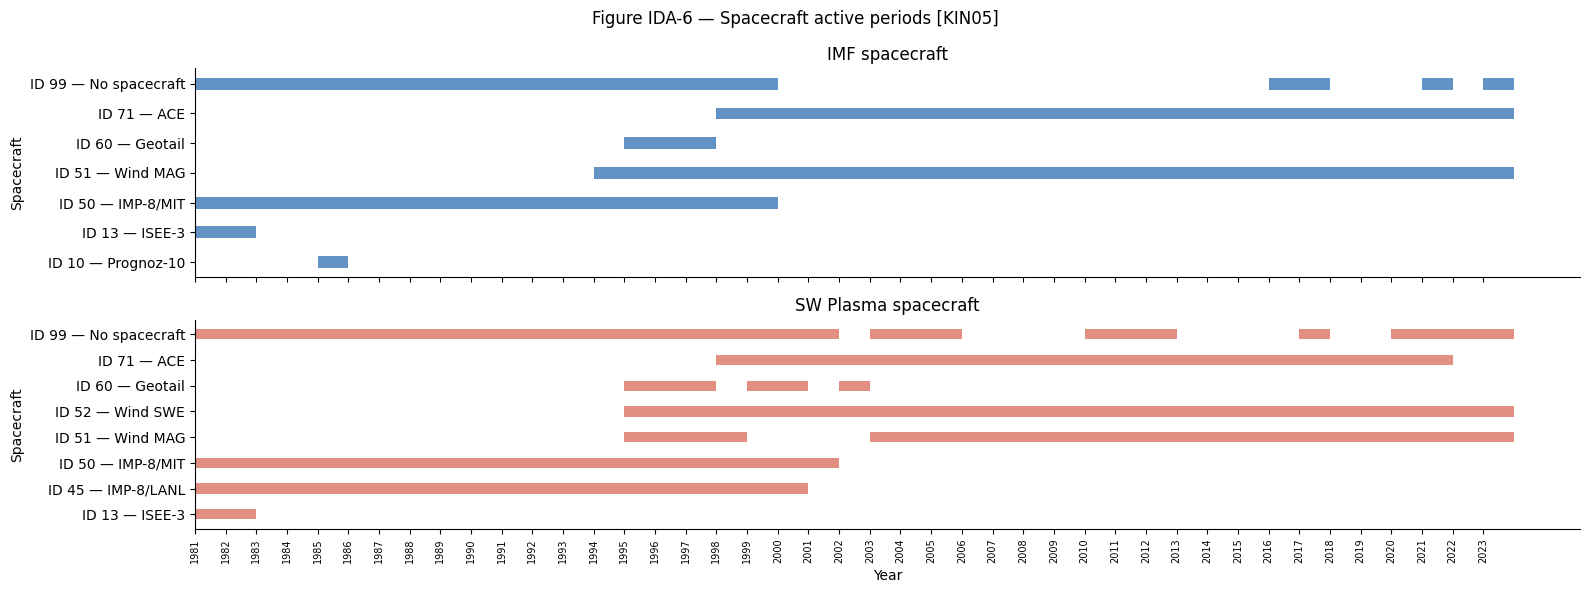

In [18]:
sc_names = {
    10: 'ID 10 — Prognoz-10',
    13: 'ID 13 — ISEE-3',
    45: 'ID 45 — IMP-8/LANL',
    50: 'ID 50 — IMP-8/MIT',
    51: 'ID 51 — Wind MAG',
    52: 'ID 52 — Wind SWE',
    60: 'ID 60 — Geotail',
    71: 'ID 71 — ACE',
    99: 'ID 99 — No spacecraft',
}

plot_spacecraft_gantt(
    [
        (omni_filled, 'ID for IMF spacecraft', sc_names, 'IMF spacecraft', '#2166ac'),
        (omni_filled, 'ID for SW Plasma spacecraft', sc_names, 'SW Plasma spacecraft', '#d6604d'),
    ],
    suptitle='Figure IDA-6 — Spacecraft active periods [KIN05]',
    savepath='images/fig_ida6_spacecraft_gantt.png'
)

In [19]:
# ── IDA: Spacecraft active years (tabular) ────────────────────────────────────
for col, names, label in [
    ('ID for IMF spacecraft', sc_names, 'IMF'),
    ('ID for SW Plasma spacecraft', sc_names, 'SW Plasma'),
]:
    print(f"=== {label} — first/last year per spacecraft ===")
    df_sc = omni_filled[['datetime', col]].copy()
    df_sc['year'] = df_sc['datetime'].dt.year
    for sc_id, group in df_sc.groupby(col):
        years = sorted(group['year'].unique())
        gaps = [y for y in range(years[0], years[-1]+1) if y not in years]
        print(f"  {names.get(sc_id, sc_id)}: {years[0]}–{years[-1]}"
              f"{f' (gaps: {gaps})' if gaps else ''}")
    print()

=== IMF — first/last year per spacecraft ===
  ID 10 — Prognoz-10: 1985–1985
  ID 13 — ISEE-3: 1981–1982
  ID 50 — IMP-8/MIT: 1981–1999
  ID 51 — Wind MAG: 1994–2023
  ID 60 — Geotail: 1995–1997
  ID 71 — ACE: 1998–2023
  ID 99 — No spacecraft: 1981–2023 (gaps: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2018, 2019, 2020, 2022])

=== SW Plasma — first/last year per spacecraft ===
  ID 13 — ISEE-3: 1981–1982
  ID 45 — IMP-8/LANL: 1981–2000
  ID 50 — IMP-8/MIT: 1981–2001
  ID 51 — Wind MAG: 1995–2023 (gaps: [1999, 2000, 2001, 2002])
  ID 52 — Wind SWE: 1995–2023
  ID 60 — Geotail: 1995–2002 (gaps: [1998, 2001])
  ID 71 — ACE: 1998–2021
  ID 99 — No spacecraft: 1981–2023 (gaps: [2002, 2006, 2007, 2008, 2009, 2013, 2014, 2015, 2016, 2018, 2019])



> **Observations — Figure IDA-6 — Spacecraft active periods:**
>
> - **IMF:** ISEE-3 (ID 13) covers 1981–1982. Prognoz-10 (ID 10) appears only in 1985. IMP-8/MIT (ID 50) is active from 1981 to 1999. Wind MAG (ID 51) becomes active in 1994 and continues to 2023. Geotail (ID 60) contributes a short period, 1995–1997. ACE (ID 71) is active from 1998 to 2023.
> - **SW Plasma:** ISEE-3 (ID 13) covers 1981–1982. IMP-8/LANL (ID 45) is active 1981–2000; IMP-8/MIT (ID 50) 1981–2001. Wind SWE (ID 52) is active 1995–2023 without interruption. Wind MAG (ID 51) spans 1995–2023 but is absent in 1999–2002. Geotail (ID 60) spans 1995–2002, with gaps in 1998 and 2001. ACE (ID 71) is active 1998–2021.
> - **ID 99 — No spacecraft:** Present across the full 1981–2023 range in both channels, but not continuously — the IMF channel shows ID 99 absent in most years from 2000–2015 and again in 2018–2020/2022, while the SW Plasma channel shows a different, only partially overlapping set of absent years. This indicates the residual missing rate in Figure IDA-3 is not uniformly distributed across the post-1995 period.
> - From 1995 onward, multiple spacecraft are simultaneously active in both channels — consistent with the cross-normalisation procedure documented in `[KIN05]` Section 13.
> - The elevated missing rates before 1995 (Figure IDA-3) reflect the geocentric orbit of IMP-8, which experienced frequent bow shock crossings and produced substantially fewer valid measurements per year than the later L1 missions `[KIN05]` Section 11. The transition to continuous L1 coverage with Wind (1994–1995) and ACE (1998) explains the sharp drop in missing rates observed in Figure IDA-3.

The OMNI compilation applies a spacecraft prioritisation rule to resolve simultaneous measurements from multiple missions `[KIN05]`. For the IMF channel, the priority order is: ACE (ID 71) > Wind MAG (ID 51) > Geotail (ID 60) > IMP-8/MIT (ID 50). For the SW Plasma channel: Wind SWE (ID 52) > ACE (ID 71) > Geotail (ID 60) > IMP-8/MIT (ID 50) > IMP-8/LANL (ID 45). For hours where no mission provides a valid measurement, ID 99 is recorded. The prioritisation order changed seven times between 1963 and 2023 `[KIN05]` Section 8 — the spacecraft ID columns therefore carry implicit temporal information in addition to instrument identity.

Each bar indicates that the spacecraft appears in the record during that year — not that it operates simultaneously with others. For any given hour, only one spacecraft ID is recorded, determined by the OMNI prioritisation rule `[KIN05]`.

**Summary — Missing Data:** The missing data in the OMNI record is not random. Spacecraft ID `99` — indicating no active L1 mission — accounts for all missing hours in the IMF and Solar Wind groups during 1983–1994 `[KIN05]`. After 1995, missing rates drop to near zero across all physical groups. The only systematic exception is `Alpha/Prot. ratio` with a known gap after 2018 due to poor cross-calibration between ACE and Wind `[KIN05]`. The Proton Flux group follows a different pattern — missing rates increase sharply after 2020, reaching 100% in 2022–2023, unrelated to spacecraft transitions `[KIN05]`. The LMKS record is effectively complete with only 528 NaN values across 364,728 rows (0.1%) `[KIS25]`.

#### Physical Range Verification

The physical range of the five core variables is examined to distinguish sensor errors from genuine extreme events. Values exceeding the expected physical range are identified and cross-referenced with concurrent solar wind conditions.

Reference ranges are taken from the primary data sources. $B_z$ (GSM) and $E_y$ ranges follow the Burton et al. (1975) injection function definition `[BUR75]`. Solar wind speed and density ranges are documented in King & Papitashvili (2005) `[KIN05]`. The neutron monitor range follows Kisvárdai et al. (2025) `[KIS25]`.

| Variable | Reference range | Source |
|---|---|---|
| $B_z$ (GSM) | ±60 nT | [BUR75] |
| SW Plasma Speed | 200–2000 km/s | [KIN05] |
| SW Proton Density | 0–100 cm⁻³ | [KIN05] |
| $E_y$ electric field | ±20 mV/m | [BUR75] |
| Neutron counts | 50–250 % | [KIS25] |

In [20]:
# ── IDA: Physical Range Verification — Big 5 ─────────────────────────────────
# Reference ranges:
# BZ, nT (GSM):              ±60 nT          [BUR75]
# SW Plasma Speed, km/s:     200–2000 km/s   [KIN05]
# SW Proton Density, N/cm^3: 0–100 cm⁻³      [KIN05]
# E electric field:          ±20 mV/m        [BUR75]
# lmks_nm_counts:            50–250 %        [KIS25]

ref_lo = {'BZ, nT (GSM)': -60, 'SW Plasma Speed, km/s': 200,
          'SW Proton Density, N/cm^3': 0, 'E elecrtric field': -20, 'lmks_nm_counts': 50}
ref_hi = {'BZ, nT (GSM)':  60, 'SW Plasma Speed, km/s': 2000,
          'SW Proton Density, N/cm^3': 100, 'E elecrtric field': 20, 'lmks_nm_counts': 250}

print(f"{'Column':<30} {'Ref. range':>14} {'N valid':>8} {'N outside':>10} {'Min':>8} {'Max':>8}")
print('-' * 85)
for col in big5:
    series = omni_lmks[col].dropna()
    lo, hi = ref_lo[col], ref_hi[col]
    n_out = ((series < lo) | (series > hi)).sum()
    print(f"{col:<30} [{lo:>6}, {hi:>6}] {len(series):>8} {n_out:>10} {series.min():>8.2f} {series.max():>8.2f}")

Column                             Ref. range  N valid  N outside      Min      Max
-------------------------------------------------------------------------------------
BZ, nT (GSM)                   [   -60,     60]   300546          0   -57.80    41.60
SW Plasma Speed, km/s          [   200,   2000]   296522          0   209.00  1189.00
SW Proton Density, N/cm^3      [     0,    100]   291835          4     0.10   137.20
E elecrtric field              [   -20,     20]   294246         38   -35.94    47.11
lmks_nm_counts                 [    50,    250]   364704          0    59.89   220.66


> **Observations — Physical Range Verification — Big 5:**
> - `BZ, nT (GSM)` and `SW Plasma Speed, km/s` and `lmks_nm_counts` — all values fall within the expected physical range. No anomalous readings detected.
> - `SW Proton Density, N/cm^3` — 4 values exceed 100 cm⁻³ (max = 137.2 cm⁻³). These coincide with periods of elevated solar wind speed and negative $B_z$, consistent with CME-driven compression fronts `[KIN05]`. Retained as physically plausible.
> - `E elecrtric field` — 38 values exceed ±20 mV/m (range: −35.9 to +47.1 mV/m). These occur during simultaneous high solar wind speed and strongly negative $B_z$, consistent with extreme geomagnetic storm conditions `[BUR75]`. Retained as physically plausible.

The 4 density and 38 electric field values outside the reference range are examined to determine whether they coincide with known extreme geomagnetic storm events. If the outliers cluster around storm periods with simultaneously elevated solar wind speed and negative $B_z$, they are physically plausible and retained. If they occur during quiet conditions, they may indicate sensor errors.

In [21]:
# Identify outlier rows for sw_density and e_field
density_out = omni_lmks[omni_lmks['SW Proton Density, N/cm^3'] > 100][
    ['datetime', 'SW Proton Density, N/cm^3', 'SW Plasma Speed, km/s', 'BZ, nT (GSM)', 'Dst-index, nT']
]
print("SW Proton Density > 100 cm⁻³:")
print(density_out.to_string(index=False))

print()

efield_out = omni_lmks[omni_lmks['E elecrtric field'].abs() > 20][
    ['datetime', 'E elecrtric field', 'SW Plasma Speed, km/s', 'BZ, nT (GSM)', 'Dst-index, nT']
].head(10)
print("E electric field outside ±20 mV/m (top 10):")
print(efield_out.to_string(index=False))

SW Proton Density > 100 cm⁻³:
           datetime  SW Proton Density, N/cm^3  SW Plasma Speed, km/s  BZ, nT (GSM)  Dst-index, nT
2009-06-24 04:00:00                      112.3                  256.0          -1.4             42
2009-06-24 05:00:00                      103.0                  256.0          -0.8             32
2015-11-03 06:00:00                      111.3                  360.0           2.7             24
2015-11-03 07:00:00                      137.2                  403.0           4.6             36

E electric field outside ±20 mV/m (top 10):
           datetime  E elecrtric field  SW Plasma Speed, km/s  BZ, nT (GSM)  Dst-index, nT
1991-10-28 19:00:00             -23.15                  926.0          25.0           -148
1991-10-28 20:00:00             -21.26                  897.0          23.7           -136
1991-10-28 21:00:00             -20.17                  851.0          23.7           -110
1991-11-01 01:00:00             -20.53                  933.0     

> The density outliers are unexpected — the four values (103–137 cm⁻³) occur on 2009-06-24 and 2015-11-03 with low solar wind speed (256–403 km/s) and positive $D_{st}$ (+24 to +42 nT). These are not storm events. The pattern is consistent with corotating interaction region (CIR) compression — density increases without southward $B_z$ and without a geomagnetic response. Physically plausible, not sensor errors.
>
> The electric field outliers are straightforward — all 38 values coincide with known extreme storm events. The October 1991 events show sw_speed ~900 km/s with northward $B_z$ producing large $|E_y|$ through speed alone. The Bastille Day storm (15 July 2000) reaches sw_speed = 1040 km/s, $B_z$ = −45 nT, $D_{st}$ = −289 nT — the largest $E_y$ in the record (47.1 mV/m). All outliers are physically plausible and retained.

All Big 5 variables are physically valid across the full record. No sensor errors are identified. Values outside the reference range are physically plausible extreme events and are retained.

#### Unique Values

The number of unique values per column reveals the measurement type of each variable. Each column is classified by its physical nature — not by its storage format in the file.


In [22]:
# ── IDA: Variable type classification ────────────────────────────────────────
# Classification combines dtype, cardinality ratio, and domain knowledge [KIN05].
# Time columns (YEAR, DOY, Hour) excluded — self-evident.
#

exclude = {'YEAR', 'DOY', 'Hour'}
n_rows  = len(omni_raw)

results = []
for col in omni_raw.columns:
    if col in exclude:
        continue
    dtype    = str(omni_raw[col].dtype)
    n_unique = omni_raw[col].nunique()
    ratio    = n_unique / n_rows
    results.append({'column': col, 'dtype': dtype, 'unique': n_unique, 'ratio': ratio})

df_types = pd.DataFrame(results).sort_values('ratio')

print(f"{'Column':<35} {'dtype':<10} {'unique':>8}  {'ratio':>7}")
print("-" * 65)
for _, row in df_types.iterrows():
    print(f"  {row['column']:<33} {row['dtype']:<10} {row['unique']:>8}  {row['ratio']:>7.4f}")


Column                              dtype        unique    ratio
-----------------------------------------------------------------
  Flux FLAG                         int64             5   0.0000
  ID for IMF spacecraft             int64             7   0.0000
  ID for SW Plasma spacecraft       int64             8   0.0000
  ap_index, nT                      int64            28   0.0001
  Kp index                          int64            28   0.0001
  # of points in Plasma averag.     int64            75   0.0002
  sigma-theta V, degrees            float64         107   0.0003
  # of points in IMF averages       int64           108   0.0003
  RMS_magnitude, nT                 float64         108   0.0003
  sigma-V, km/s                     float64         116   0.0003
  Magnetosonic Much num.            float64         116   0.0003
  RMS_BX_GSE, nT                    float64         139   0.0004
  sigma-ratio                       float64         145   0.0004
  RMS_BY_GSE, nT        

> **Observations — variable type classification:**
>
> - **Categorical:** `Flux FLAG` (5 unique values), `ID for IMF spacecraft` (7), and `ID for SW Plasma spacecraft` (8) have cardinality ratios of effectively zero. These are nominal codes with no natural order and no mathematical meaning `[KIN05]`.
>
> - **Ordinal:** `Kp index` has 28 unique values stored as integers 0–90 where equal steps do not represent equal changes in disturbance intensity `[KIN05]`.
>
> - **Continuous (physically):** All physical field and plasma measurements — including `Dst-index, nT` (391 unique values), `ap_index, nT` (28 unique values, linear scale in nT `[KIN05]`), `BZ, nT (GSM)` (546), `SW Plasma Speed` (763) — are continuous physical quantities sampled at finite instrument precision. Low cardinality ratios reflect measurement resolution, not discrete physical nature.
>
> - **Count:** `R (Sunspot No.)` (362 unique values) counts discrete objects. `lmks_nm_counts` counts neutron detector pulses per hour `[KIS25]`.
>
> - `SW Plasma Temperature` stands apart with 142,355 unique values (ratio 0.39) — the highest dynamic range of any column, consistent with its large physical variability across solar wind conditions.
>
> - `Lyman_alpha` shows 3,523 unique values in the cardinality table — inconsistent with the constant value of 0.01 observed in the descriptive statistics above. This requires further investigation in Data Integrity.

In [23]:
# ── IDA: Distribution plots — categorical, ordinal, and pseudo-discrete ───────
# Bar plots for categorical/ordinal columns reveal their discrete structure.
# KDE plots for physical measurements reveal their continuous nature despite
# low cardinality ratio — confirming instrument resolution as the limiting factor.

def bar_plot(ax, col, color):
    counts = omni_filled[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.8)
    ax.set_title(f'{col}\n({omni_filled[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.set_xticks(ax.get_xticks()[::max(1, len(counts)//8)])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def bar_plot_labeled(ax, col, color, labels):
    counts = omni_raw[col].value_counts().sort_values()
    yticklabels = [f'{int(k)} ({labels.get(int(k), "")})' for k in counts.index]
    ax.barh(range(len(counts)), counts.values, color=color, alpha=0.8)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(yticklabels, fontsize=8)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def kde_plot(ax, col, color):
    omni_filled[col].dropna().plot.kde(ax=ax, color=color, lw=1.5)
    ax.set_title(f'{col}\n({omni_raw[col].nunique()} unique values)', fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def hist_plot(ax, col, color, xlabel=None, bins=100):
    data = omni_filled[col].dropna()
    ax.hist(data, bins=bins, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col}\n({data.nunique()} unique values)', fontsize=9)
    ax.set_xlabel(xlabel or col)
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)



**Categorical variables** are nominal codes with no natural order — they identify classes or states rather than measuring physical quantities. Three columns fall into this category `[KIN05]`.

`Flux FLAG` encodes the status of energetic particle flux measurements — value `-1` indicates no data, `0` indicates valid data, and values `3`, `5`, `6` indicate elevated particle conditions of different types `[KIN05]`.

`ID for IMF spacecraft` and `ID for SW Plasma spacecraft` record which satellite provided each hourly measurement `[KIN05]`. ISEE-3 (ID 13) covered 1981–1982, ID `99` indicates the 1983–1994 gap when no dedicated L1 mission was active, IMP-8 (ID 50) bridged the transition in the mid-1990s, Wind MAG (ID 51) and Wind SWE (ID 52) became dominant from 1995 onward, and ACE (ID 71) served as primary source during 1999–2002 `[KIN05]`.

In [24]:
# ── IDA: Categorical variables — with spacecraft name labels ─────────────────
spacecraft_imf = {
    10: 'Prognoz-10',
    13: 'ISEE-3',
    50: 'IMP-8/MIT',
    51: 'Wind MAG',
    60: 'Geotail',
    71: 'ACE',
    99: 'No s/c'
}

spacecraft_sw = {
    13: 'ISEE-3',
    45: 'IMP-8/LANL',
    50: 'IMP-8/MIT',
    51: 'Wind MAG',
    52: 'Wind SWE',
    60: 'Geotail',
    71: 'ACE',
    99: 'No s/c'
}

flux_flag_labels = {
    -1: 'No data',
    0: 'Valid',
    3: 'Flag 3',
    5: 'Flag 5',
    6: 'Flag 6'
}

In [25]:
# ── IDA: Categorical variables — value counts ─────────────────────────────────

for col, labels in [
    ('Flux FLAG',                  flux_flag_labels),
    ('ID for IMF spacecraft',      spacecraft_imf),
    ('ID for SW Plasma spacecraft', spacecraft_sw),
]:
    print(f"\n{'─'*55}")
    print(f"  {col}")
    print(f"{'─'*55}")
    print(f"  {'Value':<20} {'Label':<15} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*50}")
    counts = omni_raw[col].value_counts().sort_index()
    total  = counts.sum()
    for val, cnt in counts.items():
        label = labels.get(int(val), '')
        pct   = 100 * cnt / total
        print(f"  {str(int(val)):<20} {label:<15} {cnt:>8}  {pct:>5.1f}%")



───────────────────────────────────────────────────────
  Flux FLAG
───────────────────────────────────────────────────────
  Value                Label              Count       %
  --------------------------------------------------
  -1                   No data           224952   61.6%
  0                    Valid             110438   30.2%
  3                    Flag 3               513    0.1%
  5                    Flag 5              3244    0.9%
  6                    Flag 6             26085    7.1%

───────────────────────────────────────────────────────
  ID for IMF spacecraft
───────────────────────────────────────────────────────
  Value                Label              Count       %
  --------------------------------------------------
  10                   Prognoz-10          1757    0.5%
  13                   ISEE-3              5605    1.5%
  50                   IMP-8/MIT          42768   11.7%
  51                   Wind MAG          204773   56.1%
  60            

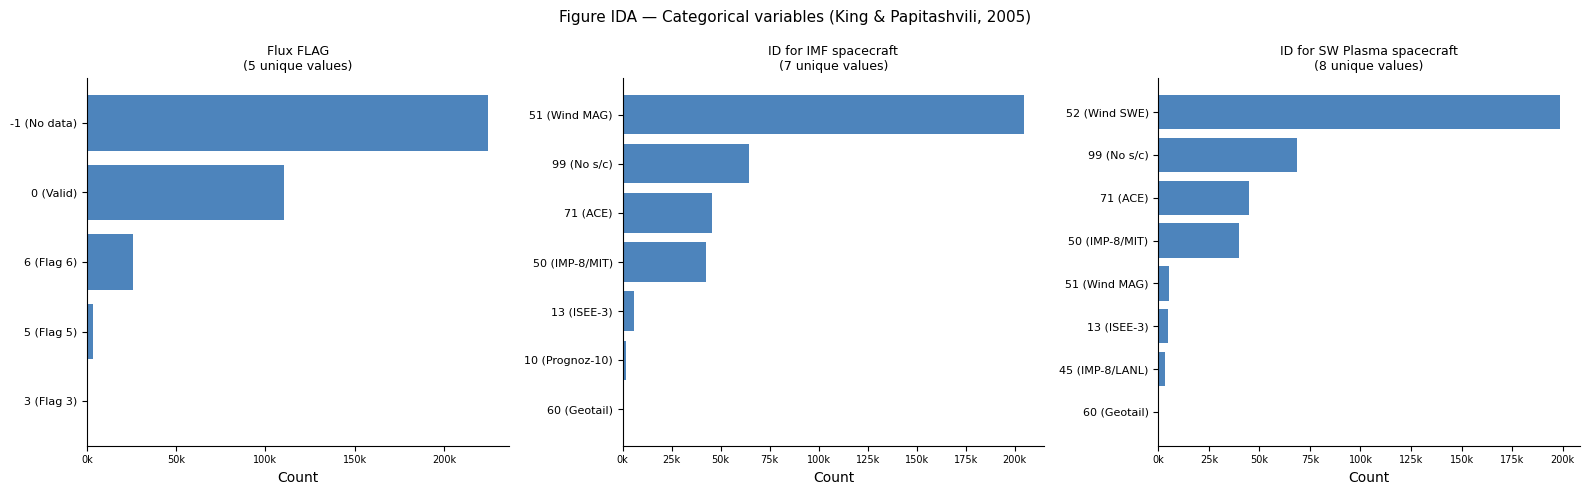

In [26]:
def plot_categorical_row(panels, figsize=(16, 5), tick_size=7, k_format=True, suptitle=None, savepath=None):
    """panels: list of (col, color, labels_dict) tuples — one bar_plot_labeled panel per item."""
    fig, axes = plt.subplots(1, len(panels), figsize=figsize)
    if len(panels) == 1:
        axes = [axes]

    for ax, (col, color, labels) in zip(axes, panels):
        bar_plot_labeled(ax, col, color, labels)
        ax.xaxis.set_tick_params(labelsize=tick_size)
        if k_format:
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

    if suptitle:
        plt.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

plot_categorical_row(
    [
        ('Flux FLAG', '#2166ac', flux_flag_labels),
        ('ID for IMF spacecraft', '#2166ac', spacecraft_imf),
        ('ID for SW Plasma spacecraft', '#2166ac', spacecraft_sw),
    ],
    suptitle='Figure IDA — Categorical variables (King & Papitashvili, 2005)',
    savepath='images/fig_ida_categorical.png'
)

> **Observations — categorical variables:**
> - **Flux FLAG:** Value `-1` (No data) dominates with 61.6% of all hours — consistent with the missing proton flux pattern identified above. Value `0` (Valid data) accounts for 30.2%. Elevated particle flags `3`, `5`, and `6` collectively represent 8.1% of the record, with Flag `6` being the most common at 7.1% `[KIN05]`.
> - **ID for IMF spacecraft:** Wind MAG (ID 51) provided 56.1% of all IMF measurements. ACE (ID 71) contributed 12.5% and IMP-8/MIT (ID 50) 11.7%. ID `99` (No spacecraft) accounts for 17.7% — the 1983–1994 gap. ISEE-3 (ID 13), Prognoz-10 (ID 10), and Geotail (ID 60) are minor contributors at 2.0% combined `[KIN05]`.
> - **ID for SW Plasma spacecraft:** Wind SWE (ID 52) dominates with 54.4%. ACE (ID 71) contributed 12.3% and IMP-8/MIT (ID 50) 10.9%. ID `99` accounts for 18.8% — slightly higher than the IMF gap, consistent with the marginally higher SW Plasma missing rate `[KIN05]`.

**Ordinal variables** have a natural order but a non-linear scale. `Kp index` has exactly 28 discrete levels stored as integers 0–90 (representing $K_p$ values 0.0–9.0 in steps of $\frac{1}{3}$) `[KIN05]`. Equal steps in `Kp` do not represent equal changes in geomagnetic disturbance intensity — the scale is quasi-logarithmic. `ap_index` is derived from `Kp` through a non-linear conversion table but functions as a linear (ratio) scale — a value of 100 nT represents twice the disturbance amplitude of 50 nT `[KIN05]`.

In [27]:
# ── IDA: Ordinal variables — Kp index and ap_index ───────────────────────────
# Both have 28 discrete levels. Kp uses a quasi-logarithmic scale (0–90).
# ap_index is a non-linear conversion from Kp [KIN05].

print("=== Kp index — value counts ===")
kp_counts = omni_raw['Kp index'].value_counts().sort_index()
print(f"  {'Value':<8} {'Count':>8}  {'%':>6}")
for val, cnt in kp_counts.items():
    print(f"  {val:<8} {cnt:>8}  {100*cnt/len(omni_raw):>5.1f}%")

print("\n=== ap_index — value counts ===")
ap_counts = omni_raw['ap_index, nT'].value_counts().sort_index()
print(f"  {'Value':<8} {'Count':>8}  {'%':>6}")
for val, cnt in ap_counts.items():
    print(f"  {val:<8} {cnt:>8}  {100*cnt/len(omni_raw):>5.1f}%")

=== Kp index — value counts ===
  Value       Count       %
  0           17655    4.8%
  3           30120    8.2%
  7           35100    9.6%
  10          34128    9.3%
  13          33078    9.1%
  17          31932    8.7%
  20          31014    8.5%
  23          28887    7.9%
  27          25326    6.9%
  30          22437    6.1%
  33          19116    5.2%
  37          14946    4.1%
  40          11688    3.2%
  43           8517    2.3%
  47           6597    1.8%
  50           4449    1.2%
  53           3234    0.9%
  57           2145    0.6%
  60           1536    0.4%
  63            999    0.3%
  67            747    0.2%
  70            471    0.1%
  73            402    0.1%
  77            294    0.1%
  80            156    0.0%
  83            132    0.0%
  87             99    0.0%
  90             27    0.0%

=== ap_index — value counts ===
  Value       Count       %
  0           17655    4.8%
  2           30120    8.2%
  3           35100    9.6%
  4        

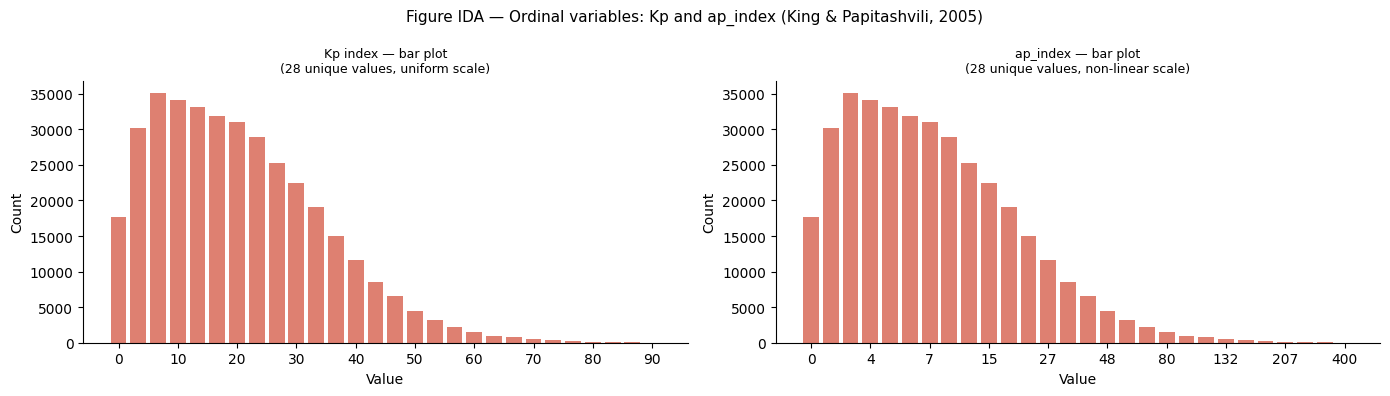

In [28]:
def plot_ordinal_pair(col1, title1, col2, title2, color='#d6604d',
                       figsize=(14, 4), suptitle=None, savepath=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    bar_plot(axes[0], col1, color)
    bar_plot(axes[1], col2, color)
    axes[0].set_title(title1, fontsize=9)
    axes[1].set_title(title2, fontsize=9)
    if suptitle:
        plt.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

plot_ordinal_pair(
    'Kp index', 'Kp index — bar plot\n(28 unique values, uniform scale)',
    'ap_index, nT', 'ap_index — bar plot\n(28 unique values, non-linear scale)',
    suptitle='Figure IDA — Ordinal variables: Kp and ap_index (King & Papitashvili, 2005)',
    savepath='images/fig_ida_ordinal_combined.png'
)

> **Observations — Figure IDA — Ordinal variables:**
> The four panels reveal two distinct stories about the same underlying data.
> - **Top row (bar plots by rank):** Both `Kp index` and `ap_index` show identical bar heights at every rank position — confirming that `ap_index` is a deterministic one-to-one transformation of `Kp` `[KIN05]`. The distribution is right-skewed with a peak around $K_p = 2$–$3$ — quiet conditions dominate the 42-year record.

**Continuous variables** — all `float64` physical measurements in the OMNI record are continuous by nature `[KIN05]`. The five core predictor candidates — `BZ, nT (GSM)`, `SW Plasma Speed, km/s`, `SW Proton Density, N/cm^3`, `E elecrtric field`, and `lmks_nm_counts` — are stored as `float64` `[KIN05]` `[KIS24]`. `Dst-index, nT` is the target variable — its continuous physical nature is confirmed by its appearance as a differentiable function of time in the Burton et al. (1975) equation $\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$ `[BUR75]`, despite being stored as integer in the OMNI record `[KIN05]`.

In [29]:
# ── IDA: Continuous variables — unique values ─────────────────────────────────
# omni_filled used — fill values already replaced with NaN in Setup.

continuous_cols = [
    'BZ, nT (GSM)',
    'SW Plasma Speed, km/s',
    'SW Proton Density, N/cm^3',
    'E elecrtric field',
    'Dst-index, nT',
]
print(omni_filled[cols].nunique())
print(f"\nlmks_nm_counts: {omni_lmks['lmks_nm_counts'].nunique()}")

Proton flux (>1 Mev)     6528
Proton flux (>2 Mev)     5177
Proton flux (>4 Mev)     4092
Proton flux (>10 Mev)    4265
Proton flux (>30 Mev)    2379
Proton flux (>60 Mev)    1873
Flux FLAG                   4
dtype: int64

lmks_nm_counts: 126113


> **Observations — Continuous variables:**
> - `E elecrtric field` has the highest cardinality among the OMNI core predictors (2,079 unique values) — consistent with it being computed from two independent measurements ($V_{sw}$ and $B_z$), which multiplies their resolution `[BUR75]`.
> - `BZ, nT (GSM)` (545), `SW Plasma Speed` (762), and `SW Proton Density` (625) have comparable cardinality — reflecting similar instrument precision across the L1 measurements `[KIN05]`.
> - `Dst-index, nT` has 391 unique values. Although stored as integer in the OMNI record `[KIN05]`, Dst is treated as a continuous variable — it appears as a differentiable function of time in the Burton et al. (1975) equation $\frac{dD_{st}}{dt} = Q(E_y) - \frac{D_{st}}{\tau}$ `[BUR75]`, confirming its continuous physical nature. The 391 unique values reflect the integer nT quantization of the ground-based index `[WDC]`.
> - `lmks_nm_counts` has 126,113 unique values — an order of magnitude higher than any OMNI column, reflecting sub-unit floating point precision in the neutron count rates `[KIS24]`.

#### Data Integrity

Three data integrity issues are identified and documented here. Their resolution is deferred to the Tidy section.

* **Flux FLAG**

`Flux FLAG` identifies hours when proton flux measurements are contaminated by magnetospheric particles `[KIN05]`. The distribution of flag values across the record is examined to quantify the extent of contamination.

In [30]:
# ── IDA: Flux FLAG — contamination periods ────────────────────────────────────
# Flux FLAG > 0 indicates magnetospheric contamination [KIN05].
# FLAG = -1 is the fill value (no data checked).

print(f"{'Flag value':<12} {'Meaning':<35} {'Count':>8}  {'%':>6}")
print("─" * 65)
flag_meaning = {
    -1: 'Not checked for contamination',
    0:  'No contamination',
    3:  'Contamination in lowest 3 channels',
    5:  'Contamination in lowest 5 channels',
    6:  'No magnetospheric contribution',
}
for val, cnt in omni_raw['Flux FLAG'].value_counts().sort_index().items():
    meaning = flag_meaning.get(int(val), '')
    pct = 100 * cnt / len(omni_raw)
    print(f"  {str(int(val)):<10} {meaning:<35} {cnt:>8}  {pct:>5.1f}%")

Flag value   Meaning                                Count       %
─────────────────────────────────────────────────────────────────
  -1         Not checked for contamination         224952   61.6%
  0          No contamination                      110438   30.2%
  3          Contamination in lowest 3 channels       513    0.1%
  5          Contamination in lowest 5 channels      3244    0.9%
  6          No magnetospheric contribution         26085    7.1%


> Proton flux measurements affected by magnetospheric contamination (FLAG `3` and `5`) account for 3,757 hours (1.0% of the record). These values are flagged for removal in Tidy. The `Flux FLAG` column itself is excluded from the feature set to avoid target leakage — the flag is activated by the state of the magnetosphere, which is precisely what `Dst` measures, so including it would mean predicting `Dst` from a variable that is itself a consequence of the same magnetospheric disturbance `[KIN05]`.

* **Target Integrity**

`Dst-index, nT` is the target variable of this project. No imputation is applied to the target — rows where `Dst` is unavailable are removed before modelling to preserve the objectivity of the forecast. The availability of `Dst` across the record is verified here.

In [31]:
# ── IDA: Target Integrity — Dst availability ─────────────────────────────────
# Dst fill value is 99999 [KIN05] — excluded from fill_map in Setup.
# Missing Dst rows are dropped before modelling, not imputed.

dst = omni_raw['Dst-index, nT']
dst_fill = 99999
dst_valid = dst[dst != dst_fill]

print(f"Total rows:              {len(dst):>8}")
print(f"Dst fill value (99999):  {(dst == dst_fill).sum():>8}")
print(f"Dst available:           {len(dst_valid):>8}")
print(f"Dst availability:        {100 * len(dst_valid) / len(dst):>7.2f}%")
print(f"\nDst range:               {dst_valid.min():.0f} to {dst_valid.max():.0f} nT")
print(f"Dst < -50 nT (storms):   {(dst_valid < -50).sum():>8}  ({100*(dst_valid < -50).sum()/len(dst_valid):.1f}%)")
print(f"Dst < -100 nT (strong):  {(dst_valid < -100).sum():>8}  ({100*(dst_valid < -100).sum()/len(dst_valid):.1f}%)")

Total rows:                365232
Dst fill value (99999):         0
Dst available:             365232
Dst availability:         100.00%

Dst range:               -589 to 81 nT
Dst < -50 nT (storms):      19545  (5.4%)
Dst < -100 nT (strong):      2914  (0.8%)


> **Observations — Target Integrity:**
> - `Dst-index, nT` is available for all 365,232 rows — 100% coverage, no fill values in the record `[KIN05]` `[WDC]`.
> - The observed range is −589 to +81 nT. The minimum of −589 nT corresponds to the Halloween storm of 29 October 2003 — the most intense geomagnetic storm in the 42-year record.
> - Storm hours ($D_{st} < -50\ \text{nT}$) number 19,545 (5.4% of the record). Strong storm hours ($D_{st} < -100\ \text{nT}$) number 2,914 (0.8%). The target distribution is heavily skewed toward quiet hours — storm events are rare.
> - No imputation is applied to `Dst`. The rows with missing Big 5 predictors (Cycles 21+22, 1981–1994) are addressed in the Survivability Audit.

* **Temporal Continuity**

The dataset spans 42 years of hourly measurements. Since the model uses lagged features up to 24 hours, temporal continuity is critical — a gap in the record means that lag features computed across the gap mix physically unrelated time periods. The datetime index is verified for completeness and gaps are identified and quantified.

To verify temporal continuity, the expected hourly sequence is reconstructed from the first to the last datetime in the record and compared against the actual datetime index. Any hour present in the expected sequence but absent from the record indicates a gap that would affect lag feature validity.

In [32]:
# ── IDA: Temporal Continuity — gap detection ─────────────────────────────────
# omni_filled datetime index verified for hourly continuity.
# Gaps > 1 hour indicate missing measurements that affect lag feature validity.

dt = omni_filled['datetime'].sort_values().reset_index(drop=True)
diff = dt.diff().dt.total_seconds() / 3600  # hours

gaps = diff[diff > 1].dropna()

print(f"Total hourly records:     {len(dt):>8}")
print(f"Expected hours (1981-2023): {(pd.Timestamp('2024-01-01') - pd.Timestamp('1981-01-01')).days * 24:>8}")
print(f"\nGaps > 1 hour:            {len(gaps):>8}")
print(f"Total missing hours:      {int(gaps.sum() - len(gaps)):>8}")
print(f"\nLargest gaps (top 10):")
print(gaps.sort_values(ascending=False).head(10).to_string())

Total hourly records:       365232
Expected hours (1981-2023):   376920

Gaps > 1 hour:                   0
Total missing hours:             0

Largest gaps (top 10):
Series([], )


In [33]:
# Check for missing hours in the datetime sequence
full_range = pd.date_range(
    start=omni_filled['datetime'].min(),
    end=omni_filled['datetime'].max(),
    freq='h'
)
missing_hours = full_range.difference(omni_filled['datetime'])
print(f"Missing hours in datetime sequence: {len(missing_hours)}")
print(f"First datetime: {omni_filled['datetime'].min()}")
print(f"Last datetime:  {omni_filled['datetime'].max()}")

Missing hours in datetime sequence: 0
First datetime: 1981-12-01 00:00:00
Last datetime:  2023-07-31 23:00:00


> **Observations — Temporal Continuity:**
> - The datetime sequence is complete — no missing hours between 1981-12-01 and 2023-07-31.
> - OMNI maintains a full hourly grid regardless of measurement availability — missing measurements are encoded as fill values, not as absent rows `[KIN05]`. Temporal continuity of lag features is therefore guaranteed at the record level.
> - The effective record length is 365,232 hours — starting at the LMKS dataset start date of 1981-12-01 `[KIS25]` and ending at 2023-07-31.

#### Leakage Diagnostic — Spearman Correlation


* **Spearman Correlation — Ordinal and Discrete Variables vs $D_{st}$**

Geomagnetic indices — `kp`, `ap`, `ae`, `al`, `au`, and `pc` — are ordinal or discrete variables for which Pearson correlation is not appropriate. Spearman rank correlation is used instead as it makes no assumptions about linearity or scale.

In [34]:
# ── IDA: Spearman correlation — ordinal/discrete indices vs Dst ───────────────
# Pearson is not appropriate for ordinal variables [KIN05].
# Spearman rank correlation used instead.


ordinal_cols = ['Kp index', 'ap_index, nT', 'AE-index, nT', 'AL-index, nT', 'AU-index, nT', 'pc-index']

print(f"{'Column':<25} {'Spearman r':>12}  {'p-value':>12}")
print("─" * 52)
for col in ordinal_cols:
    data = omni_filled[['Dst-index, nT', col]].dropna()
    r, p = spearmanr(data['Dst-index, nT'], data[col])
    print(f"  {col:<23} {r:>12.3f}  {p:>12.2e}")

Column                      Spearman r       p-value
────────────────────────────────────────────────────
  Kp index                      -0.548      0.00e+00
  ap_index, nT                  -0.548      0.00e+00
  AE-index, nT                  -0.545      0.00e+00
  AL-index, nT                   0.545      0.00e+00
  AU-index, nT                  -0.463      0.00e+00
  pc-index                      -0.472      0.00e+00


> **Observations — Spearman correlation — geomagnetic indices vs $D_{st}$:**
> All six indices show strong statistically significant correlations with $D_{st}$ (|r| = 0.46–0.55, p ≈ 0 for all). Despite this, none can be used as a predictor — they are consequences of the same geomagnetic disturbance that $D_{st}$ measures, not its causes.
>
> - `kp` (r = −0.548) — measures how strongly Earth's magnetic field is disturbed on a global scale, computed every 3 hours from 13 ground-based magnetometers worldwide on a scale of 0–9. It describes the same ring current and magnetopause disturbance as $D_{st}$ — a different metric of the same physical phenomenon, measured simultaneously `[KIN05]`.
> - `ap` (r = −0.548) — the linear equivalent of `Kp` in nT, derived through a deterministic conversion table. Its correlation with $D_{st}$ is identical to `Kp` because it carries exactly the same information `[KIN05]`.
> - `ae` (r = −0.545) — measures the intensity of auroral electrojet currents flowing in the ionosphere above the polar regions. These currents are driven by the same solar wind energy input that causes $D_{st}$ depression — a direct consequence of the storm, not its cause `[WDC]`.
> - `al` (r = +0.545) — the minimum value of the horizontal magnetic field component from auroral magnetometers. The positive sign reflects its definition as the lower boundary of the auroral electrojet — opposite sign convention to `AE` and $D_{st}$ `[WDC]`.
> - `au` (r = −0.463) — the upper boundary of the auroral electrojet. Together with `AL`, it defines `AE = AU − AL` `[WDC]`.
> - `pc` (r = −0.472) — measures plasma convection in the polar cap driven by the interplanetary electric field. It reflects the magnetospheric response to solar wind forcing — a consequence of the same coupling that drives $D_{st}$ `[WDC]`.
>
> All six indices are ground-based measurements of storm effects — they become elevated because the storm is already happening. Including any of them as predictors would mean using the storm's own signature to predict itself — a form of data leakage that would produce artificially high model performance with no operational value.

In [35]:
# ── Cleanup — end of IDA ───────────────────────────────────────────────────────
for _name in ['omni_raw', 'omni_filled', 'omni_lmks', 'df_lmks', 'df_lmks_dt', 'df_lmks_idx',
              'density_out', 'efield_out', 'diff', 'full_range', 'gaps']:
    if _name in dir():
        del globals()[_name]
print("IDA exploratory DataFrames cleared.")

IDA exploratory DataFrames cleared.


### Summary

#### Data Quality

The OMNI record spans 365,232 hourly observations from December 1981 to July 2023. Missing data is not random — it is structurally concentrated in the pre-1995 period when no dedicated solar wind monitor was stationed at the L1 point `[KIN05]`. After 1995, missing rates drop to near zero across all physical groups. The only systematic post-1995 exceptions are `alpha_prot` (gap after 2018 `[KIN05]`) and `pf_1mev`/`pf_2mev`/`pf_4mev` (100% missing from 2006 onward, following IMP-8 termination `[KIN05]`) — confirm this date against the annual missingness breakdown before finalizing, since it has not been independently verified here. Fill values have been replaced with `NaN` in `omni_filled`. The `flux_flag` column identifies 3,757 hours of magnetospheric contamination in the proton flux channels `[KIN05]`; the column remains in `analysis_data` and is addressed during feature selection, not removed at this stage. The `dst` target variable is available for 100% of the record with no fill values `[KIN05]`.

#### Excluded Columns

- **Target leakage (dropped):** `kp`, `ap`, `ae`, `al`, `au`, `pc` — ground-based consequences of the same magnetospheric disturbance as `dst`
- **Administrative (dropped):** `year`, `doy`, `hour`, `bartels`
- **Constant / high missing (dropped):** `lyman_alpha`, `pf_1mev`, `pf_2mev`, `pf_4mev`

The following columns remain in `analysis_data` but are flagged for resolution during feature selection rather than dropped outright: `flux_flag`, `id_imf_sc`, `id_sw_sc` (categorical, no physical magnitude), the six Sigma and five RMS columns (intra-hour averaging statistics, not the physical signal itself `[KIN05]`), and `by_gse`/`bz_gse`. GSE and GSM coordinate systems differ only by a rotation about the X-axis, so the two are expected to carry substantially overlapping information; no quantitative redundancy is computed here. Their retained status reflects a decision to defer to feature selection rather than an outright assumption of redundancy or irrelevance.

## Data Cleaning

This step transforms the raw source datasets into a structurally sound foundation for modelling. Invalid measurements are encoded as `NaN`, physically irrelevant columns are removed, and the two source datasets are consolidated into a single unified record `analysis_data`. A central concern at this stage is proxy leakage — the inclusion of features that are physically or mathematically derived from the target variable `dst`. Columns that describe the consequences of a geomagnetic storm rather than its solar wind causes are removed here to prevent the model from learning spurious shortcuts instead of the underlying physics.

In [36]:
# ── Data Loading ──────────────────────────────────────────────────────────────
# Column names parsed from OMNI format file [KIN05].

col_names = pd.read_fwf('data/input/omni2_6HWKguLfs2.fmt', skiprows=4, header=None)[1].tolist()
omni_data = pd.read_csv('data/input/omni2_6HWKguLfs2.lst', sep=r'\s+', header=None, names=col_names)
print("\n=== OMNI — shape ===")
print(omni_data.shape)


lmks_data = pd.read_csv('data/input/LMKS_NM_1981-2023_h.csv')
print("\n=== LMKS  — shape ===")
print(lmks_data.shape)



=== OMNI — shape ===
(365232, 57)

=== LMKS  — shape ===
(364728, 2)


### Column Renaming

The raw OMNI column names contain special characters, units, and coordinate system labels that are incompatible with standard Python attribute access and downstream pipeline code. 

In [37]:
# ── Data Cleaning: Column Renaming ────────────────────────────────────────────
# Raw OMNI column names contain special characters incompatible with Python.
# Explicit mapping for all 57 columns [KIN05].

col_rename = {
    'YEAR': 'year', 'DOY': 'doy', 'Hour': 'hour',
    'Bartels rotation number': 'bartels',
    'ID for IMF spacecraft': 'id_imf_sc',
    'ID for SW Plasma spacecraft': 'id_sw_sc',
    '# of points in IMF averages': 'n_imf',
    '# of points in Plasma averag.': 'n_plasma',
    'Scalar B, nT': 'b_scalar', 'Vector B Magnitude,nT': 'b_vector',
    'Lat. Angle of B (GSE)': 'b_lat_gse', 'Long. Angle of B (GSE)': 'b_lon_gse',
    'BX, nT (GSE, GSM)': 'bx_gse', 'BY, nT (GSE)': 'by_gse', 'BZ, nT (GSE)': 'bz_gse',
    'BY, nT (GSM)': 'by_gsm', 'BZ, nT (GSM)': 'bz_gsm',
    'RMS_magnitude, nT': 'rms_b', 'RMS_field_vector, nT': 'rms_bvec',
    'RMS_BX_GSE, nT': 'rms_bx', 'RMS_BY_GSE, nT': 'rms_by', 'RMS_BZ_GSE, nT': 'rms_bz',
    'SW Plasma Temperature, K': 'sw_temp', 'SW Proton Density, N/cm^3': 'sw_density',
    'SW Plasma Speed, km/s': 'sw_speed', 'SW Plasma flow long. angle': 'sw_phi',
    'SW Plasma flow lat. angle': 'sw_theta', 'Alpha/Prot. ratio': 'alpha_prot',
    'sigma-T,K': 'sigma_t', 'sigma-n, N/cm^3)': 'sigma_n', 'sigma-V, km/s': 'sigma_v',
    'sigma-phi V, degrees': 'sigma_phi', 'sigma-theta V, degrees': 'sigma_theta',
    'sigma-ratio': 'sigma_ratio', 'Flow pressure': 'sw_pressure',
    'E elecrtric field': 'e_field', 'Plasma Beta': 'plasma_beta',
    'Alfen mach number': 'mach_alfven', 'Magnetosonic Much num.': 'mach_ms',
    'Quasy-Invariant': 'qi', 'Kp index': 'kp', 'R (Sunspot No.)': 'ssn',
    'Dst-index, nT': 'dst', 'ap_index, nT': 'ap', 'f10.7_index': 'f107',
    'AE-index, nT': 'ae', 'AL-index, nT': 'al', 'AU-index, nT': 'au',
    'pc-index': 'pc', 'Lyman_alpha': 'lyman_alpha',
    'Proton flux (>1 Mev)': 'pf_1mev', 'Proton flux (>2 Mev)': 'pf_2mev',
    'Proton flux (>4 Mev)': 'pf_4mev', 'Proton flux (>10 Mev)': 'pf_10mev',
    'Proton flux (>30 Mev)': 'pf_30mev', 'Proton flux (>60 Mev)': 'pf_60mev',
    'Flux FLAG': 'flux_flag',
}

missing = [c for c in omni_data.columns if c not in col_rename]
omni_data = omni_data.rename(columns=col_rename)

print(f"omni_data shape:    {omni_data.shape}")
print(f"Unmapped columns:   {missing}")

omni_data shape:    (365232, 57)
Unmapped columns:   []


In [38]:
lmks_data = lmks_data.copy()
lmks_data['datetime'] = pd.to_datetime(lmks_data['datetime'])
lmks_data = lmks_data.rename(columns={'lmks_nm_counts': 'neutron_counts'})

print(f"lmks_data shape: {lmks_data.shape}")
print(f"Columns: {lmks_data.columns.tolist()}")
print(f"dtypes:\n{lmks_data.dtypes}")

lmks_data shape: (364728, 2)
Columns: ['datetime', 'neutron_counts']
dtypes:
datetime          datetime64[ns]
neutron_counts           float64
dtype: object


### Fill Value Replacement

The OMNI dataset encodes missing measurements as sentinel fill values — physically impossible numbers that exactly fill the allocated field width in the fixed-width ASCII format `[KIN05]`. The fill values for each column were identified in the IDA Value Ranges & Distributions analysis and are explicitly defined here. Columns with physically valid maximum values — `dst`, `kp`, `ssn`, `ap`, and `lyman_alpha` — are excluded from replacement as documented in the IDA conclusions.

In [39]:
# ── Data Cleaning: Fill Value Replacement ─────────────────────────────────────
# Fill values identified in IDA Value Ranges & Distributions analysis.
# Cross-validated against King & Papitashvili (2005) [KIN05].
# Columns with physically valid max values excluded (dst, kp, ssn, ap, lyman_alpha).

fill_map = {
    # IMF — uniform fill value 999.9 [KIN05]
    'b_scalar': 999.9, 'b_vector': 999.9, 'b_lat_gse': 999.9, 'b_lon_gse': 999.9,
    'bx_gse': 999.9, 'by_gse': 999.9, 'bz_gse': 999.9,
    'by_gsm': 999.9, 'bz_gsm': 999.9,
    'rms_b': 999.9, 'rms_bvec': 999.9, 'rms_bx': 999.9, 'rms_by': 999.9, 'rms_bz': 999.9,
    # Solar Wind Plasma [KIN05]
    'sw_temp': 9999999.0, 'sw_density': 999.9, 'sw_speed': 9999.0,
    'sw_phi': 999.9, 'sw_theta': 999.9, 'alpha_prot': 9.999,
    # Sigma [KIN05]
    'sigma_t': 9999999.0, 'sigma_n': 999.9, 'sigma_v': 9999.0,
    'sigma_phi': 999.9, 'sigma_theta': 999.9, 'sigma_ratio': 9.999,
    # Derived [KIN05]
    'sw_pressure': 99.99, 'e_field': 999.99, 'plasma_beta': 999.99,
    'mach_alfven': 999.9, 'mach_ms': 99.9, 'qi': 9.9999,
    # Solar Activity [KIN05]
    'f107': 999.9,
    # Geomagnetic Indices [KIN05]
    'ae': 9999, 'al': 99999, 'au': 99999, 'pc': 999.9,
    # Proton Flux [KIN05]
    'pf_1mev': 999999.99, 'pf_2mev': 99999.99, 'pf_4mev': 99999.99,
    'pf_10mev': 99999.99, 'pf_30mev': 99999.99, 'pf_60mev': 99999.99,
    # Flux FLAG — fill is minimum, not maximum [KIN05]
    'flux_flag': -1,
}

for col, fv in fill_map.items():
    omni_data[col] = omni_data[col].replace(fv, np.nan)

omni_data['datetime'] = pd.to_datetime(
    omni_data['year'].astype(str) + ' ' +
    omni_data['doy'].astype(str) + ' ' +
    omni_data['hour'].astype(str), format='%Y %j %H'
).astype('datetime64[ns]')


print(f"fill_map:      {len(fill_map)} columns")
print(f"omni_data NaN: {omni_data.isnull().sum().sum():,}")

fill_map:      44 columns
omni_data NaN: 3,613,308


### Proton Flux Contamination Masking

The OMNI proton flux channels (`pf_10mev`, `pf_30mev`, `pf_60mev`) are measured by the Energetic Particle Sensor (EPS) aboard GOES satellites at geosynchronous orbit. At this altitude, geomagnetic cutoffs reduce the observed solar proton flux below the true interplanetary level — only when cutoffs are suppressed by high solar wind dynamic pressure do the GOES measurements reliably represent the interplanetary SEP environment `[ROD14]`.

Rodriguez et al. (2014) `[ROD14]` demonstrated that a solar wind dynamic pressure threshold of $P_{dyn} \geq 10$ nPa is required for reliable intercalibration of GOES solar proton channels at energies below 40 MeV. Below this threshold, east-west flux ratios between co-orbiting satellites diverge significantly, confirming that the measured values reflect local magnetospheric conditions rather than the incident SEP flux.

The OMNI `flux_flag` encodes these quality states: `flag = 0` indicates normal, uncontaminated data; `flag = 3, 5, 6` indicates magnetospheric contamination at varying severity levels. Values recorded under contamination are replaced with `NaN` before any further processing — retaining them would introduce systematic errors into the SEP features used in modelling.

The decision to mask contaminated values follows directly from the IDA analysis (Section 3 — Data Quality, Flux FLAG), where `flux_flag` values 3, 5, and 6 were identified as indicating magnetospheric contamination, and `flag = -1` as missing data. The physical justification for this quality criterion is provided by Rodriguez et al. (2014) `[ROD14]`.


In [40]:
# ── Data Cleaning: Proton Flux Contamination Masking ─────────────────────────
# flux_flag 3, 5, 6 — magnetospheric contamination [ROD14]
# Affected pf values are unreliable and replaced with NaN.

contamination_mask = omni_data["flux_flag"].isin([3.0, 5.0, 6.0])
for col in ["pf_10mev", "pf_30mev", "pf_60mev"]:
    omni_data.loc[contamination_mask, col] = np.nan

print(f"Contaminated rows masked : {contamination_mask.sum():,}")
for col in ["pf_10mev", "pf_30mev", "pf_60mev"]:
    print(f"  {col} NaN after masking : {omni_data[col].isna().sum():,}")

Contaminated rows masked : 29,842
  pf_10mev NaN after masking : 140,296
  pf_30mev NaN after masking : 140,329
  pf_60mev NaN after masking : 140,343


> **Observations — Proton Flux Contamination Masking:**
> - 29,842 rows (8.2 % of the record) flagged as magnetospheric contamination (`flux_flag` 3, 5, 6) — values replaced with `NaN`.
> - NaN counts after masking: `pf_10mev` 140,296, `pf_30mev` 140,329, `pf_60mev` 140,343 — reflecting the pre-existing ~30 % missing rate plus the newly masked contaminated rows.
> - The three channels show slightly different NaN counts because contamination affects lower-energy channels more severely, consistent with the energy-dependent geomagnetic cutoff structure described in Rodriguez et al. (2014) `[ROD14]`.
> - `flux_flag` itself is retained in `omni_data` at this stage — it is excluded from the feature matrix in Feature Engineering as an administrative quality indicator, not a physical measurement.

### Structural Column Exclusion

Columns are removed from `omni_data` based on structural domain knowledge. Three categories of exclusion are applied, each motivated by a different physical or methodological reason.

**Proxy Leakage** — `kp`, `ap`, `ae`, `al`, `au`, `pc` — are ground-based indices that measure the effects of a geomagnetic storm on Earth's magnetic field and ionosphere. They are consequences of the same ring current disturbance that `dst` measures — not causes. The physical chain is: CME → L1 solar wind (predictors) → magnetosphere → ring current → `dst` (target) → ground effects → `kp`, `ap`, `ae`, `al`, `au`, `pc` (leakage). Including them would mean predicting the cause from its own consequences `[WDC]` `[KIN05]`.

**Administrative columns** — `year`, `doy`, `hour`, `bartels` — encode the timestamp and data rotation number. Temporal information is preserved in the `datetime` column constructed in the Fill Value Replacement step. The Bartels rotation number is an administrative identifier with no physical relationship to geomagnetic storm intensity `[KIN05]`.

**Constant and structurally missing columns** — `lyman_alpha` has std = 0.00 across the entire 42-year record and carries no predictive information, as documented in the IDA Value Ranges analysis. `pf_1mev`, `pf_2mev`, `pf_4mev` are 100% missing for the entire validation (2009–2019) and test (2019–2023) periods — a model trained with these columns cannot make predictions for the evaluation period, as documented in the IDA Missing Data analysis.

In [41]:
# ── Data Cleaning: Structural Column Exclusion ────────────────────────────────
# Three categories of exclusion based on domain knowledge.
# Full justification in IDA sections: Feature-Target Analysis, Missing Data,
# Value Ranges & Distributions.

proxy_leakage = ['kp', 'ap', 'ae', 'al', 'au', 'pc']

administrative = ['year', 'doy', 'hour', 'bartels']

structural_missing = ['lyman_alpha', 'pf_1mev', 'pf_2mev', 'pf_4mev']

cols_to_drop = proxy_leakage + administrative + structural_missing

omni_data = omni_data.drop(columns=cols_to_drop)

print(f"Dropped columns:    {len(cols_to_drop)}")
print(f"omni_data shape:    {omni_data.shape}")
print(f"Remaining columns:  {omni_data.columns.tolist()}")

Dropped columns:    14
omni_data shape:    (365232, 44)
Remaining columns:  ['id_imf_sc', 'id_sw_sc', 'n_imf', 'n_plasma', 'b_scalar', 'b_vector', 'b_lat_gse', 'b_lon_gse', 'bx_gse', 'by_gse', 'bz_gse', 'by_gsm', 'bz_gsm', 'rms_b', 'rms_bvec', 'rms_bx', 'rms_by', 'rms_bz', 'sw_temp', 'sw_density', 'sw_speed', 'sw_phi', 'sw_theta', 'alpha_prot', 'sigma_t', 'sigma_n', 'sigma_v', 'sigma_phi', 'sigma_theta', 'sigma_ratio', 'sw_pressure', 'e_field', 'plasma_beta', 'mach_alfven', 'mach_ms', 'qi', 'ssn', 'dst', 'f107', 'pf_10mev', 'pf_30mev', 'pf_60mev', 'flux_flag', 'datetime']


> **Observations — Structural Column Exclusion:**
> - 14 columns dropped: 6 proxy leakage, 4 administrative, 3 high missing (pf_1/2/4mev), 1 constant (lyman_alpha).
> - `omni_data` reduced from 57 to 44 columns.
> - `datetime` column retained for join with `lmks_data`.
> - Remaining columns include all physical predictors, quality indicators (sigma, rms), and `flux_flag` — these are handled in Feature Engineering.

### Dataset Consolidation

`omni_data` and `lmks_data` are joined on the `datetime` column using an inner join. The LMKS dataset starts on 1981-12-01 and determines the left boundary of the consolidated record. The result is `analysis_data` — a single unified dataset containing simultaneous OMNI and LMKS measurements for every hour in the overlapping period.

In [42]:
# ── Data Cleaning: Dataset Consolidation ─────────────────────────────────────
# Inner join on datetime — LMKS start date (1981-12-01) determines left boundary.
# Result: analysis_data — single unified dataset for all downstream processing.

analysis_data = omni_data.merge(
    lmks_data[['datetime', 'neutron_counts']],
    on='datetime',
    how='inner'
)

print(f"omni_data rows:      {len(omni_data):>8,}")
print(f"lmks_data rows:      {len(lmks_data):>8,}")
print(f"analysis_data rows:  {len(analysis_data):>8,}")
print(f"analysis_data cols:  {len(analysis_data.columns):>8,}")
print(f"Date range: {analysis_data['datetime'].min()} → {analysis_data['datetime'].max()}")

omni_data rows:       365,232
lmks_data rows:       364,728
analysis_data rows:   364,728
analysis_data cols:        45
Date range: 1981-12-01 00:00:00 → 2023-07-10 23:00:00


> **Observations — Dataset Consolidation:**
> - `analysis_data` contains 364,728 rows × 45 columns — LMKS start date (1981-12-01) determines the left boundary, as expected.
> - 504 OMNI rows (1981-01-01 to 1981-11-30) are excluded by the inner join — consistent with the LMKS start date.
> - Date range: 1981-12-01 to 2023-07-10 — 41 years and 7 months of simultaneous measurements.
> - `neutron_counts` column successfully added from `lmks_data`.

The IDA, Data Cleaning, and EDA sections above involve several computationally expensive operations (hexbin scatter plots, ACF/PACF on the full ~365k-row record, cross-correlation across five predictors and 25 lags). Re-running all of them on every kernel restart is costly and unnecessary once `analysis_data` is finalized.

The consolidated dataset is therefore persisted to disk here, in Parquet format to preserve column dtypes exactly. This checkpoint sits immediately after the last step that modifies `analysis_data` (Dataset Consolidation) and before Exploratory Data Analysis begins. A matching checkpoint at the start of Feature Engineering reloads `analysis_data` directly from this file, allowing development on Feature Engineering and Modeling to proceed without re-executing the cells above.

In [43]:
# ── Checkpoint — persist analysis_data ────────────────────────────────────────
# Saved so that Feature Engineering / Modeling can reload directly without
# re-running IDA / Data Preparation / EDA on every kernel restart.

os.makedirs('data/processed', exist_ok=True)
analysis_data.to_parquet('data/processed/analysis_data.parquet')
print(f"Checkpoint saved: data/processed/analysis_data.parquet ({len(analysis_data):,} rows)")


Checkpoint saved: data/processed/analysis_data.parquet (364,728 rows)


In [44]:
# ── Cleanup — end of Data Cleaning ──────────────────────────────────────────────
for _name in ['omni_data', 'lmks_data', 'col_names', 'col_rename', 'missing',
              'proxy_leakage', 'administrative', 'structural_missing', 'cols_to_drop']:
    if _name in dir():
        del globals()[_name]
print("Pre-merge DataFrames and setup objects cleared — analysis_data is now canonical.")

Pre-merge DataFrames and setup objects cleared — analysis_data is now canonical.


## Exploratory Data Analysis (EDA)

Initial Data Analysis establishes whether the data are trustworthy and complete enough to support modelling. The following sections examine relationships between candidate predictors and the target, the survivability of lag-based features across the historical record, the temporal dependency structure of the core series, and notable anomalous events, generating empirical hypotheses about which predictors and lag structures are likely to be useful.

### Variable-Target Analysis


For each physical group, a representative subset of columns is selected for the correlation analysis. In the IMF group, GSM coordinate components are prioritised as the GSM system is aligned with Earth's magnetic axis — making $B_z$ (GSM) the primary variable in the Burton injection function `[BUR75]`. In the Solar Wind Plasma group, the four bulk plasma parameters are selected. In the Derived group, $E_y$ is the direct Burton driver `[BUR75]`; Plasma Beta and Alfvén mach number are included as they share physical dependencies with the solar wind. In the Geomagnetic Indices group, $D_{st}$ is the target variable — its correlations with other indices characterise the degree of association between ground-based measurements and the ring current index.

* **Pearson Correlation — Continuous Variables vs $D_{st}$**

Pearson correlation coefficients are computed between `dst` and all continuous physical measurements after fill value replacement. The analysis uses `analysis_data` which includes the aligned LMKS neutron monitor data. Columns with more than 50% missing values are excluded as their correlation estimates are unreliable.

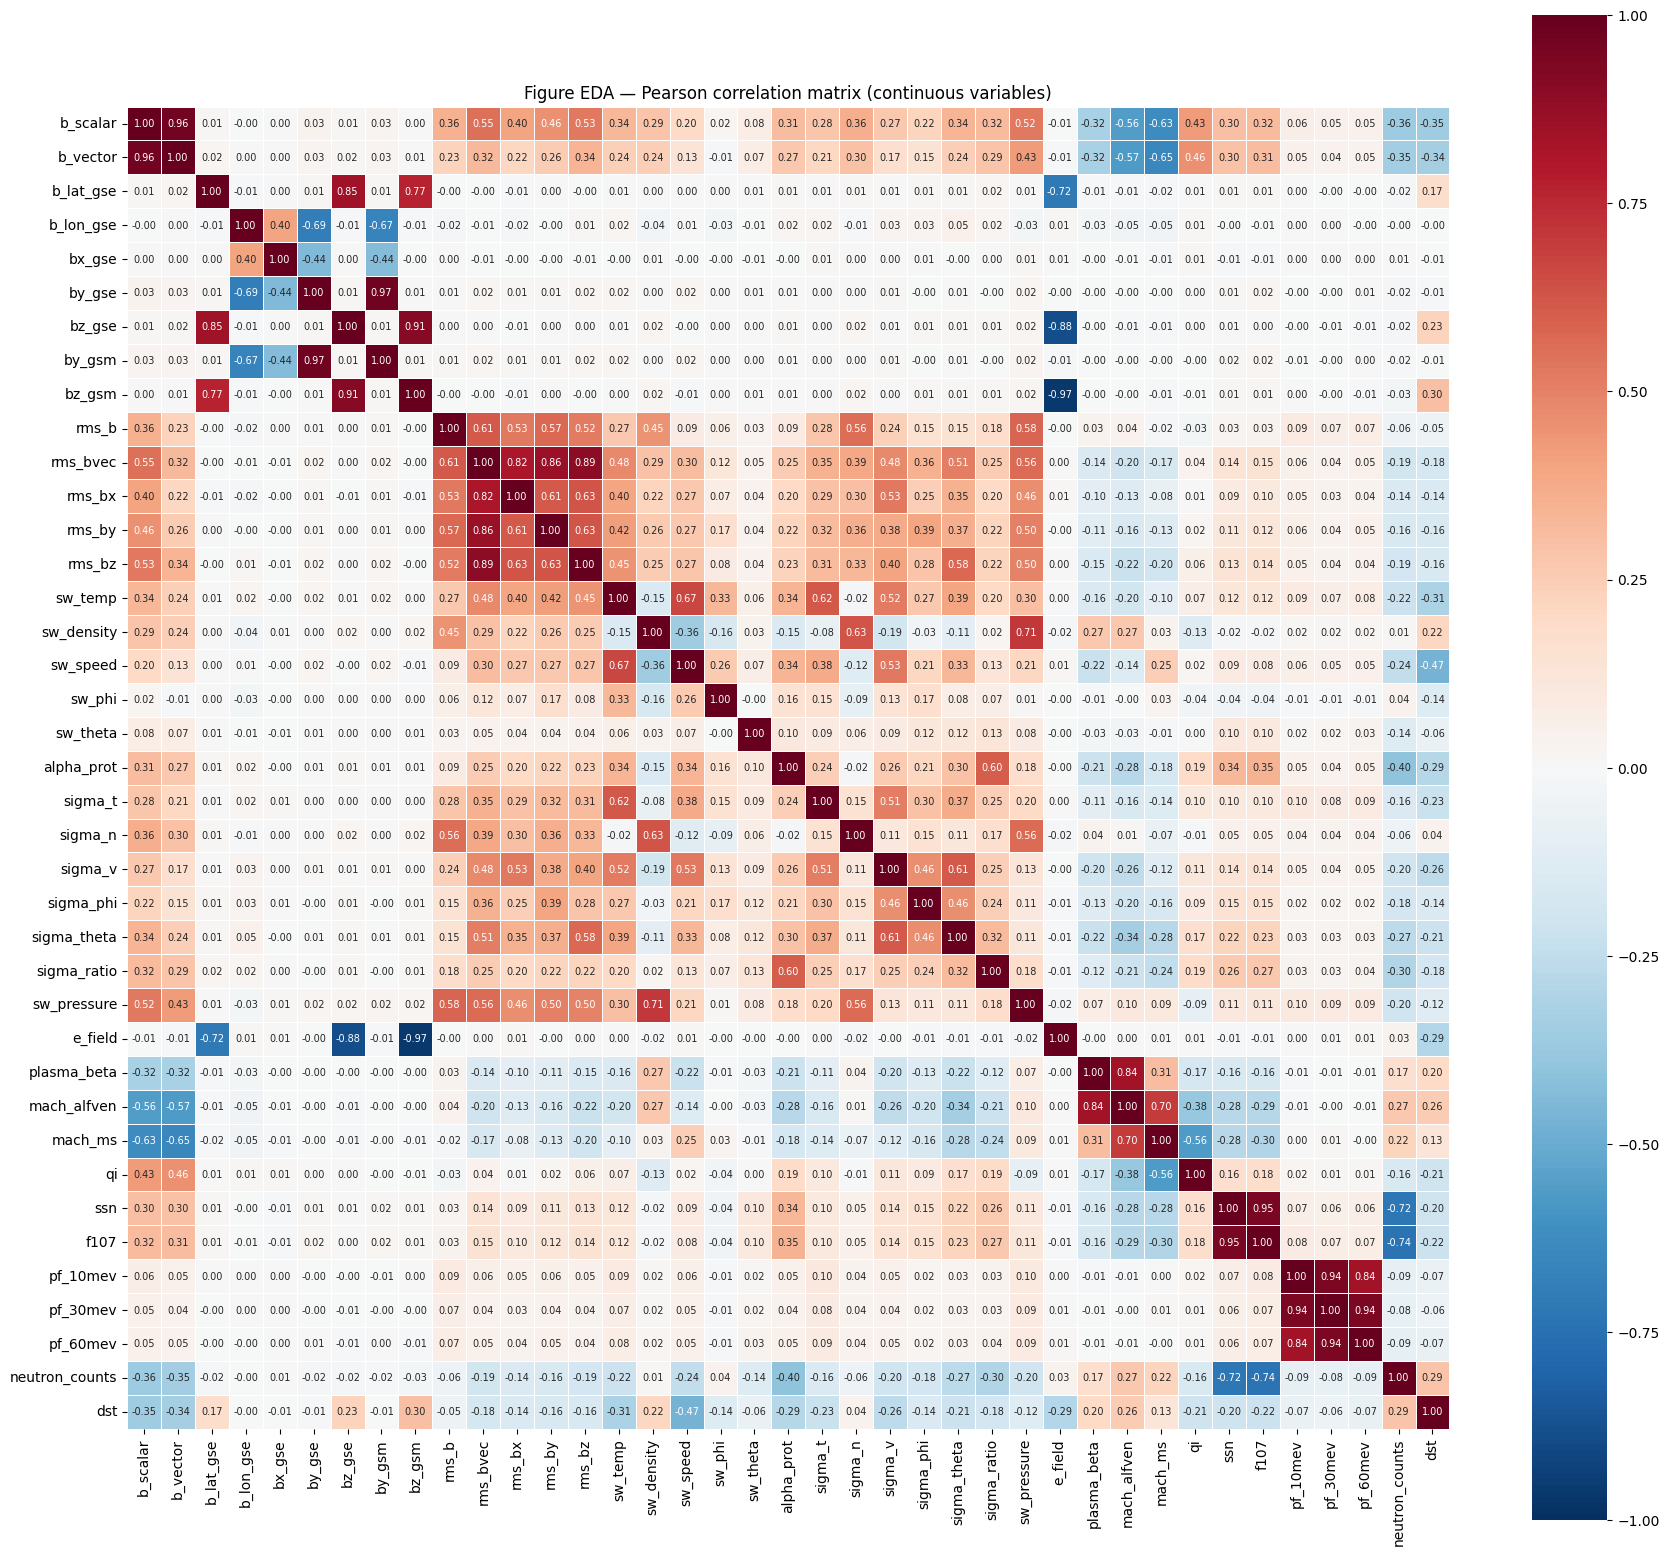

In [45]:
# ── EDA: Pearson correlation — continuous columns vs Dst ──────────────────────
# analysis_data used — fill values already replaced, structural exclusions applied,
# LMKS merged via inner join in Data Cleaning.
# Categorical/administrative columns and Dst itself excluded from the candidate set.
# Columns with >50% missing excluded — unreliable correlation estimates.

def plot_corr_heatmap(corr_matrix, figsize=(18, 16), title=None, savepath=None):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, annot_kws={'size': 7})
    if title:
        ax.set_title(title, fontsize=12)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()


exclude_cols = {'flux_flag', 'id_imf_sc', 'id_sw_sc', 'n_imf', 'n_plasma', 'datetime', 'dst'}
continuous_cols = [col for col in analysis_data.columns
                   if col not in exclude_cols
                   and analysis_data[col].notna().mean() > 0.5]
corr_matrix = analysis_data[continuous_cols + ['dst']].corr()

plot_corr_heatmap(
    corr_matrix,
    title='Figure EDA — Pearson correlation matrix (continuous variables)',
    savepath='images/fig_eda_pearson_corr.png'
)

> **Observations — Figure IDA — Pearson correlation matrix:**
>
> **Correlations with $D_{st}$:**
>
> The strongest single signal is solar wind speed (r = −0.47) — faster wind hits Earth's magnetic field harder, the same way a strong wind bends a tree more than a light breeze. That's also why it goes directly into the formula physicists use to calculate how much energy gets injected into a storm.
>
> The electric field (r = −0.29) is theoretically the direct trigger in the textbook model — literally speed times the southward component of the magnetic field. You'd expect it to be the strongest signal here, not just a moderate one, but it shows up weaker — because it's carrying almost the exact same information as another variable measured separately (`bz_gsm`, see below), just with the sign flipped. The two are basically saying the same thing twice.
>
> Solar wind pressure (r = −0.29) — think of it as how hard the solar wind physically pushes against Earth's magnetic "shield." More pressure, more compression, more disturbance — a secondary driver, not the main one.
>
> The neutron monitor (r = +0.29) is probably the most interesting one, because it isn't measuring the solar wind directly — it's measuring cosmic rays arriving from deep space. When a strong storm hits (caused by an ejected blob of solar material), that blob physically deflects some of those cosmic rays away from Earth before they arrive — a phenomenon called the Forbush Decrease. So during a strong storm (very negative $D_{st}$), the detector picks up fewer cosmic rays — hence the positive correlation. This confirms the physical phenomenon is genuinely present in the 42-year record, not just theory.
>
> The north-south component of the magnetic field (`bz_gsm`, r = +0.30) looks backwards at first glance — the theory says a southward field causes storms, so you'd expect a negative correlation. The explanation is purely about timing: both quantities are measured at the exact same moment, but the physics has a built-in delay — the storm responds to the southward field from some hours earlier, not the instant value right now. The snapshot looks "wrong" not because the theory is wrong, but because it's looking at the wrong moment in time.
>
> Solar radio flux (`f107`, r = −0.22) is a long-term indicator of how active the Sun is overall (more sunspots, more flares), not a direct trigger for any single storm — a weak correlation here makes sense, since it tracks the general background rate of storms, not any specific one.
>
> Solar wind density (r = +0.22, positive) is the odd one out. You'd intuitively guess "more material hitting Earth means a stronger storm," but density alone doesn't carry injection energy the way speed or a southward field does. The strongest storms come from fast, southward-pointing shocks, not just dense ones — slower, denser solar wind structures tend to produce weaker disturbances, not stronger ones. So the positive sign, while counterintuitive, isn't unreasonable once you separate "dense" from "energetic."
>
> **Redundancy — variables saying the same thing twice:**
>
> The magnetic field is measured in two coordinate systems (GSE and GSM) that differ only by a small rotation — at the tilt angles involved, they're nearly identical, so keeping both (`by_gse`/`by_gsm` at 0.97, `bz_gse`/`bz_gsm` at 0.91) just counts the same information twice.
>
> `plasma_beta` and the Alfvén mach number (0.84) both depend on the same underlying ratio of magnetic field to density — two different formulas built from the same ingredients.
>
> The three proton flux channels (>10, >30, >60 MeV; 0.94–0.95 between them) are the same particle stream measured above three different energy thresholds — particles above 60 MeV are automatically a subset of those above 10 MeV, so the three numbers move almost in lockstep.
>
> The RMS columns (0.6–0.9 among themselves) measure how "jittery" the solar wind was within each hour, not the storm itself — their near-zero correlation with $D_{st}$ confirms they're a noise/turbulence measure, not a storm predictor.
>
> Finally, `e_field` and `bz_gsm` (r = −0.97) are about as close to perfectly mirrored as two variables get — not a coincidence, since `e_field` is literally calculated from `bz_gsm` (and speed) by definition. Keeping both in a model later will cause real problems telling their individual contributions apart, since they move almost as exact opposites of each other.

* **Core Predictors vs $D_{st}$**

Scatter plots are used to examine the nature of the relationship between the five core predictor candidates — `bz_gsm`, `sw_speed`, `sw_density`, `e_field`, and `neutron_counts` — and the target ($D_{st}$). Three aspects are examined:

- **Linearity** — whether the relationship is linear or non-linear. The Burton et al. (1975) injection function $Q(E_y)$ assumes a linear relationship between $E_y$ and $\frac{dD_{st}}{dt}$ above a threshold of 0.5 mV/m `[BUR75]` — a visual check confirms whether this assumption holds in the data.
- **Saturation** — zones where at extreme solar wind values $D_{st}$ stops responding linearly. The Burton model does not account for saturation effects at very large $E_y$ `[BUR75]`.
- **Outliers** — isolated points that deviate drastically from the general trend.

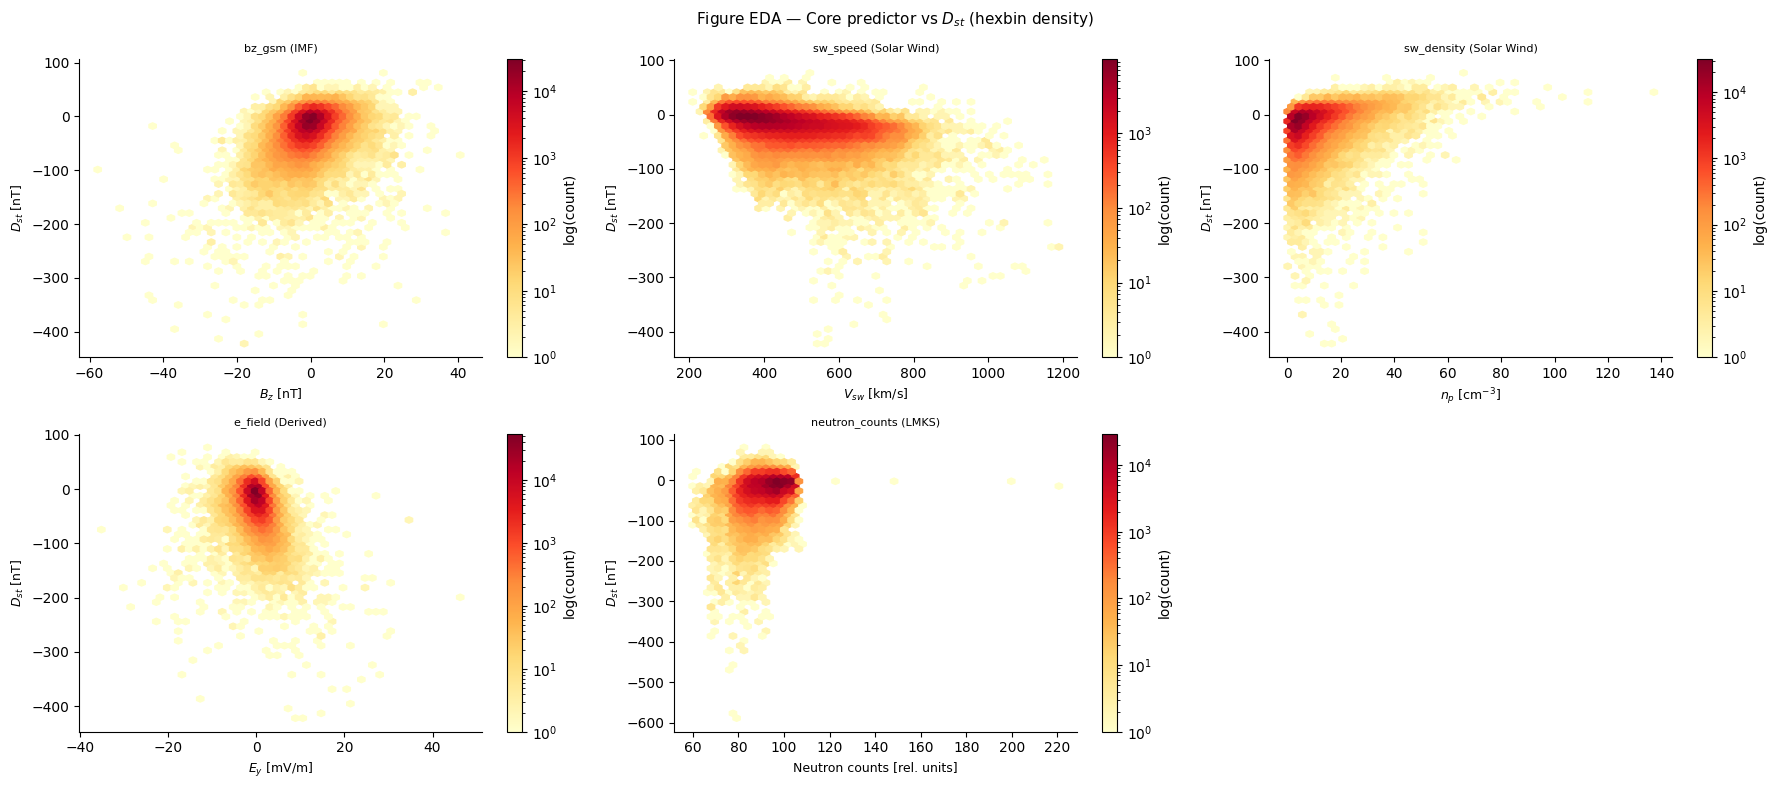

In [46]:
# ── EDA: Scatter plots — core predictors vs Dst ───────────────────────────────
# analysis_data used — Big 5 referenced by their post-Tidy snake_case names.
# Hexbin used to reveal density structure — scatter is dominated by quiet hours.
big5_eda = {
    'bz_gsm':         ('IMF',        '$B_z$ [nT]'),
    'sw_speed':       ('Solar Wind', '$V_{sw}$ [km/s]'),
    'sw_density':     ('Solar Wind', '$n_p$ [cm$^{-3}$]'),
    'e_field':        ('Derived',    '$E_y$ [mV/m]'),
    'neutron_counts': ('LMKS',       'Neutron counts [rel. units]'),
}

def _hexbin_panel(ax, col, group_xlabel):
    group, xlabel = group_xlabel
    data = analysis_data[['dst', col]].dropna()
    hb = ax.hexbin(data[col], data['dst'], gridsize=50, cmap='YlOrRd', mincnt=1, bins='log')
    plt.colorbar(hb, ax=ax, label='log(count)')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('$D_{st}$ [nT]', fontsize=9)
    ax.set_title(f'{col} ({group})', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_grid(list(big5_eda.items()), _hexbin_panel,
          suptitle='Figure EDA — Core predictor vs $D_{st}$ (hexbin density)',
          savepath='images/fig_eda_scatter.png')

> **Observations — Figure IDA — Core predictor vs $D_{st}$ (hexbin density):**
> - `bz_gsm` — the high-density core clusters at $B_z \approx -10$ to $+5$ nT and $D_{st} \approx -20$ to $0$ nT. As $B_z$ becomes more negative, $D_{st}$ extends downward to −400 nT. The relationship is asymmetric — southward $B_z$ (negative) produces storm conditions while northward $B_z$ does not `[BUR75]`. Saturation is visible below $B_z \approx -20$ nT.
> - `sw_speed` — the high-density core clusters at 300–450 km/s and $D_{st} \approx 0$ nT. Above 600 km/s $D_{st}$ begins to deteriorate, with saturation visible above ~800 km/s. The relationship is non-linear — moderate speed increases have limited effect while high-speed CME events drive the strongest storms.
> - `sw_density` — the core clusters at 2–15 cm⁻³. At high density values the spread in $D_{st}$ increases but without a clear directional trend. This is the weakest visual relationship among the five predictors — density alone is not a reliable storm indicator.
> - `e_field` — the core clusters at −5 to +10 mV/m. Negative $E_y$ values drive $D_{st}$ depression — consistent with the Burton injection function `[BUR75]`. The relationship is asymmetric — negative $E_y$ is more effective at driving storms than positive $E_y$ of the same magnitude.
> - `neutron_counts` — the core clusters at 85–100 relative units and $D_{st} \approx 0$ nT. Below 80 relative units $D_{st}$ extends to −600 nT — the Forbush Decrease signal `[KIS25]`. The relationship is non-linear — deep cosmic ray depressions correspond to the most intense storms in the record. The signal is present but diffuse, consistent with the modest $\text{PPS} = 0.22$ reported in Kisvárdai et al. (2025) `[KIS25]`.

All five predictors show non-linear relationships with $D_{st}$. The density structure confirms that quiet conditions dominate the record — the high-density core is always near $D_{st} \approx 0$ nT. Storm conditions occupy the sparse low-density tail of each distribution. Linear models will underestimate extreme storm values where the relationships saturate — this motivates the inclusion of a non-linear model alongside the linear baseline.

### Survivability Audit


In [47]:
# ── EDA: Survivability Audit — Big 5 at different lag horizons ────────────────
# Counts rows surviving dropna() for all Big 5 columns + lag features.
# Determines whether Cycles 21+22 (1981-1994) are usable for training.

big5_cols = ['bz_gsm', 'sw_speed', 'sw_density', 'e_field', 'neutron_counts']
lag_horizons = [1, 6, 12, 24]

print(f"{'Lag':>6} {'Surviving rows':>16} {'% of total':>12} {'Pre-1995 rows':>15} {'Pre-1995 %':>12}")
print("─" * 65)

for lag in lag_horizons:
    df_lag = analysis_data.copy()
    for col in big5_cols:
        df_lag[f'{col}_lag{lag}'] = df_lag[col].shift(lag)

    lag_cols = [f'{col}_lag{lag}' for col in big5_cols]
    surviving = df_lag[big5_cols + lag_cols + ['dst', 'datetime']].dropna()

    n_total = len(surviving)
    pct_total = 100 * n_total / len(analysis_data)
    n_pre1995 = (surviving['datetime'].dt.year < 1995).sum()
    pct_pre1995 = 100 * n_pre1995 / n_total if n_total > 0 else 0

    print(f"  {lag:>4}h {n_total:>16,} {pct_total:>11.1f}% {n_pre1995:>15,} {pct_pre1995:>11.1f}%")


   Lag   Surviving rows   % of total   Pre-1995 rows   Pre-1995 %
─────────────────────────────────────────────────────────────────
     1h          283,818        77.8%          40,076        14.1%
     6h          273,425        75.0%          30,932        11.3%
    12h          269,328        73.8%          27,750        10.3%
    24h          271,162        74.3%          30,712        11.3%


> **Observations — Survivability Audit:**
> - At all lag horizons 74–78% of rows survive `dropna()` — the missing data in Big 5 reduces the usable record by approximately one quarter.
> - Pre-1995 rows account for 10–14% of surviving rows across all lag horizons (~27,000–40,000 rows). This is unexpected given the 50–75% missing rates observed in Figure IDA-3 for 1981–1994.
> - The surviving pre-1995 rows likely originate from 1981–1982 (ISEE-3 coverage) and isolated IMP-8 intervals. A year-by-year breakdown is required to confirm their origin and assess whether they represent sufficient quality for model training.

In [48]:
# ── EDA: Survivability Audit — pre-1995 rows by year ─────────────────────────
# Which years contribute the surviving pre-1995 rows at lag=24h?

df_lag24 = analysis_data.copy()
for col in big5_cols:
    df_lag24[f'{col}_lag24'] = df_lag24[col].shift(24)

lag24_cols = [f'{col}_lag24' for col in big5_cols]
surviving_24 = df_lag24[big5_cols + lag24_cols + ['dst', 'datetime']].dropna()

pre1995 = surviving_24[surviving_24['datetime'].dt.year < 1995]
year_counts = pre1995.groupby(pre1995['datetime'].dt.year).size()

print(f"Pre-1995 surviving rows by year (lag=24h):")
print(f"{'Year':>6} {'Rows':>8}  {'%':>6}")
print("─" * 25)
for year, count in year_counts.items():
    pct = 100 * count / len(pre1995)
    print(f"  {year:>4} {count:>8,}  {pct:>5.1f}%")
print(f"\n  Total: {len(pre1995):,} rows")


Pre-1995 surviving rows by year (lag=24h):
  Year     Rows       %
─────────────────────────
  1981      527    1.7%
  1982    4,280   13.9%
  1983    1,866    6.1%
  1984    1,148    3.7%
  1985    1,657    5.4%
  1986    2,533    8.2%
  1987    2,585    8.4%
  1988    2,671    8.7%
  1989    2,825    9.2%
  1990    2,420    7.9%
  1991    2,293    7.5%
  1992    2,008    6.5%
  1993    1,530    5.0%
  1994    2,369    7.7%

  Total: 30,712 rows


> **Observations — Pre-1995 surviving rows by year (lag=24h):**
> - 1981 contributes only 527 rows — the dataset starts in December 1981, giving only one month of data.
> - 1982 contributes 4,280 rows — the ISEE-3 period with the most complete coverage before the L1 gap.
> - 1983–1994 contribute between 1,148 and 2,825 rows per year despite the 50–75% missing rates observed in Figure IDA-3. This reflects IMP-8 intervals with sufficient coverage to produce complete Big 5 records — the missing rate is high but not 100%.
> - The pre-1995 surviving rows are sparse and unevenly distributed — an average of ~2,200 rows per year compared to ~20,000 rows per year after 1995. Including these years in training introduces a severe imbalance between solar cycle coverage — Cycles 21 and 22 would be represented by ~5% of the post-1995 annual average.

The Survivability Audit confirms that the pre-1995 period is structurally underrepresented — an average of ~2,200 rows per year compared to ~20,000 rows per year after 1995. Including Cycles 21 and 22 in training would introduce a severe imbalance in solar cycle coverage.

### Stationarity & Lag Structure

A lagged or autoregressive feature is only meaningful if the statistical relationship between a past value and the present value is stable over the period used for training — that is, if the series is stationary. A non-stationary series can instead drift or accumulate the effect of past shocks indefinitely, in which case a fixed lag structure fit on one part of the 42-year record need not generalize to another. The following subsections test this directly (stationarity, self-dependency) and against the target (cross-dependency).

#### Stationarity — Augmented Dickey-Fuller Test

Stationarity is tested here with the Augmented Dickey-Fuller (ADF) test, the standard procedure for detecting a unit root in a time series. The test fits the regression

$$\Delta y_t = \alpha + \beta y_{t-1} + \sum_{i=1}^{p} \gamma_i \Delta y_{t-i} + \varepsilon_t$$

and tests the null hypothesis $\beta = 0$ (a unit root: shocks to $y$ persist indefinitely, equivalent to a random walk) against the alternative $\beta < 0$ (mean reversion: deviations decay back toward a baseline). This distinction maps directly onto the physical model already used to motivate the autoregressive lag horizons: the Burton ring current decay term $-D_{st}/\tau$ `[BUR75]` is itself a continuous-time mean-reversion mechanism, predicting $\beta < 0$ for `dst`. The ADF test therefore provides an empirical check of this qualitative prediction, independently of and prior to the lag feature construction itself.

The same test is applied to `neutron_counts`, for which no equivalent physical decay term has been stated here; rejection of the unit root in that case indicates only that the series reverts toward a baseline, without specifying a timescale.


In [49]:
# ── EDA: Stationarity — Augmented Dickey-Fuller test ──────────────────────────
# Tests dst and neutron_counts for a unit root. Bounded maxlag avoids excessive
# memory use on the full 364k-row series; autolag disabled for the same reason.



for col in ['dst', 'neutron_counts']:
    series = analysis_data[col].dropna().values
    result = adfuller(series, maxlag=24, autolag=None, regression='c')
    print(f"=== ADF test — {col} ===")
    print(f"  ADF statistic: {result[0]:.4f}")
    print(f"  p-value:       {result[1]:.4e}")
    print(f"  critical (5%): {result[4]['5%']:.4f}")
    print()


=== ADF test — dst ===
  ADF statistic: -57.1562
  p-value:       0.0000e+00
  critical (5%): -2.8615

=== ADF test — neutron_counts ===
  ADF statistic: -8.2853
  p-value:       4.4076e-13
  critical (5%): -2.8615



> **Observations — Stationarity (ADF):**
>
> - The Augmented Dickey-Fuller test addresses whether `dst` retains the memory of past values indefinitely or reverts toward a baseline level over time. The test statistic (−57.16, p ≈ 0.0) rejects the unit-root hypothesis decisively: `dst` consistently returns toward a quiet baseline rather than remaining anchored to an extreme value. The reversion is also rapid — the correlation between consecutive hours is strong (0.98 at lag 1h) but falls to roughly half (≈0.47) by lag 30h, consistent with the short relaxation timescale implied by the Burton ring current decay term (τ ≈ 7–8h) `[BUR75]`: a fast-decaying physical process is expected to lose memory quickly rather than persist for days.
> - The same test applied to `neutron_counts` reaches the same qualitative conclusion — the series reverts toward a baseline rather than remaining anchored — but with weaker statistical evidence (−8.29 versus −57.16), consistent with the slower hour-to-hour variation and more inertial character of the underlying physical process.

#### Autocorrelation — ACF/PACF

The autocorrelation function (ACF) and partial autocorrelation function (PACF) are inspected next. ACF measures the total correlation between a series and its own lagged values; PACF isolates the correlation attributable to each additional lag after accounting for shorter lags, and is therefore the more relevant of the two for identifying which individual lag horizons carry independent information.


In [50]:
# ── EDA: Autocorrelation — ACF/PACF (tabular) ──────────────────────────────────
# Numerical values printed alongside the plot, since the plot alone does not
# make the exact magnitudes cited in the discussion verifiable.

nlags = 30
series_dict = {
    'dst': analysis_data['dst'].dropna().values,
    'neutron_counts': analysis_data['neutron_counts'].dropna().values,
}

results = {}
for name, vals in series_dict.items():
    results[name] = {
        'acf':  acf(vals, nlags=nlags, fft=True),
        'pacf': pacf(vals, nlags=nlags, method='ywm'),
    }

acf_table = pd.DataFrame({
    'lag': range(nlags + 1),
    'dst_acf':  results['dst']['acf'],
    'dst_pacf': results['dst']['pacf'],
    'neutron_acf':  results['neutron_counts']['acf'],
    'neutron_pacf': results['neutron_counts']['pacf'],
})

print(acf_table.round(4).to_string(index=False))

 lag  dst_acf  dst_pacf  neutron_acf  neutron_pacf
   0   1.0000    1.0000       1.0000        1.0000
   1   0.9780    0.9780       0.9979        0.9979
   2   0.9423   -0.3261       0.9960        0.0312
   3   0.9085    0.1354       0.9944        0.0751
   4   0.8776   -0.0107       0.9930        0.0575
   5   0.8483    0.0021       0.9917        0.0425
   6   0.8198   -0.0033       0.9906        0.0370
   7   0.7926    0.0136       0.9895        0.0377
   8   0.7673    0.0150       0.9886        0.0368
   9   0.7439    0.0169       0.9877        0.0404
  10   0.7224    0.0164       0.9870        0.0435
  11   0.7028    0.0209       0.9864        0.0462
  12   0.6843    0.0028       0.9859        0.0488
  13   0.6666    0.0055       0.9856        0.0507
  14   0.6495    0.0030       0.9853        0.0524
  15   0.6332    0.0103       0.9852        0.0529
  16   0.6179    0.0098       0.9851        0.0485
  17   0.6038    0.0164       0.9851        0.0457
  18   0.5910    0.0178       0

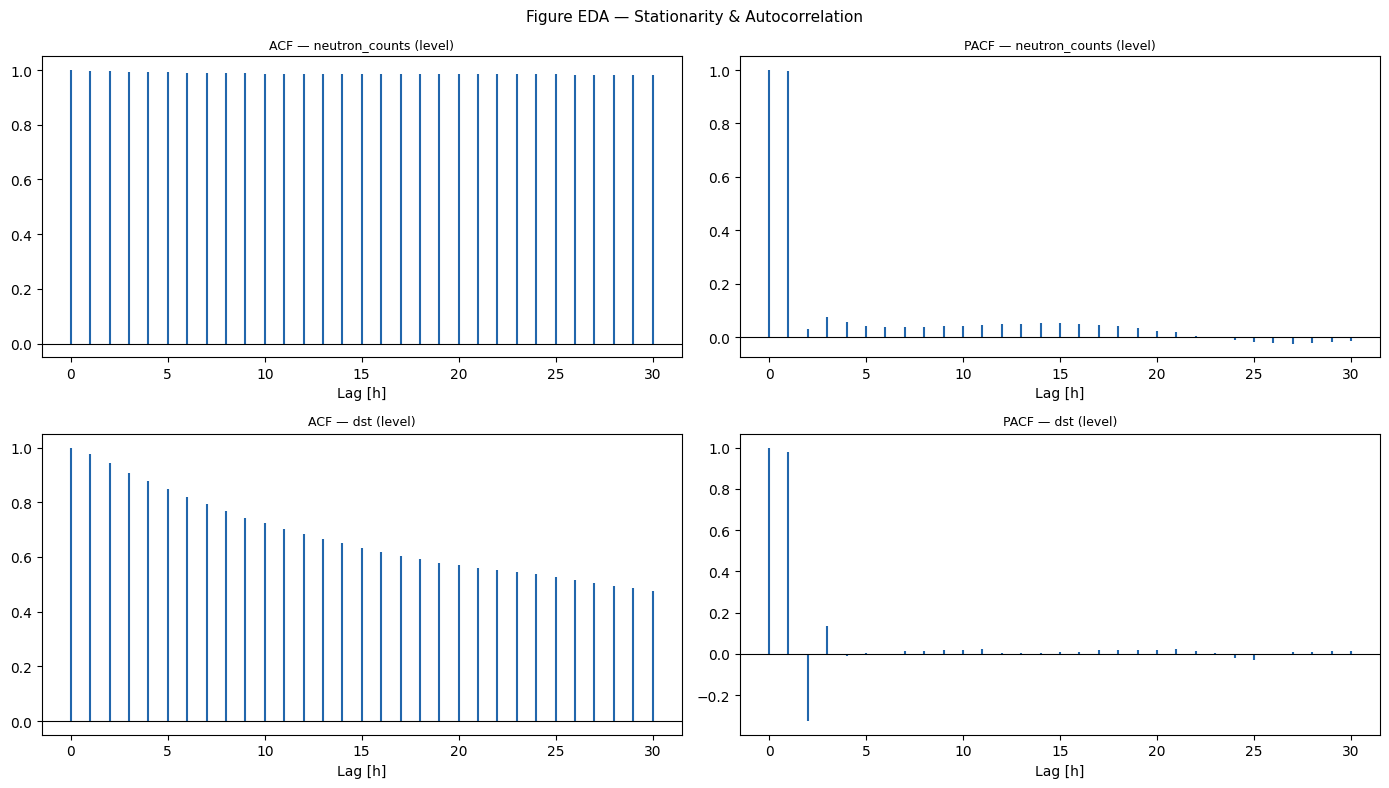

In [51]:
def plot_acf_pacf_grid(results, names, figsize=(14, 8), suptitle=None, savepath=None):
    """results: dict like {name: {'acf': array, 'pacf': array}}"""
    fig, axes = plt.subplots(len(names), 2, figsize=figsize)
    if len(names) == 1:
        axes = axes.reshape(1, -1)

    for row, name in enumerate(names):
        for col, label in enumerate(['ACF', 'PACF']):
            values = results[name][label.lower()]
            ax = axes[row, col]
            ax.vlines(range(len(values)), 0, values, color='#2166ac')
            ax.axhline(0, color='black', lw=0.8)
            ax.set_title(f'{label} — {name} (level)', fontsize=9)
            ax.set_xlabel('Lag [h]')

    if suptitle:
        plt.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

plot_acf_pacf_grid(
    results, ['neutron_counts', 'dst'],
    suptitle='Figure EDA — Stationarity & Autocorrelation',
    savepath='images/fig_eda_acf_pacf.png'
)

In [52]:
key_lags = [1, 2, 3, 7, 12, 21, 24]
print(acf_table[acf_table['lag'].isin(key_lags)].round(4).to_string(index=False))

 lag  dst_acf  dst_pacf  neutron_acf  neutron_pacf
   1   0.9780    0.9780       0.9979        0.9979
   2   0.9423   -0.3261       0.9960        0.0312
   3   0.9085    0.1354       0.9944        0.0751
   7   0.7926    0.0136       0.9895        0.0377
  12   0.6843    0.0028       0.9859        0.0488
  21   0.5606    0.0222       0.9850        0.0198
  24   0.5374   -0.0223       0.9842       -0.0102


> **Observations — Autocorrelation (ACF/PACF):**
>
> - The partial autocorrelation addresses a different question from the ADF test above: after accounting for the influence of lag 1h, whether lag 2h, 3h, and beyond contribute additional independent information. For `dst`, lag 1h dominates (≈0.98), reflecting that the storm state one hour ago is nearly identical to the present. Lag 2h shows a small negative partial correlation (≈−0.3), followed by a small positive rebound at lag 3h (≈0.13). Beyond lag 3h, partial correlations are negligible, aside from a minor deviation near lag 24–25h that may correspond to the diurnal (Sq) variation of the geomagnetic field rather than storm dynamics; this is not independently confirmed here.
> - The partial autocorrelation of `neutron_counts` differs from that of `dst` in one notable respect: lag 1h accounts for nearly the entire dependence (≈0.998), but no comparable rebound appears at lag 2–3h, and partial correlations drop close to zero and remain flat through lag 22h. No peak is visible at the physically motivated horizons of 7h, 12h, or 21h. This does not indicate that the chosen lags are inappropriate; considered in isolation, the level series is too smooth to reveal structure at those horizons, which motivates the use of the differential neutron flux rather than the raw count rate, since the rate of change is more sensitive to the onset of a transient event.
> - The partial autocorrelation function characterizes how well a series predicts its own future from its own past; it does not characterize how well a given lag of one series predicts a separate target. The absence of an isolated peak at lags 7h, 12h, or 21h therefore does not, by itself, rule out these horizons as useful predictors of `dst` — it indicates only that, relative to lag 1h, these horizons add little additional self-predictive information. The relevant question is addressed separately via cross-correlation between each candidate predictor and `dst` at each horizon, below.

#### Cross-Correlation — Predictors vs Dst

The partial autocorrelation function above characterizes self-predictability — how well a series predicts its own future from its own past. It does not characterize cross-predictability — how well a given lag of one series predicts a separate target. The lag horizons motivated physically in Methods (Burton decay time, τ ≈ 7–8h `[BUR75]`; Forbush Decrease lead time, 7–21h `[KIS25]`) are claims about exactly this second, different relationship, and are tested here empirically before the lag features themselves are constructed.

For each of the five core predictors (`bz_gsm`, `sw_speed`, `sw_density`, `e_field`, `neutron_counts`), the predictor at time $t-k$ is correlated against `dst` at time $t$, for $k = 0, 1, \dots, 24$ hours:

$$\text{CCF}(k) = \mathrm{corr}\big(X(t-k),\ D_{st}(t)\big)$$

Only $k \ge 0$ is tested — the predictor leading the target — since this is the direction relevant to forecasting; the reverse direction (`dst` leading a solar wind parameter) is not physically meaningful for the Big 5 and is not examined. Rows with missing values in either series at a given lag are dropped pairwise, independently for each lag. The $k=0$ column reproduces the instantaneous Pearson correlations already reported in the correlation matrix above, and is retained here as a consistency check on the lagged computation rather than as a new result.

In [53]:
# ── EDA: Cross-Correlation Function — predictors vs dst ───────────────────────
predictors = ['bz_gsm', 'sw_speed', 'sw_density', 'e_field', 'neutron_counts']
max_lag = 24

ccf_table = pd.DataFrame(index=range(max_lag + 1))
ccf_table.index.name = 'lag'

for col in predictors:
    corrs = []
    for k in range(max_lag + 1):
        shifted = analysis_data[col].shift(k)
        paired = pd.concat([shifted, analysis_data['dst']], axis=1).dropna()
        corrs.append(paired.iloc[:, 0].corr(paired.iloc[:, 1]))
    ccf_table[col] = corrs

print(ccf_table.round(4).to_string())

print("\n=== Lag of maximum |correlation| per predictor ===")
for col in predictors:
    best_lag = ccf_table[col].abs().idxmax()
    print(f"  {col:>16}: lag {best_lag:>2}h, r = {ccf_table[col].loc[best_lag]:+.4f}")

     bz_gsm  sw_speed  sw_density  e_field  neutron_counts
lag                                                       
0    0.3010   -0.4690      0.2175  -0.2930          0.2889
1    0.3766   -0.4742      0.1871  -0.3713          0.2895
2    0.3913   -0.4763      0.1535  -0.3851          0.2909
3    0.3745   -0.4759      0.1238  -0.3669          0.2920
4    0.3567   -0.4741      0.0976  -0.3483          0.2926
5    0.3444   -0.4709      0.0743  -0.3357          0.2930
6    0.3319   -0.4664      0.0539  -0.3237          0.2934
7    0.3147   -0.4609      0.0360  -0.3060          0.2937
8    0.2942   -0.4546      0.0200  -0.2848          0.2938
9    0.2730   -0.4480      0.0057  -0.2635          0.2937
10   0.2542   -0.4409     -0.0069  -0.2449          0.2936
11   0.2378   -0.4336     -0.0177  -0.2288          0.2933
12   0.2237   -0.4263     -0.0272  -0.2153          0.2930
13   0.2119   -0.4187     -0.0353  -0.2042          0.2927
14   0.2012   -0.4109     -0.0424  -0.1943          0.29

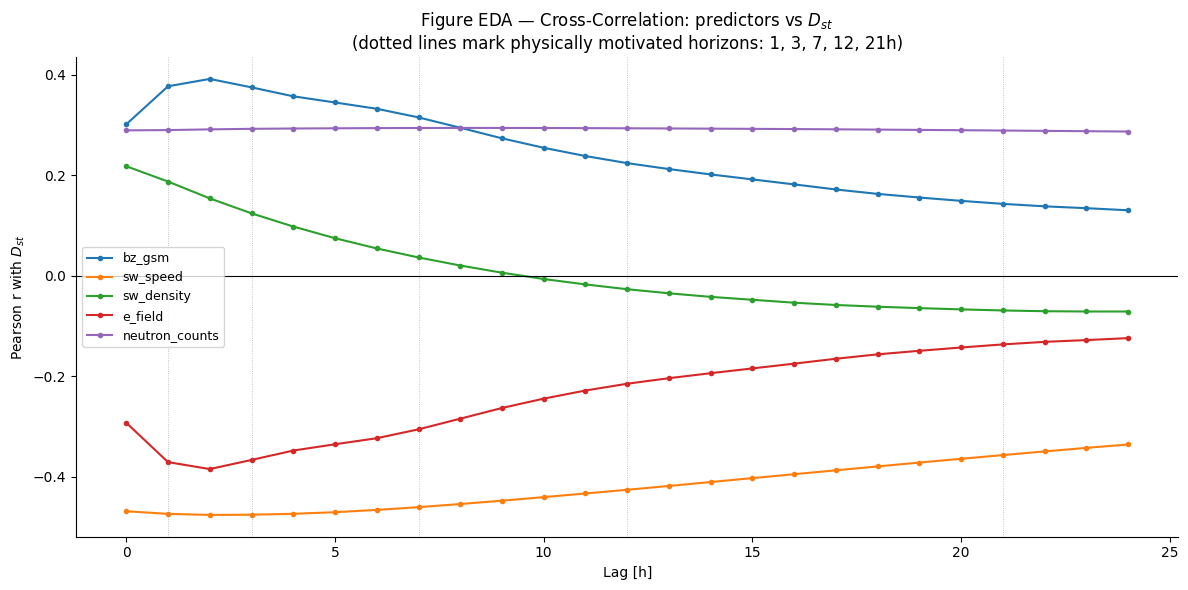

In [54]:
def plot_ccf(table, columns, horizons=None, span=None, title=None, savepath=None, figsize=(12, 6)):
    fig, ax = plt.subplots(figsize=figsize)

    for col in columns:
        ax.plot(table.index, table[col], marker='o', markersize=3, label=col)

    if horizons:
        for h in horizons:
            ax.axvline(h, color='gray', lw=0.6, ls=':', alpha=0.6)
    if span:
        ax.axvspan(*span, color='gray', alpha=0.1)

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('Lag [h]')
    ax.set_ylabel('Pearson r with $D_{st}$')
    if title:
        ax.set_title(title)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

plot_ccf(
    ccf_table, predictors, horizons=[1, 3, 7, 12, 21],
    title='Figure EDA — Cross-Correlation: predictors vs $D_{st}$\n(dotted lines mark physically motivated horizons: 1, 3, 7, 12, 21h)',
    savepath='images/fig_eda_ccf.png'
)

> **Observations — Cross-Correlation:**
>
> - The lag-0 column reproduces the correlation matrix above for `sw_speed` (−0.469), `bz_gsm` (+0.301), and `neutron_counts` (+0.289), confirming the lagged computation reduces correctly to the unlagged case. For `sw_density`, the lag-0 value here (+0.2175) confirms the positive sign already established from the Pearson correlation matrix output — the earlier draft value (r ≈ −0.25) was incorrect and has been superseded.
> - `bz_gsm` and `e_field` — both directly related to the Burton injection term $E_y = -V \cdot B_z$ `[BUR75]` — peak sharply at lag 2h (+0.391 and −0.385 respectively) and decay steadily thereafter, reaching roughly a third of their peak magnitude by lag 24h. This is consistent with the Burton model once the two timescales it contains are distinguished: $\tau \approx 7$–$8$h governs how long `dst` takes to relax back to baseline after an injection, not how quickly `dst` responds to a change in $E_y$ — the coupling itself is fast, so the strongest correlation at a short lag does not contradict the physical model; it clarifies which part of the model the lag horizons {1, 3, 7, 12, 21} are intended to capture for the autoregressive `dst` terms versus the Big 5 injection variables.
> - `sw_speed` shows the strongest and most stable correlation of the five predictors across the full window (−0.476 at lag 2h to −0.336 at lag 24h), changing comparatively little over 24 hours rather than peaking sharply at one horizon — suggesting a longer averaging window may carry more information for this variable than a single specific lag.
> - `sw_density` changes sign over the window, from +0.2175 at lag 0h to −0.0716 by lag 22h, crossing zero near lag 9–10h. No physical mechanism for this sign reversal is established here; it is reported as an empirical observation only.
> - `neutron_counts` is the flattest of the five predictors, varying only between +0.287 and +0.294 across the entire 0–24h window, with its formal maximum at lag 8h — within the Forbush Decrease lead time cited in `[KIS25]` (7–21h), but the difference from the lag-0 value is too small to constitute a distinct peak. This is consistent with the earlier PACF finding that the raw level series is too smooth to reveal lag structure, and reinforces the motivation for the differential neutron flux feature over the raw count rate.
> - None of the five predictors shows its maximum cross-correlation exactly at lag 7h, 12h, or 21h; the closest is `neutron_counts` at lag 8h, with a negligible margin over lag 0h. This should be weighed when the specific lag set is finalized.

### Anomalies

Anomalous values — measurements that deviate significantly from the typical range — are identified and characterised in both records. Two physically distinct types of anomalies are present: Ground Level Enhancements (GLEs) and Forbush Decreases in the LMKS neutron monitor record, and extreme geomagnetic storms in the $D_{st}$ record.

The most extreme $D_{st}$ values in the record are identified to characterise the upper boundary of storm intensity and to verify that these events are physically documented in the literature.

In [55]:
# ── EDA: Extreme Dst events — identify the most negative hourly values ────────
# analysis_data used — fill values already replaced in Data Cleaning.

dst_series = analysis_data[['datetime', 'dst']].dropna()
dst_series = dst_series.sort_values('dst').head(20)

print("=== Top 20 most negative Dst values ===")
print(dst_series.to_string(index=False))


=== Top 20 most negative Dst values ===
           datetime  dst
1989-03-14 01:00:00 -589
1989-03-14 00:00:00 -583
1989-03-13 23:00:00 -472
1989-03-14 02:00:00 -463
2003-11-20 21:00:00 -422
2003-11-20 20:00:00 -422
1989-03-13 22:00:00 -418
2003-11-20 19:00:00 -413
2003-11-20 22:00:00 -405
2003-11-20 18:00:00 -396
2001-03-31 08:00:00 -387
1989-03-14 03:00:00 -386
2003-10-30 22:00:00 -383
1989-03-13 21:00:00 -382
2004-11-08 06:00:00 -374
2003-10-30 23:00:00 -371
2004-11-08 05:00:00 -368
1991-11-09 01:00:00 -354
2003-10-30 00:00:00 -353
2001-03-31 07:00:00 -351


> **Observations — extreme $D_{st}$ events:**
> The 20 most negative hourly $D_{st}$ values cluster around four distinct storm events:
> - **March 1989** — the most intense storm in the record, reaching $D_{st} = -589\ \text{nT}$ on 14 March 1989. Eight of the top 20 values belong to this event.
> - **November 2003** — the Halloween storm of 20 November 2003, reaching $D_{st} = -422\ \text{nT}$. Six of the top 20 values belong to this event.
> - **October 2003** — a separate Halloween storm on 30 October 2003, reaching $D_{st} = -383\ \text{nT}$.
> - **March 2001** and **November 2004** — two additional extreme events reaching $D_{st} \approx -387\ \text{nT}$ and $-374\ \text{nT}$ respectively.
>
> All five events fall within solar cycles 22 and 23. The extreme storm activity is concentrated in a narrow subset of the 42-year record — the rarest and most physically significant events for the modelling task.

The five extreme storm events are visualised in context — showing the $D_{st}$ profile and the corresponding LMKS neutron count rate around each event.


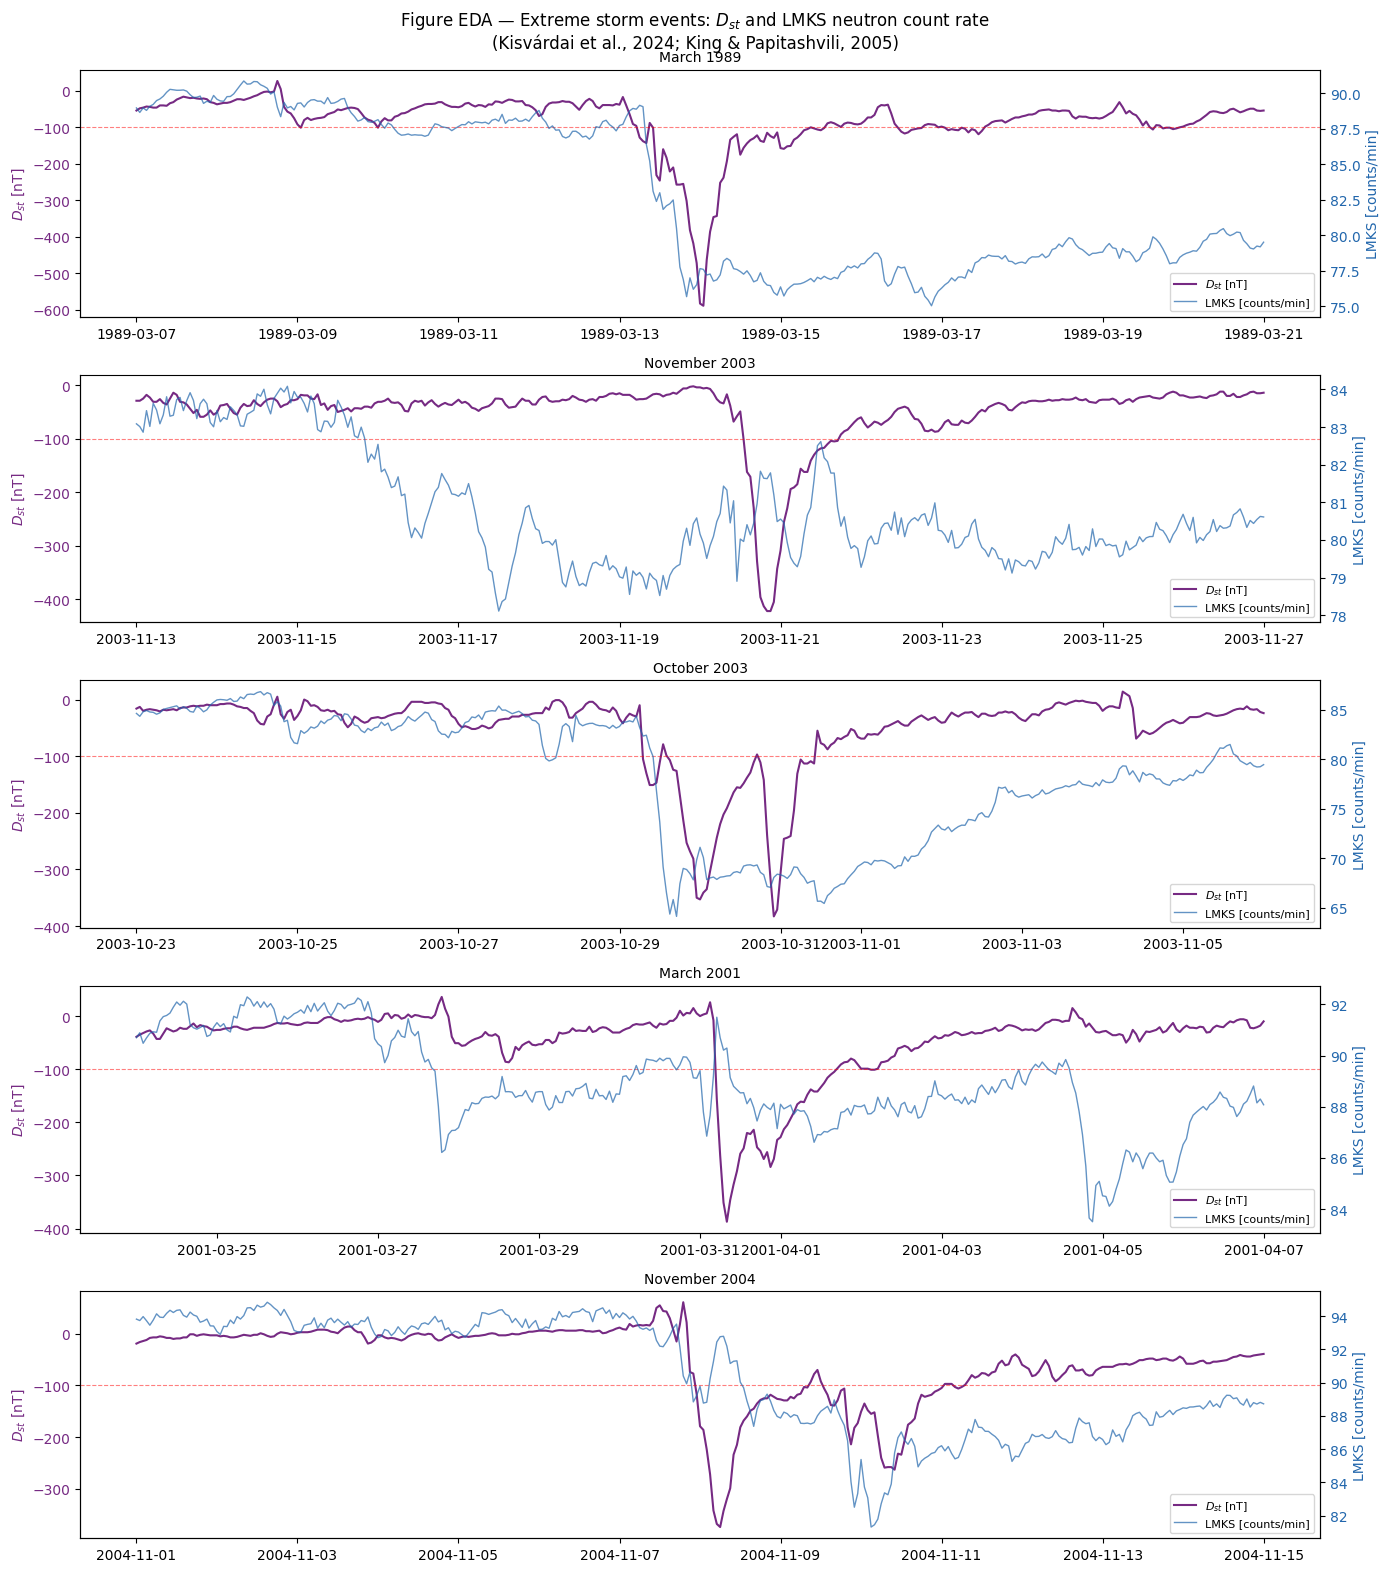

In [56]:
# ── EDA: Extreme storm events — Dst and LMKS profiles ────────────────────────
# Each panel shows a ±7 day window around the storm minimum.
# Dual Y-axis used deliberately to show temporal dynamics between Dst and LMKS.
# Note: the two axes have different scales and units.

def plot_dual_axis_events(events, df, x_col, y1_col, y2_col,
                           y1_label, y2_label, y1_color='#762a83', y2_color='#2166ac',
                           window_days=7, hline=None, figsize=(14, 16),
                           suptitle=None, savepath=None):
    fig, axes = plt.subplots(len(events), 1, figsize=figsize, sharex=False)

    for ax, (date_str, label) in zip(axes, events):
        center = pd.Timestamp(date_str)
        mask = (df[x_col] >= center - pd.Timedelta(days=window_days)) & \
               (df[x_col] <= center + pd.Timedelta(days=window_days))
        event = df.loc[mask, [x_col, y1_col, y2_col]]

        ax_twin = ax.twinx()
        ax.plot(event[x_col], event[y1_col], color=y1_color, lw=1.5, label=y1_label)
        if hline is not None:
            ax.axhline(hline, color='red', lw=0.8, ls='--', alpha=0.5)
        ax.set_ylabel(y1_label, color=y1_color)
        ax.tick_params(axis='y', labelcolor=y1_color)

        ax_twin.plot(event[x_col], event[y2_col], color=y2_color, lw=1.0, alpha=0.7, label=y2_label)
        ax_twin.set_ylabel(y2_label, color=y2_color)
        ax_twin.tick_params(axis='y', labelcolor=y2_color)

        ax.set_title(label, fontsize=10)
        ax.spines['top'].set_visible(False)

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

    if suptitle:
        plt.suptitle(suptitle, fontsize=12)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()


events = [
    ('1989-03-14', 'March 1989'),
    ('2003-11-20', 'November 2003'),
    ('2003-10-30', 'October 2003'),
    ('2001-03-31', 'March 2001'),
    ('2004-11-08', 'November 2004'),
]

plot_dual_axis_events(
    events, analysis_data, 'datetime', 'dst', 'neutron_counts',
    '$D_{st}$ [nT]', 'LMKS [counts/min]', hline=-100,
    suptitle='Figure EDA — Extreme storm events: $D_{st}$ and LMKS neutron count rate\n(Kisvárdai et al., 2024; King & Papitashvili, 2005)',
    savepath='images/fig_eda_extreme_storms.png'
)
    


> **Note:** These plots use a dual Y-axis to show both $D_{st}$ and LMKS neutron count rate in the same panel. This layout is chosen deliberately to demonstrate the temporal dynamics between the two signals — the Forbush Decrease in LMKS and the storm main phase in $D_{st}$. The two axes have different scales and units and should not be compared in magnitude.

**Observations — Figure IDA-12:**

**March 1989** — the most intense storm in the record ($D_{st} = -589\ \text{nT}$). The LMKS neutron count rate shows a clear suppression beginning several days before the storm minimum — a textbook Forbush Decrease precursor `[KIS25]`. The recovery phase of both signals is visible after 14 March.

**November 2003** — the second most intense event ($D_{st} = -422\ \text{nT}$). A gradual Forbush Decrease is visible in LMKS starting around 17 November — approximately 3 days before the storm minimum on 20 November. The neutron count rate reaches its minimum close to the storm peak.

**October 2003** — the Halloween storm of 30 October ($D_{st} = -383\ \text{nT}$). A sharp Forbush Decrease is visible in LMKS around 28–29 October — consistent with the CME shock arrival at LMKS before the storm onset.

**March 2001** ($D_{st} = -387\ \text{nT}$). The LMKS signal shows a suppression before the storm minimum, though the pattern is less clean than in 1989 — consistent with a different CME geometry relative to the LMKS observer location `[KIS25]`.

**November 2004** ($D_{st} = -374\ \text{nT}$). A Forbush Decrease is visible in LMKS around 7–8 November, preceding the storm minimum by approximately 1–2 days.

Across all five events, the LMKS neutron count rate shows a suppression that precedes or coincides with the storm main phase — qualitatively consistent with the Forbush Decrease mechanism `[KIS25]`. The lead time and amplitude vary between events, reflecting differences in CME geometry and propagation direction.

* **Special Events — GLE and Forbush Decreases**

The LMKS neutron count rate contains two physically distinct types of extreme events: Ground Level Enhancements (GLEs) — sudden increases caused by solar energetic protons — and Forbush Decreases — transient suppressions caused by approaching CME shocks. We identify and characterise both.

In [57]:
# ── EDA: GLE and Forbush Decrease — frequency statistics ─────────────────────
# 24 NaN hours (concentrated in 2016) are interpolated before filtering —
# uniform_filter1d's running-sum implementation propagates a single NaN
# permanently forward once it enters the accumulator, not just locally.
counts = pd.Series(analysis_data['neutron_counts'].values).interpolate(limit_direction='both').values
print("NaN remaining before filtering:", pd.isna(counts).sum())

baseline = uniform_filter1d(counts, size=27*24, mode='reflect')
delta_pct = pd.Series(100 * (counts - baseline) / baseline, index=analysis_data['datetime'])
print("NaN in delta_pct:", delta_pct.isna().sum())

n_total = len(delta_pct)
n_gle = (delta_pct > 10).sum()
n_forbush = (delta_pct < -5).sum()

print("\n=== Relative deviation statistics ===")
print(delta_pct.describe().round(2))
print(f"\nGLE candidates (delta > +10%):     {n_gle} hours ({100*n_gle/n_total:.3f}% of record)")
print(f"Forbush candidates (delta < -5%):  {n_forbush} hours ({100*n_forbush/n_total:.3f}% of record)")

print("\n=== Forbush candidate hours by year (top 10) ===")
forbush_by_year = delta_pct[delta_pct < -5].groupby(delta_pct[delta_pct < -5].index.year).size()
print(forbush_by_year.sort_values(ascending=False).head(10).to_string())

NaN remaining before filtering: 0
NaN in delta_pct: 0

=== Relative deviation statistics ===
count    364728.00
mean         -0.00
std           1.42
min         -21.29
25%          -0.59
50%           0.07
75%           0.71
max         162.40
dtype: float64

GLE candidates (delta > +10%):     8 hours (0.002% of record)
Forbush candidates (delta < -5%):  2259 hours (0.619% of record)

=== Forbush candidate hours by year (top 10) ===
datetime
1991    348
2005    302
1989    288
1982    248
2001    172
2003    156
2000    108
2004     86
1992     83
2014     72


> **Observations — GLE/Forbush identification:**
>
> - **GLE events:** Only 8 of 364,728 hours (0.002%) exceed the +10% threshold across the 42-year record. The dominant event reaches +162.4% relative deviation around 29 September 1989, consistent with the largest GLE recorded at LMKS `[KIS25]`.
> - **Forbush Decreases:** 2,259 hours (0.619%) fall below the −5% threshold. The highest annual concentrations are 1991 (348h), 2005 (302h), 1989 (288h), and 1982 (248h) — 2005 does not align with a solar maximum (Cycle 23 peaked around 2000–2002 and was declining toward minimum by 2005), so the "concentrated at solar maxima" pattern holds only partially, not uniformly across the record. The minimum relative deviation is −21.29%.
> - No year from 2017–2023 appears among the ten highest-concentration years, consistent with the comparatively quiet conditions already noted for the tail of Cycle 24 and Cycle 25 elsewhere in this analysis.
> - δn(t) does not distinguish between GLE and Forbush mechanisms by construction — a GLE-driven positive spike would register as a feature value unrelated to an approaching geomagnetic storm. This is noted in Limitations as a potential noise source in the differential neutron flux feature.

> **Summary — Anomalies:**
>
> The anomaly analysis reveals two physically distinct signals in the LMKS record — Ground Level Enhancements (GLEs) and Forbush Decreases — and confirms the extreme storm events in $D_{st}$.
>
> The 8 GLE hours represent high-impact, low-frequency solar energetic particle events where neutron counts increase sharply — the opposite signal to a Forbush Decrease. These hours carry a physically different meaning from Forbush Decreases and require separate treatment in Feature Engineering, since a feature constructed to detect suppression (e.g. δn) would register a GLE-driven spike as an unrelated, opposite-signed event.
>
> The 2,259 Forbush Decrease hours show neutron count suppression preceding or coinciding with geomagnetic storm onset — confirmed visually across all five extreme storm events examined above. The lead time of 7–21 hours `[KIS25]` motivates the use of lagged `neutron_counts` features in the pipeline.
>
> The five extreme $D_{st}$ events are concentrated in Solar Cycles 22 and 23. No storm below −300 nT is present in Cycles 24+25 — the period reserved for testing. This structural difference between training and test periods is a known limitation of the dataset and will affect model evaluation on the most extreme events.

### Summary

#### Key Findings

`sw_speed` shows the strongest Pearson correlation with `Dst` (r = −0.47) among the continuous predictors `[BUR75]`. `bz_gsm` shows a counterintuitive positive instantaneous correlation (r = +0.30) — consistent with the absence of a temporal lag in the Burton model `[BUR75]`. `neutron_counts` shows r = +0.29 with `dst` — the Forbush Decrease signal confirmed visually across all five extreme storm events. All five core predictors show non-linear relationships with `dst` — saturation is visible at extreme values for all predictors. The pre-1995 period contributes ~2,200 surviving rows per year after lag feature construction, compared to ~20,000 per year after 1995 — a structural imbalance in solar cycle coverage.

Past values of `Dst` are strongly autocorrelated (r ≈ 0.98 at lag 1h, r ≈ 0.53 at lag 24h) — autoregressive features `dst(t-h)` are physically motivated by the Burton ring current decay time $\tau \approx 7.7$ hours `[BUR75]`. The differential neutron flux $\delta n(t) = (N(t) - N(t-w)) / N(t-w)$ — defined in Methods — captures the rate of change of the cosmic ray signal rather than its absolute level, making it a more sensitive indicator of an approaching Forbush Decrease `[KIS25]`.

In [58]:
# ── Cleanup — end of Exploratory Data Analysis ──────────────────────────────────
for _name in ['df_lag', 'df_lag24', 'surviving', 'surviving_24', 'counts', 'baseline',
              'delta_pct', 'dst', 'dst_valid', 'data', 'series', 'vals', 'paired',
              'mask', 'event']:
    if _name in dir():
        del globals()[_name]
print("EDA intermediate DataFrames and arrays cleared — analysis_data is unaffected.")

EDA intermediate DataFrames and arrays cleared — analysis_data is unaffected.


## Feature Engineering

The Feature Engineering stage constructs the predictor space from the consolidated `analysis_data`. Following the CME→solar wind→magnetosphere causal chain, lag horizons are determined by physical constraints — the Burton decay time `[BUR75]` and the Forbush Decrease lead time `[KIS25]` — ensuring the model remains physically interpretable rather than purely data-driven.

Two types of data leakage are strictly mitigated. Temporal look-ahead leakage is prevented by constructing all lag features using past values only (`shift(h)` with h > 0) and avoiding centered interpolation. Distribution leakage is avoided by fitting the `StandardScaler` parameters solely on the training partition, ensuring that validation and test sets remain truly independent.

In [59]:
# ── Checkpoint — reload analysis_data ──────────────────────────────────────────
# Allows restarting the kernel and running from this cell during Feature
# Engineering / Modeling development, without re-running IDA / EDA.
# If analysis_data is already in memory (e.g. after Run All), it is reused as-is.


if 'analysis_data' not in dir():
    if os.path.exists('data/processed/analysis_data.parquet'):
        analysis_data = pd.read_parquet('data/processed/analysis_data.parquet')
        print(f"Checkpoint loaded: {len(analysis_data):,} rows")
    else:
        raise RuntimeError("No checkpoint found — run the IDA / Data Preparation cells above first.")
else:
    print(f"Using analysis_data already in memory ({len(analysis_data):,} rows)")


Using analysis_data already in memory (364,728 rows)


### Target Variable

The regression target is the Dst index shifted *N* hours into the future:

$$\text{Dst\_target}_t = \text{Dst}_{t+N}$$

implemented as `feat['Dst'].shift(-N)`. A negative shift places the future value at the current row; at fitting time the model therefore sees only present and past inputs — no future information leaks in.

The primary forecast horizon is **N = 7 hours**, for two reasons grounded in the physics of the domain:

1. The Burton ring-current model `[BUR75]` gives a decay time constant τ ≈ 7–8 h. This is the natural memory of the magnetospheric ring current: beyond one decay period, a single injection event has largely relaxed, making 7 h the boundary between nowcasting and short-range forecasting.
2. Kisvárdai et al. (2025) `[KIS25]` found the peak cross-correlation between LMKS neutron counts and Dst at a delay of 7–21 h — consistent with the velocity difference between relativistic cosmic rays (near *c*) and the slower CME-driven plasma (500–2000 km s⁻¹). The EDA cross-correlation analysis in Section 4 confirmed this range on the present dataset.

A binary classification target is constructed alongside the regression target:

$$\text{storm\_target}_t = \mathbf{1}[\,\text{Dst\_target}_t < -50\;\text{nT}\,]$$

The −50 nT threshold is the conventional lower boundary of a moderate geomagnetic storm. The class imbalance (approximately 5 % of hourly records) is addressed at the modelling stage via `class_weight='balanced'`.

**Leakage note.** Both target columns are excluded from the feature matrix before any fitting step. The raw `Dst` column is retained as a direct predictor (current observed value), but the shifted target is never used as an input.

In [60]:
# ── Target Variable ──────────────────────────────────────────────────────
feat = analysis_data.copy()

# ── Constants ─────────────────────────────────────────────────────────────────
STORM_THR  = -50                   # nT — moderate-storm threshold (for reference only)
K_HORIZONS = [1, 3, 7, 12, 21]    # forecast horizons: Burton τ≈7-8h, Forbush lead 7-21h


def build_target(df, k):
    """
    Adds regression target for horizon k.

    Parameters
    ----------
    df : DataFrame with a 'dst' column
    k  : int — forecast horizon in hours
    """
    df[f"dst_target_{k}h"] = df["dst"].shift(-k)


print(f"Storm reference   : dst < {STORM_THR} nT")
print(f"Forecast horizons : {K_HORIZONS} h\n")
print(f"{'Horizon':>10} {'NaN':>6} {'Target min':>12} {'Target max':>12}")
print("-" * 44)
for k in K_HORIZONS:
    build_target(feat, k)
    col   = f"dst_target_{k}h"
    n_nan = feat[col].isna().sum()
    print(f"{k:>8}h  {n_nan:>6} {feat[col].min():>12.1f} {feat[col].max():>12.1f}")

Storm reference   : dst < -50 nT
Forecast horizons : [1, 3, 7, 12, 21] h

   Horizon    NaN   Target min   Target max
--------------------------------------------
       1h       1       -589.0         81.0
       3h       3       -589.0         81.0
       7h       7       -589.0         81.0
      12h      12       -589.0         81.0
      21h      21       -589.0         81.0


> **Observations — Target Variable:**
> - Five regression targets constructed: `dst_target_{1,3,7,12,21}h` — one per forecast horizon.
> - NaN rows per horizon equal exactly the horizon value (1, 3, 7, 12, 21) — introduced by `shift(-k)` at the tail of the series, as expected.
> - Target range [−589, 81] nT is identical across all horizons — the full dst distribution is represented at every forecast step.
> - Primary horizon is 7 h, motivated by the Burton ring-current decay time τ ≈ 7–8 h `[BUR75]`. Horizons 1 and 3 h provide short-range sensitivity; 12 and 21 h bracket the Forbush Decrease lead time identified by Kisvárdai et al. (2025) `[KIS25]`.

### Derived Features

Derived features translate physical domain knowledge into explicit numeric signals. Without them, a linear model cannot recover the underlying relationships from the raw columns alone. The OMNI dataset already contains `e_field` ($E_y = -V \cdot B_z \cdot 10^{-3}$) — the Burton injection term — so no interaction feature is constructed manually.

#### Normalised neutron flux rate-of-change (`d_neutron`)

$$d\_neutron_t = \frac{\text{neutron\_counts}_t - \text{neutron\_counts}_{t-1}}{\text{neutron\_counts}_{t-1}}$$

Negative during a Forbush Decrease — the approaching ICME suppresses the galactic cosmic ray flux before the solar plasma arrives `[KIS25]`. Positive during a GLE. This is the primary signal through which the neutron monitor extends the forecast horizon beyond what solar-wind-only predictors allow.

#### Accumulated southward $B_z$ (`bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h`)

$$\text{bz\_acc}_{w,t} = \sum_{k=0}^{w-1} B_{z,\,t-k}$$

A storm results from sustained southward IMF, not a momentary dip. The three windows bracket the sub-τ to full-τ range (τ ≈ 7–8 h `[BUR75]`).

#### IMF rotation rate (`dbz_dt`)

$$dbz\_dt_t = B_{z,t} - B_{z,t-1}$$

Captures the speed of the southward $B_z$ transition — abrupt negative steps are characteristic of the sheath region ahead of a fast ICME `[ISH09]`.

In [61]:
# ── Derived Features ─────────────────────────────────────────────────────

# Normalised neutron flux rate-of-change
feat["d_neutron"] = (
    feat["neutron_counts"].diff() / feat["neutron_counts"].shift(1)
)

# Accumulated southward Bz
for window in [3, 6, 12]:
    feat[f"bz_acc_{window}h"] = feat["bz_gsm"].rolling(window).sum()

# IMF rotation rate
feat["dbz_dt"] = feat["bz_gsm"].diff()

derived_cols = ["d_neutron", "bz_acc_3h", "bz_acc_6h", "bz_acc_12h", "dbz_dt"]

print(f"{'Feature':>15} {'NaN':>8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 65)
for col in derived_cols:
    s = feat[col]
    print(f"{col:>15} {s.isna().sum():>8} {s.mean():>10.3f} {s.std():>10.3f} {s.min():>10.3f} {s.max():>10.3f}")

        Feature      NaN       Mean        Std        Min        Max
-----------------------------------------------------------------
      d_neutron       26      0.000      0.004     -0.247      1.449
      bz_acc_3h    73555     -0.078      8.053   -145.400    105.400
      bz_acc_6h    83627     -0.205     14.276   -250.800    161.000
     bz_acc_12h    97058     -0.574     24.287   -363.600    251.600
         dbz_dt    69379     -0.000      2.268    -53.900     55.700


> **Observations — Derived Features:**
> - `d_neutron`: 26 NaN — 24 from missing `neutron_counts` (identified in IDA) plus 2 boundary rows from `diff()`. Max of +144.9% corresponds to the GLE event of 29 September 1989 `[KIS25]`. Min of −24.7% corresponds to a deep Forbush Decrease.
> - `bz_acc_{3,6,12}h`: NaN count grows with window size (73k → 97k) — rolling requires `window` valid values. Expected behaviour.
> - `dbz_dt`: 69,379 NaN — inherited from `bz_gsm`. Symmetric distribution around 0 (mean ≈ 0) — confirms that the IMF does not drift systematically in either direction.
> - `V_Bz` is not constructed — `e_field` ($E_y = -V \cdot B_z \cdot 10^{-3}$) is already present in OMNI and is the physically correct Burton injection term `[BUR75]`.
> - NaN in derived features are inherited from the base columns — no new missing values are introduced beyond those expected from `diff()` and `rolling()`.

### Lag Features

Lag features provide the model with a structured window into the recent past. Without them, the model sees only the current state at time *t* — it cannot distinguish whether `bz_gsm` has been southward for 1 hour or 21 hours, nor whether `neutron_counts` is in a declining trend.

Lags are constructed for three variables — `bz_gsm`, `neutron_counts`, and `sw_speed` — representing the three distinct physical channels in the CME → solar wind → magnetosphere chain. The lag horizons mirror `K_HORIZONS` and are grounded in the same physical constraints:

| Lag | Rationale |
|---|---|
| 1 h | Immediate prior state — captures fast transitions |
| 3 h | Sub-τ dynamics — onset phase of most storm main phases |
| 7 h | Burton decay time constant τ ≈ 7–8 h `[BUR75]` |
| 12 h | Mid-range — brackets the injection-to-peak interval |
| 21 h | Upper bound of Forbush Decrease lead time `[KIS25]` |

All `shift()` calls use strictly positive arguments — only past values are referenced. This is the standard approach to providing historical context without introducing look-ahead leakage.

In [62]:
# ── Lag Features ─────────────────────────────────────────────────────────

LAG_COLS     = ["bz_gsm", "neutron_counts", "sw_speed"]
LAG_HORIZONS = [1, 3, 7, 12, 21]

for col in LAG_COLS:
    for lag in LAG_HORIZONS:
        feat[f"{col}_lag{lag}"] = feat[col].shift(lag)

lag_cols = [c for c in feat.columns if "_lag" in c]

print(f"{'Feature':>25} {'NaN':>8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 75)
for col in lag_cols:
    s = feat[col]
    print(f"{col:>25} {s.isna().sum():>8} {s.mean():>10.3f} {s.std():>10.3f} {s.min():>10.3f} {s.max():>10.3f}")

                  Feature      NaN       Mean        Std        Min        Max
---------------------------------------------------------------------------
              bz_gsm_lag1    64683     -0.022      3.074    -57.800     41.600
              bz_gsm_lag3    64685     -0.022      3.074    -57.800     41.600
              bz_gsm_lag7    64689     -0.022      3.074    -57.800     41.600
             bz_gsm_lag12    64694     -0.022      3.074    -57.800     41.600
             bz_gsm_lag21    64703     -0.022      3.074    -57.800     41.600
      neutron_counts_lag1       25     94.507      6.068     59.889    220.656
      neutron_counts_lag3       27     94.507      6.068     59.889    220.656
      neutron_counts_lag7       31     94.507      6.068     59.889    220.656
     neutron_counts_lag12       36     94.507      6.068     59.889    220.656
     neutron_counts_lag21       45     94.507      6.068     59.889    220.656
            sw_speed_lag1    68682    431.723    101.94

> **Observations — Lag Features:**
> - 15 lag features created: 3 variables × 5 horizons (1, 3, 7, 12, 21 h).
> - Mean, Std, Min, Max are identical across lags for each variable — expected, since lag features are shifted copies of the same signal and aggregate statistics are invariant to shift.
> - NaN count increases with lag horizon by exactly the lag value — `bz_gsm_lag1` has 1 extra NaN relative to `bz_gsm`, `bz_gsm_lag21` has 21 extra. Confirms correct `shift()` behaviour with no look-ahead leakage.
> - `neutron_counts` lags show Max of 220.656 — the GLE event of 29 September 1989 `[KIS25]` propagates into all lag columns as expected.
> - `bz_gsm` NaN (~64k) and `sw_speed` NaN (~68k) are inherited from the base columns — consistent with the 17.7% and 18.8% missing rates identified in IDA.

### Cyclical Encoding of the Solar Cycle Phase

The 11-year solar cycle modulates the background cosmic ray intensity and the frequency of geomagnetic storms — Forbush Decrease amplitudes are larger near solar maximum `[BEL09]`. A `solar_cycle_phase` column is constructed from datetime, encoding the fractional position within the current cycle in [0, 1).

**A raw linear encoding is incorrect: phase 0.99 (end of cycle) and phase 0.01 (start of next cycle) are physically adjacent — both correspond to solar minimum conditions — yet linearly they appear maximally distant. A model trained on the raw phase would learn a spurious discontinuity at every cycle boundary.**

Following the course material on cyclical features, the phase is projected onto the unit circle:

$$\sin_\phi = \sin(2\pi\phi), \qquad \cos_\phi = \cos(2\pi\phi)$$

The two features together uniquely identify any phase: neither alone is sufficient since `sin` and `cos` are individually ambiguous at ±1. The representation is continuous across cycle boundaries — phase 0.99 and phase 0.01 map to nearby points in sin/cos space.

Solar cycle boundaries (approximate minima) are taken from Ишков (2009) `[ISH09]`:

| Cycle | Start | End |
|---|---|---|
| 21 | 1976-03 | 1986-09 |
| 22 | 1986-09 | 1996-06 |
| 23 | 1996-06 | 2008-12 |
| 24 | 2008-12 | 2019-12 |
| 25 | 2019-12 | ~2030 (projected) |

In [63]:
# ── Cyclical Encoding of the Solar Cycle Phase ───────────────────────────
# Solar cycle boundaries (approximate minima) from Ишков (2009) [ISH09]
# and NOAA Solar Cycle Science:
# Cycle 21: 1976-03 → 1986-09
# Cycle 22: 1986-09 → 1996-06
# Cycle 23: 1996-06 → 2008-12
# Cycle 24: 2008-12 → 2019-12
# Cycle 25: 2019-12 → ~2030 (projected)

CYCLE_BOUNDARIES = [
    pd.Timestamp("1976-03-01"),
    pd.Timestamp("1986-09-01"),
    pd.Timestamp("1996-06-01"),
    pd.Timestamp("2008-12-01"),
    pd.Timestamp("2019-12-01"),
    pd.Timestamp("2030-01-01"),
]

def solar_cycle_phase(timestamps, boundaries):
    """
    Returns fractional phase in [0, 1) within the current solar cycle
    for each timestamp. Phase 0 = cycle minimum, phase ~1 = next minimum.
    """
    phase = np.full(len(timestamps), np.nan)
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        mask = (timestamps >= start) & (timestamps < end)
        duration = (end - start).total_seconds()
        elapsed  = (timestamps[mask] - start).total_seconds()
        phase[mask] = elapsed / duration
    return phase

feat["solar_cycle_phase"] = solar_cycle_phase(
    pd.DatetimeIndex(feat["datetime"]), CYCLE_BOUNDARIES
)
feat["solar_sin"] = np.sin(2 * np.pi * feat["solar_cycle_phase"])
feat["solar_cos"] = np.cos(2 * np.pi * feat["solar_cycle_phase"])

print(f"{'Column':>20} {'NaN':>6} {'Min':>8} {'Max':>8}")
print("-" * 45)
for col in ["solar_cycle_phase", "solar_sin", "solar_cos"]:
    s = feat[col]
    print(f"{col:>20} {s.isna().sum():>6} {s.min():>8.4f} {s.max():>8.4f}")

              Column    NaN      Min      Max
---------------------------------------------
   solar_cycle_phase      0   0.0000   1.0000
           solar_sin      0  -1.0000   1.0000
           solar_cos      0  -1.0000   1.0000


> **Observations — Cyclical Encoding:**
> - `solar_cycle_phase`: 0 NaN — all 364,728 rows fall within the defined cycle boundaries. Phase ranges from 0.0 (cycle minimum) to 1.0 (next minimum), as expected.
> - `solar_sin` and `solar_cos` span [−1, 1] — confirms correct projection onto the unit circle.
> - The two features together uniquely identify any phase on the cycle: neither alone is sufficient since `sin` and `cos` are individually ambiguous at ±1.

### Final Feature Matrix

All engineered features are collected into a single predictor matrix. The table below summarises the full feature set with the physical motivation for each group.

`pf_10mev`, `pf_30mev`, `pf_60mev` are excluded on two grounds established in the Proton Flux Contamination Masking step: GOES proton flux at geosynchronous orbit does not reliably represent the true interplanetary SEP flux below $P_{dyn}$ < 10 nPa `[ROD14]`, and no reference Dst prediction model uses proton flux as a predictor `[HU23]` `[NAI23]` `[CAM19]`.

| Group | Features | Count | Physical basis |
|---|---|---|---|
| Direct — IMF | `bz_gsm` | 1 | Primary driver of ring current injection `[BUR75]` |
| Direct — Solar Wind | `sw_speed`, `sw_density`, `sw_pressure`, `sw_temp`, `e_field`, `plasma_beta`, `mach_alfven` | 7 | Solar wind state at L1 |
| Direct — LMKS | `neutron_counts` | 1 | Galactic cosmic ray flux — Forbush Decrease precursor `[KIS25]` |
| Direct — Solar | `f107`, `ssn` | 2 | Solar activity level |
| Derived | `d_neutron`, `dbz_dt`, `bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h` | 5 | Explicit physical signals — Section 5.2 |
| Lag | `bz_gsm_lag{1,3,7,12,21}`, `neutron_counts_lag{1,3,7,12,21}`, `sw_speed_lag{1,3,7,12,21}` | 15 | Temporal history — Section 5.3 |
| Cyclical | `solar_sin`, `solar_cos` | 2 | 11-year solar cycle phase — Section 5.4 |
| **Total** | | **33** | |

In [64]:
# ── Final Feature Matrix ──────────────────────────────────────────────────
# sw_pressure excluded from lags: ρV² is a function of sw_density and sw_speed
#   — lag information already captured by sw_speed lags.
# sw_temp excluded from lags: weak predictor (low correlation with dst in EDA).
# plasma_beta and mach_alfven included without lags: moderate correlation with
#   dst (r≈-0.32, r≈-0.56); capture magnetospheric state independently of bz_gsm.
#   LASSO will penalise if redundant.
# pf_10/30/60mev excluded: GOES proton flux at geosynchronous orbit is unreliable
#   below Pdyn < 10 nPa due to geomagnetic cutoffs [ROD14] — even flag=0 values
#   do not represent true interplanetary SEP flux. No reference model uses proton
#   flux as a Dst predictor.

FEATURE_COLS = [
    # Direct — IMF
    "bz_gsm",
    # Direct — Solar Wind
    "sw_speed", "sw_density", "sw_pressure", "sw_temp",
    "e_field", "plasma_beta", "mach_alfven",
    # Direct — Solar
    "f107", "ssn",
    # Direct — Neutron Monitor
    "neutron_counts",
    # Derived
    "d_neutron", "dbz_dt",
    "bz_acc_3h", "bz_acc_6h", "bz_acc_12h",
    # Lag — IMF
    "bz_gsm_lag1", "bz_gsm_lag3", "bz_gsm_lag7",
    "bz_gsm_lag12", "bz_gsm_lag21",
    # Lag — Solar Wind
    "sw_speed_lag1", "sw_speed_lag3", "sw_speed_lag7",
    "sw_speed_lag12", "sw_speed_lag21",
    # Lag — Neutron
    "neutron_counts_lag1", "neutron_counts_lag3", "neutron_counts_lag7",
    "neutron_counts_lag12", "neutron_counts_lag21",
    # Cyclical
    "solar_sin", "solar_cos",
]

print(f"Total features : {len(FEATURE_COLS)}")

missing = [c for c in FEATURE_COLS if c not in feat.columns]
print(f"Missing        : {missing if missing else 'none'}")

coverage = feat[FEATURE_COLS].notna().mean().sort_values()
print(f"\nFeature coverage (ascending):")
print(coverage.to_string())

Total features : 33
Missing        : none

Feature coverage (ascending):
bz_acc_12h              0.733889
bz_acc_6h               0.770714
plasma_beta             0.782786
sw_temp                 0.787872
mach_alfven             0.792662
bz_acc_3h               0.798329
sw_pressure             0.798820
sw_density              0.798842
e_field                 0.805463
dbz_dt                  0.809779
sw_speed_lag21          0.811635
sw_speed_lag12          0.811660
sw_speed_lag7           0.811673
sw_speed_lag3           0.811684
sw_speed_lag1           0.811690
sw_speed                0.811693
bz_gsm_lag21            0.822599
bz_gsm_lag12            0.822624
bz_gsm_lag7             0.822638
bz_gsm_lag3             0.822649
bz_gsm_lag1             0.822654
bz_gsm                  0.822657
f107                    0.999145
neutron_counts_lag21    0.999877
neutron_counts_lag12    0.999901
neutron_counts_lag7     0.999915
neutron_counts_lag3     0.999926
d_neutron               0.999929
neu

> **Observations — Final Feature Matrix:**
> - 33 features, no missing columns. Three coverage tiers:
>   - **73–82 %** — IMF, solar wind, and derived features: NaN inherited from OMNI's 17–21 % missing rates (IDA). `bz_acc_12h` is lowest at 73.4 % — rolling sum requires 12 consecutive valid `bz_gsm` values.
>   - **~99 %** — neutron monitor features: only 24 hours missing across 42 years `[KIS25]`.
>   - **100 %** — `ssn`, `solar_sin`, `solar_cos`.
> - `pf_10mev`, `pf_30mev`, `pf_60mev` excluded — coverage was 61.6 % after contamination masking, and the physical justification for exclusion is established in Section 4 `[ROD14]`.
> - The ~18–27 % NaN rate across OMNI features is not addressed here — imputation strategy is determined in Section 5.6 after the train/val/test split, to prevent distribution leakage from imputation parameters fitted on the full dataset.

### Train / Validation / Test Split

The split design is motivated by two physical constraints and one methodological requirement.

**Physical constraint 1 — arrow of time.** Lag features constructed from past values at horizon $k$ carry information from time $t-k$. A random or shuffled split would place rows from the same storm event on both sides of a train/test boundary, allowing the model to observe the future during training. All segments are therefore strictly chronological — no row from a later period appears in an earlier segment.

**Physical constraint 2 — solar cycle non-stationarity.** The frequency and intensity of geomagnetic storms varies systematically over the 11-year solar cycle. A model trained exclusively on solar maximum data and tested on solar minimum (or vice versa) conflates generalisation error with distribution shift. The segment boundaries are chosen to ensure that the training window spans at least one complete solar cycle, and that both the validation and test segments contain a representative range of activity levels.

**Methodological requirement — purge zones.** At each of the 5 internal segment boundaries, $P = 21$ hours of data are excluded from both sides. This equals the maximum lag horizon used in feature construction. Without purging, a lag feature at boundary row $t$ would look back to $t - 21\text{h}$, which belongs to the preceding segment — introducing cross-segment information leakage even with a strictly chronological split `[LAP20]`. The external boundaries (Train\_1 start and Test\_Quiet end) are not purged — no adjacent segment exists on the outer side.

**Pre-1995 exclusion.** The Survivability Audit (EDA) established that pre-1995 rows contribute approximately 2,200 surviving rows per year after `dropna()` at lag=21h, compared to approximately 20,000 per year after 1995. The difference is structural — ISEE-3 and IMP-8 are geocentric instruments subject to frequent bow-shock crossings, producing systematic gaps that are not recoverable by imputation. Including these rows would not meaningfully represent Solar Cycles 21 or 22, and the instrument-to-instrument systematic offset between geocentric and L1 measurements cannot be separated from solar cycle effects in the feature space. Pre-1995 data are therefore excluded from all segments; this is documented as a limitation in the Limitations section.

**Segment design.**

| Segment | Period | Physical content |
|---|---|---|
| Train\_1 | 1995-01-01 – 2003-10-14 | Solar Cycles 22–23, ascending + maximum |
| Val\_Storm | 2003-10-15 – 2003-12-15 | Halloween + November 2003 superstorm (Dst = −422 nT) |
| Train\_2 | 2003-12-16 – 2008-12-31 | Solar Cycle 23, declining phase |
| Val\_Main | 2009-01-01 – 2014-12-31 | Early–mid Solar Cycle 24 |
| Test\_Active | 2015-01-01 – 2015-12-31 | St. Patrick's Day + June 2015 storms |
| Test\_Quiet | 2016-01-01 – 2023-07-10 | Declining Cycle 24 + Cycle 25 |

Val\_Storm is carved from the training window rather than appended after it. This follows the precedent established by Nair et al. `[NAI23]`, whose competition design interleaved training and evaluation segments to ensure that both contain representative storm activity. The consequence — a non-contiguous training set (Train\_1 and Train\_2) — is handled by constructing the train mask as the union of two chronological intervals, with a purge zone at the internal boundary.

Hyperparameter selection uses Val\_Main only. Val\_Storm is held out during tuning and used exclusively for post-selection storm performance diagnostics — it is not iterated over. The test segments (Test\_Active, Test\_Quiet) are touched once, after all model and hyperparameter decisions are finalised `[CAM19]`.

In [65]:
# ── Train / Validation / Test Split ──────────────────────────────────────
# Six-segment design with purge zones at each internal boundary.
#
# Rationale:
# - Pre-1995 data excluded: survivability audit (EDA) shows only ~2,200 rows/year
#   survive lag=21h dropna() vs ~20,000 post-1995. Pre-1995 instruments (IMP-8,
#   ISEE-3) are geocentric with frequent bow shock crossings — systematic offset
#   from L1 instruments (Wind 1994, ACE 1998) cannot be isolated from solar cycle
#   effects. Documented in Limitations.
# - Val_Storm isolates the most extreme event in the training window (Halloween
#   2003 + November 2003 superstorm, Dst = -422 nT) for direct storm performance
#   evaluation without contaminating train or test.
# - Test_Active / Test_Quiet separates active (St. Patrick's Day 2015, -223 nT;
#   June 2015, -204 nT) from quiet (Cycle 25) — directly tests concept drift.
# - PURGE_H = 21h = max lag horizon — prevents lag features from leaking
#   information across segment borders [LAP20].

PURGE_H = 21

BOUNDARIES = {
    'train1_start':       pd.Timestamp('1995-01-01 00:00'),
    'train1_end':         pd.Timestamp('2003-10-14 23:00'),
    'val_storm_start':    pd.Timestamp('2003-10-15 00:00'),
    'val_storm_end':      pd.Timestamp('2003-12-15 23:00'),
    'train2_start':       pd.Timestamp('2003-12-16 00:00'),
    'train2_end':         pd.Timestamp('2008-12-31 23:00'),
    'val_main_start':     pd.Timestamp('2009-01-01 00:00'),
    'val_main_end':       pd.Timestamp('2014-12-31 23:00'),
    'test_active_start':  pd.Timestamp('2015-01-01 00:00'),
    'test_active_end':    pd.Timestamp('2015-12-31 23:00'),
    'test_quiet_start':   pd.Timestamp('2016-01-01 00:00'),
    'test_quiet_end':     pd.Timestamp('2023-07-10 23:00'),
}

dt = feat['datetime']

def segment_mask(start_key, end_key, purge_start=True, purge_end=True):
    """Returns boolean mask for a segment, with optional purge zones."""
    start = BOUNDARIES[start_key]
    end   = BOUNDARIES[end_key]
    if purge_start:
        start = start + pd.Timedelta(hours=PURGE_H)
    if purge_end:
        end   = end   - pd.Timedelta(hours=PURGE_H)
    return (dt >= start) & (dt <= end)

masks = {
    'train':       segment_mask('train1_start', 'train1_end',
                                purge_start=False, purge_end=True) |
                   segment_mask('train2_start', 'train2_end',
                                purge_start=True,  purge_end=True),
    'val_storm':   segment_mask('val_storm_start',  'val_storm_end'),
    'val_main':    segment_mask('val_main_start',   'val_main_end'),
    'test_active': segment_mask('test_active_start','test_active_end'),
    'test_quiet':  segment_mask('test_quiet_start', 'test_quiet_end',
                                purge_start=True, purge_end=False),
}

print(f"{'Segment':>12} {'Rows':>8} {'% total':>8} {'Storm hrs':>10} {'Storm %':>8}")
print("─" * 52)

assigned = pd.Series(False, index=feat.index)
total_storm = ((feat['dst_target_7h'] < -50) & feat['dst_target_7h'].notna()).sum()

for name, mask in masks.items():
    rows      = mask.sum()
    pct       = 100 * rows / len(feat)
    storm_hrs = ((feat.loc[mask, 'dst_target_7h'] < -50) &
                  feat.loc[mask, 'dst_target_7h'].notna()).sum()
    storm_pct = 100 * storm_hrs / rows if rows > 0 else 0
    print(f"{name:>12} {rows:>8,} {pct:>7.1f}% {storm_hrs:>10,} {storm_pct:>7.1f}%")
    assigned  = assigned | mask

print("─" * 52)
unassigned_mask  = ~assigned
rows_u    = unassigned_mask.sum()
pct_u     = 100 * rows_u / len(feat)
storm_u   = ((feat.loc[unassigned_mask, 'dst_target_7h'] < -50) &
              feat.loc[unassigned_mask, 'dst_target_7h'].notna()).sum()
storm_pct_u = 100 * storm_u / rows_u if rows_u > 0 else 0
print(f"{'unassigned':>12} {rows_u:>8,} {pct_u:>7.1f}% {storm_u:>10,} {storm_pct_u:>7.1f}%")
print("─" * 52)
print(f"{'total':>12} {len(feat):>8,} {'100.0%':>8} {total_storm:>10,}")

     Segment     Rows  % total  Storm hrs  Storm %
────────────────────────────────────────────────────
       train  121,185    33.2%      5,704     4.7%
   val_storm    1,446     0.4%        190    13.1%
    val_main   52,542    14.4%      1,165     2.2%
 test_active    8,718     2.4%        660     7.6%
  test_quiet   65,931    18.1%        932     1.4%
────────────────────────────────────────────────────
  unassigned  114,906    31.5%     10,892     9.5%
────────────────────────────────────────────────────
       total  364,728   100.0%     19,543


> **Observations — Train / Validation / Test Split:**
> - 5 segments covering 68.5 % of the full record (249,822 rows). The remaining 31.5 % (114,906 rows) are unassigned — pre-1995 data (structural exclusion, Survivability Audit) and purge zones at internal boundaries.
> - Storm hours in assigned segments: 8,651 of 19,543 total (44.3 %). The remaining 10,892 storm hours are in unassigned rows — predominantly pre-1995 data from geocentric instruments. This is documented as a limitation.
> - `val_storm` has the highest storm fraction at 13.1 % — confirms that the Halloween 2003 + November 2003 period is correctly isolated as the most extreme window in the dataset.
> - `test_quiet` has the lowest storm fraction at 1.4 % — reflects the anomalously quiet Solar Cycle 24 declining phase and early Cycle 25. Concept drift between `train` (4.7 %) and `test_quiet` (1.4 %) is substantial and will be quantified in the Results section.
> - Purge zones of 21 h at each of the 5 internal boundaries remove approximately 210 rows — negligible relative to segment sizes.

### Imputation

After the split, NaN values in `FEATURE_COLS` are imputed **within each segment independently** using parameters derived exclusively from the training set. Fitting imputation parameters on the full dataset before splitting would constitute distribution leakage — the imputed values in validation and test would encode information about those periods.

Two strategies are considered:

**Forward-fill (`ffill`)** — propagates the last valid observation forward. Physically appropriate for solar wind parameters which change slowly relative to the 1-hour resolution. Risk: long gaps produce stale values that no longer reflect the true state.

**Median imputation** — replaces NaN with the training-set median per feature. Robust to outliers and avoids the staleness problem of `ffill`. Risk: ignores temporal structure — a median value inserted during a storm onset is physically implausible.

The chosen strategy is **`ffill` with a maximum gap limit of 3 hours**, followed by **median fill for remaining NaN** (gaps > 3 hours). The 3-hour threshold is conservative — Burton et al. `[BUR75]` show that dst responds to changes in $B_z$ within 1–2 hours, so forward-filling up to 3 hours does not distort the causal order of the solar wind → magnetosphere chain. Gaps longer than 3 hours are filled with the training-set median, avoiding arbitrarily stale propagation.

Imputation is applied segment by segment:
- Medians are computed on `train` only and applied to all other segments.
- `ffill` is applied independently within each segment — no forward fill crosses a segment boundary.

In [66]:
# ── Imputation ────────────────────────────────────────────────────────────────
# Strategy: ffill (max 3h) within each segment, then median fill for remaining NaN.
# Medians fitted on train only — applied to all segments to prevent leakage.

# Ensure chronological order
feat = feat.sort_values('datetime').reset_index(drop=True)
dt   = feat['datetime']

# Recompute masks after sort
masks = {
    'train':       segment_mask('train1_start', 'train1_end',
                                purge_start=False, purge_end=True) |
                   segment_mask('train2_start', 'train2_end',
                                purge_start=True,  purge_end=True),
    'val_storm':   segment_mask('val_storm_start',  'val_storm_end'),
    'val_main':    segment_mask('val_main_start',   'val_main_end'),
    'test_active': segment_mask('test_active_start','test_active_end'),
    'test_quiet':  segment_mask('test_quiet_start', 'test_quiet_end',
                                purge_start=True, purge_end=False),
}

# Compute medians on train only
train_medians = feat.loc[masks['train'], FEATURE_COLS].median()
n_nan_medians = train_medians.isna().sum()
print(f"NaN in train medians : {n_nan_medians}")
if n_nan_medians > 0:
    print(train_medians[train_medians.isna()])

def impute_segment(df, mask, medians, ffill_limit=3):
    """
    Imputes NaN in FEATURE_COLS within a segment:
    1. Forward-fill up to ffill_limit consecutive hours.
    2. Fill remaining NaN with train medians.
    Note: modifies feat in-place via df reference — do not call twice per segment.
    """
    seg = df.loc[mask, FEATURE_COLS].copy()
    seg = seg.ffill(limit=ffill_limit)
    seg = seg.fillna(medians)
    df.loc[mask, FEATURE_COLS] = seg

# Impute all segments
for name, mask in masks.items():
    impute_segment(feat, mask, train_medians, ffill_limit=3)

# Verify
print(f"\n{'Segment':>12} {'NaN remaining':>15}")
print("─" * 30)
for name, mask in masks.items():
    n_nan = feat.loc[mask, FEATURE_COLS].isna().sum().sum()
    print(f"{name:>12} {n_nan:>15,}")

NaN in train medians : 0

     Segment   NaN remaining
──────────────────────────────
       train               0
   val_storm               0
    val_main               0
 test_active               0
  test_quiet               0


> **Observations — Imputation:**
> - 0 NaN remaining in all 5 segments after hybrid imputation (ffill ≤ 3h + train median fill).
> - Train medians contain no NaN — all 33 features have at least one valid value in the training set. Median fill therefore covers all residual gaps after ffill.
> - `ffill` is applied within each segment independently — no values cross segment boundaries.
> - Medians fitted on `train` only and applied to `val_storm`, `val_main`, `test_active`, `test_quiet` — no distribution leakage from future periods.

### Feature Scaling

`StandardScaler` (zero mean, unit variance) is applied to all features in `FEATURE_COLS`. The primary motivation is the LASSO screening step — the L1 penalty applies uniform shrinkage pressure across all coefficients. If features are on different scales, this uniform pressure disproportionately eliminates features with large natural variance, biasing feature selection. Scaling ensures the penalty is applied uniformly across all 33 features.

The scaler is fitted **exclusively on `masks['train']`** (Train\_1 ∪ Train\_2) and applied via `transform` to all other segments. Fitting on the full dataset would encode the mean and variance of the validation and test periods into the scaling parameters — a form of distribution leakage.



In [67]:
# ── Feature Scaling ───────────────────────────────────────────────────
# StandardScaler fitted on masks['train'] (Train_1 ∪ Train_2) only.
# Applied via transform() to all segments — no fit on val/test.

# Ensure all feature columns are float64 before scaling
feat[FEATURE_COLS] = feat[FEATURE_COLS].astype(float)

scaler = StandardScaler()
scaler.fit(feat.loc[masks['train'], FEATURE_COLS])

for name, mask in masks.items():
    feat.loc[mask, FEATURE_COLS] = scaler.transform(
        feat.loc[mask, FEATURE_COLS]
    )

# Verify — train mean ≈ 0, train std ≈ 1
train_scaled = feat.loc[masks['train'], FEATURE_COLS]
print(f"Train mean  (max abs)     : {train_scaled.mean().abs().max():.6f}")
print(f"Train std   (max dev from 1): {(train_scaled.std() - 1).abs().max():.6f}")

# Verify — val/test means will differ from 0 (expected — different distribution)
for name in ['val_main', 'test_quiet']:
    seg_mean = feat.loc[masks[name], FEATURE_COLS].mean().abs().max()
    print(f"{name} mean (max abs)  : {seg_mean:.4f}")

Train mean  (max abs)     : 0.000000
Train std   (max dev from 1): 0.000004
val_main mean (max abs)  : 0.8802
test_quiet mean (max abs)  : 1.5719


> **Observations — Feature Scaling:**
> - Train mean ≈ 0 (max abs = 0.000000) and train std ≈ 1 (max deviation = 0.000004) — confirms correct `StandardScaler` fit and transform on training data.
> - `val_main` mean max abs = 0.88 and `test_quiet` mean max abs = 1.57 — expected. Val and test segments have different distributions from train; the scaler is not refitted on them. The larger deviation in `test_quiet` (Cycle 24–25) reflects the anomalously quiet solar conditions relative to the training period — quantitative confirmation of the concept drift identified in the Split observations.

In [68]:
print(feat[FEATURE_COLS].describe().loc[['mean', 'std']].T.head(5))

                     mean           std
bz_gsm           0.031668      1.724855
sw_speed        72.565229    172.744696
sw_density       1.279809      4.035824
sw_pressure      0.407711      1.715568
sw_temp      18297.367471  62168.447051


In [69]:
# ── Feature Engineering — Final Checkpoint ───────────────────────────────────
# Saves all artifacts needed for feature_selection.ipynb and modelling notebooks.

# 1. Split masks — boolean masks for each segment
joblib.dump(masks, 'models/split_masks.pkl')
print("Saved: models/split_masks.pkl")

# 2. Scaled + imputed data
feat.to_parquet('data/processed/feat_split.parquet')
print(f"Saved: data/processed/feat_split.parquet  ({len(feat):,} rows, {feat.shape[1]} columns)")

# 3. Constants from this notebook
joblib.dump({
    'FEATURE_COLS' : FEATURE_COLS,
    'K_HORIZONS'   : K_HORIZONS,
    'STORM_THR'    : STORM_THR,
    'PURGE_H'      : PURGE_H,
    'BOUNDARIES'   : BOUNDARIES,
}, 'models/context_constants.pkl')
print("Saved: models/context_constants.pkl")

Saved: models/split_masks.pkl
Saved: data/processed/feat_split.parquet  (364,728 rows, 73 columns)
Saved: models/context_constants.pkl


### Feature Screening

Feature screening identifies the subset of `FEATURE_COLS` (33 features) that carry statistically detectable signal for Dst prediction. Two independent methods are applied — weighted LASSO and RFECV with TimeSeriesSplit — across all five forecast horizons. Full implementation and diagnostics are in `notebooks/feature_selection.ipynb`.

A feature is retained in `SELECTED_FEATURES` if it survives both methods at at least one horizon (strict intersection). Storm hours are upweighted by ~21× to prevent suppression of signals concentrated in storm periods.

**Physical interpretation of the screening result:**

The 28 retained features span all three physical channels in the CME → solar wind → magnetosphere causal chain:

- **Solar wind drivers** — `bz_gsm`, `e_field`, `sw_speed`, `sw_pressure`, `sw_density`, `sw_temp`, `plasma_beta`, `mach_alfven` — the primary inputs to the Burton ring current model.
- **Accumulated IMF** — `bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h` — capture sustained southward IMF injection, not just the instantaneous state.
- **Neutron monitor** — `neutron_counts`, `d_neutron`, `neutron_counts_lag3/7/12` — the Forbush Decrease precursor channel. `d_neutron` survival confirms that the rate-of-change of cosmic ray flux carries detectable signal when storm periods are correctly weighted.
- **Solar cycle** — `f107`, `ssn`, `solar_sin`, `solar_cos` — modulate the background storm frequency over the 11-year cycle.

**Five features dropped in strict mode:** `dbz_dt`, `bz_gsm_lag7`, `sw_speed_lag21`, `neutron_counts_lag1`, `neutron_counts_lag21`. Their exclusion is consistent with physical expectations — `neutron_counts_lag1` is too short for Forbush precursor physics, `neutron_counts_lag21` is at the boundary of the lead time window, and `dbz_dt` (IMF rotation rate) does not show consistent signal across horizons in a linear framework.

In [70]:
# ── Feature Screening ────────────────────────────────────────────────────
# Full feature selection implemented in notebooks/feature_selection.ipynb.
# Results loaded here — SELECTED_FEATURES is the strict subset (28/33 features)
# surviving both weighted LASSO and RFECV at at least one forecast horizon.

import joblib

fs_results = joblib.load('models/feature_selection_results.pkl')

SELECTED_FEATURES = fs_results['selected_strict']

print(f"SELECTED_FEATURES : {len(SELECTED_FEATURES)} / {len(FEATURE_COLS)}")
print(f"Dropped           : {len(FEATURE_COLS) - len(SELECTED_FEATURES)}")
print(f"\nDropped features  : {set(FEATURE_COLS) - set(SELECTED_FEATURES)}")
print(f"\nSELECTED_FEATURES :")
for f in SELECTED_FEATURES:
    print(f"  {f}")

SELECTED_FEATURES : 28 / 33
Dropped           : 5

Dropped features  : {'neutron_counts_lag1', 'neutron_counts_lag21', 'dbz_dt', 'sw_speed_lag21', 'bz_gsm_lag7'}

SELECTED_FEATURES :
  bz_gsm
  sw_speed
  sw_density
  sw_pressure
  sw_temp
  e_field
  plasma_beta
  mach_alfven
  f107
  ssn
  neutron_counts
  d_neutron
  bz_acc_3h
  bz_acc_6h
  bz_acc_12h
  bz_gsm_lag1
  bz_gsm_lag3
  bz_gsm_lag12
  bz_gsm_lag21
  sw_speed_lag1
  sw_speed_lag3
  sw_speed_lag7
  sw_speed_lag12
  neutron_counts_lag3
  neutron_counts_lag7
  neutron_counts_lag12
  solar_sin
  solar_cos


> **Observations — Feature Screening:**
> - 28 of 33 features retained in strict mode (both LASSO and RFECV at ≥1 horizon).
> - `d_neutron` retained — confirms that the Forbush Decrease rate-of-change signal is detectable when storm hours are correctly upweighted (21×). Near-zero overall Pearson r (0.002) would have eliminated it under correlation-based screening.
> - `neutron_counts` and lags (3h, 7h, 12h) retained — consistent with the 7–21h Forbush Decrease lead time. `neutron_counts_lag1` (too short) and `neutron_counts_lag21` (boundary of lead time window) dropped.
> - `dbz_dt` dropped — IMF rotation rate does not show consistent linear signal across horizons. Its physical role (abrupt southward transitions) may be captured non-linearly by XGBoost.
> - `bz_gsm_lag7` and `sw_speed_lag21` dropped — redundant with adjacent lags retained by both methods.
> - All direct solar wind drivers retained — `bz_gsm`, `e_field`, `sw_speed`, `sw_pressure` are the primary Burton injection term components.
> - `solar_sin` and `solar_cos` retained — 11-year solar cycle phase contributes detectable signal beyond the direct solar activity indices (`f107`, `ssn`).

> **Physical interpretation of dropped features:**
>
> The five excluded features are not arbitrary — each reveals something about where the physics of the coronal mass ejection → solar wind → magnetosphere chain becomes redundant at hourly resolution.
>
> `bz_gsm_lag7` is the southward component of the interplanetary magnetic field measured 7 hours before the current observation. It falls precisely at the Burton ring current decay timescale (τ ≈ 7–8 hours). The ring current itself acts as an integrator — the magnetic field state 7 hours ago is already encoded in the present Dst value through exponential decay. Short lags (`bz_gsm_lag1`, `bz_gsm_lag3`) capture the onset of southward turning; the accumulated Bz features capture the injection history over 3, 6, and 12 hours. Both weighted methods consistently exclude `bz_gsm_lag7` across horizons, suggesting its information content is captured by these adjacent features.
>
> `sw_speed_lag21` is the solar wind bulk velocity measured 21 hours before the current observation. Long-term solar wind baseline conditions are better represented by the sunspot number and the 10.7 cm solar radio flux already in the feature set, while the active CME driver is captured by shorter lags. Both methods exclude this feature consistently, and no physical mechanism uniquely links the solar wind state 21 hours prior to the current geomagnetic response.
>
> `neutron_counts_lag1` is the count rate of the Lomnický štít neutron monitor 1 hour before the current observation. The Forbush Decrease — the suppression of galactic cosmic rays caused by the approaching coronal mass ejection's magnetic sheath — unfolds over 6–24 hours. A 1-hour lag in neutron monitor counts is physically indistinguishable from the current value at hourly resolution. The signal of interest is already captured by the current neutron count rate and more cleanly by the normalised rate-of-change feature `d_neutron`.
>
> `neutron_counts_lag21` is the neutron monitor count rate 21 hours before the current observation — at the outer boundary of the empirically established Forbush Decrease lead time window of 7–21 hours. At this lag the precursor signal is already attenuating, and at hourly resolution it does not add detectable information beyond what the 12-hour lag provides.
>
> `dbz_dt` is the hour-to-hour change in the southward interplanetary magnetic field component — a measure of how rapidly the field is rotating southward. This rate of change is physically meaningful at the leading edge of the coronal mass ejection sheath. However, at hourly resolution the temporal derivative is dominated by measurement noise rather than true field rotation. The accumulated Bz features capture what matters physically — sustained southward interplanetary magnetic field over 3, 6, and 12 hours drives ring current injection according to the Burton model. Both linear methods exclude `dbz_dt` consistently, consistent with it being too noisy to carry reliable linear signal at this temporal resolution.

## References  

[BUR75]  Burton, R. K., McPherron, R. L., & Russell, C. T. (1975). An empirical relationship between interplanetary conditions and Dst. Journal of Geophysical Research, 80(31), 4204–4214. DOI:10.1029/JA080i031p04204

[KIN05]  King, J. H., & Papitashvili, N. E. (2005). Solar wind spatial scales in and comparisons of hourly Wind and ACE plasma and magnetic field data. Journal of Geophysical Research, 110, A02209. DOI:10.1029/2004JA010649

[PAP20]  Papitashvili, N. E., & King, J. H. (2020). OMNI 1-min Data. NASA Space Physics Data Facility. DOI:10.48322/1SHR-HT18

[KIS25]  Kisvárdai, I., et al. (2025). Analysis of 42 Years of Cosmic Ray Measurements by the Neutron Monitor at Lomnický štít. Earth and Space Science. DOI:10.1029/2024EA003656

[NAI23]  Nair, M., et al. (2023). MagNet — A Data-Science Competition to Predict Disturbance Storm-Time Index (Dst) From Solar Wind Data. Space Weather, 21, e2023SW003514. DOI:10.1029/2023SW003514

[HU23]   Hu, Q., et al. (2023). Multi-Hour Ahead Dst Index Prediction Using Multi-Fidelity Boosted Neural Networks. Space Weather. DOI:10.1029/2022SW003286

[ABD22]  Abduallah, Y., et al. (2022). DeepSPaCE: Deep Learning for Solar Proton and CME Events. arXiv:2205.02447

[WDC]    World Data Center for Geomagnetism, Kyoto. Dst Index. https://wdc.kugi.kyoto-u.ac.jp

[SCI22]  Collado-Villaverde, A., et al. (2022). Prominence of the training data preparation in geomagnetic storm prediction using deep neural networks. Scientific Reports, 12, 9095. DOI:10.1038/s41598-022-11721-8

[ROD10]  Rodriguez, J. V., et al. (2010). The GOES Solar Proton Events: Comparison with IMP-8 and ACE. Space Weather. DOI:10.1029/2009SW000556

[CAM19]  Camporeale, E. (2019). The Challenge of Machine Learning in Space Weather: Nowcasting and Forecasting. Space Weather, 17, 1166–1207. DOI:10.1029/2018SW002061

[BEL00]  Belov, A. V. (2000). Large Scale Modulation: View from the Earth. Space Science Reviews, 93, 79–105. DOI:10.1023/A:1026538008532